
<strong><center>Projekt iz predmeta PUIP</center></strong>
<strong><center>SICK — klasifikacija</center></strong>


---
# Predviđanje događaja vezanih uz gorivo

**Klasifikacijski problem**

Cilj je, na temelju telemetrijskih značajki razviti prediktivni model koji će predviđati događa li se **normalna potrošnja, točenje ili krađa goriva**.


### Sadržaj

1. Opis skupa podataka
2. Istraživanje podataka
    1. Kategorijske varijable (strukturna tablica)
    2. Numeričke varijable (strukturna tablica)
3. Kvaliteta podataka
    1. Nedostajuće vrijednosti
    2. Duplikati
    3. Stršila
4. Priprema podataka
    1. Odabir podataka
    2. Čišćenje podataka
    3. Konstrukcija podataka
    4. Integriranje podataka
    5. Oblikovanje podataka
5. Modeliranje
    1. Odabir tehnike modeliranja
    2. Dizajn testiranja
    3. Izgradnja modela
    4. Procjena modela
    5. Analiza osjetljivosti (utjecaj značajki na model)
6. Vrednovanje
    1. Evaluacija rezultata (Ako je korišten klasifikacijski model, evaluacija se provodi pomoću metrika izvedenih iz confusion matrix, kao što su točnost (accuracy), preciznost (precision), odziv (recall) i F1-mjera. U slučaju regresijskih modela potrebno je analizirati pokazatelje poput MAE (Mean Absolute Error), MSE (Mean Squared Error), RMSE (Root Mean Squared Error) i koeficijenta determinacije R². Uz to, ako su studenti upotrijebili više prediktivnih algoritama, potrebno ih je usporediti.)
    2. Ocjenjivanje procesa (Potrebno je procijeniti prikladnost odabrane metode modeliranja i kvalitetu dizajna testiranja i postupka evaluacije modela. Uz to, studenti trebaju kvantitativno analizirati i usporediti težine kriterija dobivene analizom osjetljivosti s težinama kriterija dobivenima primjenom AHP metode.)
    3. Određivanje slijedećih koraka (Potrebno je identificirati i navesti sve moguće radnje koje slijede, primjerice dodatnu pripremu podataka, izradu novih modela, poboljšanje postojećih rješenja, dodatnu evaluaciju ili prelazak na implementaciju modela u stvarnom okruženju. Na temelju popisa mogućih radnji donosi se obrazložena odluka o tome kako nastaviti projekt. Ova faza osigurava da se projekt nastavlja u smjeru koji je metodološki opravdan i usklađen s poslovnim ciljevima.)

In [1]:
!pip install imblearn
!pip install xgboost

In [2]:


# analiza podataka
import pandas as pd
import numpy as np

# vizualizacija
import seaborn as sns
import matplotlib.pyplot as plt

# priprema i modeliranje
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

# evaluacija
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

Nakon mountanja drive-a iz njega uvozimo sve četiri .csv datoteke i konkateniramo ih pandas dataframe-u.

# 1. Opis skupa podataka
Prije samog opisa naravno moramo uvesti .csv datoteke u kojima se ti podaci nalaze, podatke smo mi pohranili u drive pa ga prvo moramo mountat.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd

file_path_1 = '/content/drive/MyDrive/FuelData/2025-12-01-31/fuel_data.csv'
file_path_2 = '/content/drive/MyDrive/FuelData/2026-01-01-31/fuel_data.csv'
file_path_3 = '/content/drive/MyDrive/FuelData/2026-02-01-28/fuel_data.csv'
file_path_4 = '/content/drive/MyDrive/FuelData/2026-03-01-23/fuel_data.csv'

df_list = []
file_paths = [file_path_1, file_path_2, file_path_3, file_path_4]

for i, path in enumerate(file_paths):
    df_temp = pd.read_csv(path, sep=';')
    df_list.append(df_temp)
    print(f"Uspješno učitan dataset {i+1} iz '{path}'.")

if df_list:
    df = pd.concat(df_list, ignore_index=True)
    print("\nUspješno učitani svi dataset-ovi:")
    display(df.sample(10))

Uspješno učitan dataset 1 iz '/content/drive/MyDrive/FuelData/2025-12-01-31/fuel_data.csv'.
Uspješno učitan dataset 2 iz '/content/drive/MyDrive/FuelData/2026-01-01-31/fuel_data.csv'.
Uspješno učitan dataset 3 iz '/content/drive/MyDrive/FuelData/2026-02-01-28/fuel_data.csv'.
Uspješno učitan dataset 4 iz '/content/drive/MyDrive/FuelData/2026-03-01-23/fuel_data.csv'.

Uspješno učitani svi dataset-ovi:


,obj_id,time,fuel_lvl,withdrawl_flag,speed,contact_value,gps_latitude,gps_longitude
932464,28160,2026-03-20 17:32:00.000,149,0,71,Aktivan,"45,932115","16,791581"
25657,40202,2025-12-22 11:44:00.000,135,0,0,Aktivan,"46,395874","16,523453"
247996,87747,2025-12-29 13:42:00.000,116,0,61,-,"45,816225","17,43693"
602856,14962,2026-02-12 06:20:00.000,99,0,30,Aktivan,"45,086204","14,600881"
482629,79581,2026-01-29 07:29:00.000,304,0,6,-,"45,357298","14,307515"
548284,89681,2026-01-19 13:52:00.000,296,0,0,-,"44,925195","15,802364"
24467,38652,2025-12-17 05:35:00.000,490,0,0,Neaktivan,"46,172257","16,812059"
1131902,89476,2026-03-09 14:53:00.000,126,0,0,Aktivan,"46,015202","16,537288"
269207,101753,2025-12-11 07:45:00.000,282,0,14,Aktivan,"46,142124","14,475994"
688968,54915,2026-02-24 17:04:00.000,1400,0,1,Aktivan,"47,565229","12,15565"


Iz dobivenog vidimo da se u dataset-u nalazi oko 1.2 milijuna redova od kojih svaki sadrži
1. obj_id - jedinstveni identifikator vozila,
2. time - vrijeme kada je senzor očitao podatak,
3. fuel_lvl - trenutna razina goriva u trenutku očitavanja,
4. withdrawl_flag - označava trenutačni događaj vezan uz gorivo:
    * normalnu potrošnju,
    * točenje goriva,
    * krađu goriva
5. speed - predstavlja brzinu kretanja vozila u trenutku očitavanja
6. contact_value - je li vozilu dan kontakt u trenutku očitavanja
7. gps_latitude - geografska širina lokacije vozila u trenutku očitavanja
8. gps_longitude - geografska dužina lokacije vozila u trenutku očitavanja

In [5]:
print(f"Oblik dobivenog dataframe-a: {df.shape}")
print('Nazivi stupaca:')
print(df.columns.tolist())

Oblik dobivenog dataframe-a: (1187100, 8)
Nazivi stupaca:
['obj_id', 'time', 'fuel_lvl', 'withdrawl_flag', 'speed', 'contact_value', 'gps_latitude', 'gps_longitude']


# 2. Istraživanje podataka

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1187100 entries, 0 to 1187099
Data columns (total 8 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   obj_id          1187100 non-null  int64 
 1   time            1187100 non-null  object
 2   fuel_lvl        1187100 non-null  int64 
 3   withdrawl_flag  1187100 non-null  int64 
 4   speed           1187100 non-null  int64 
 5   contact_value   1187100 non-null  object
 6   gps_latitude    1187082 non-null  object
 7   gps_longitude   1187082 non-null  object
dtypes: int64(4), object(4)
memory usage: 72.5+ MB


## 2.1. Kategorijske varijable (strukturna tablica)
Od kategorijskih varijabli u datasetu imamo:
1. obj_id
2. withdrawl_flag
3. contact_value

### 2.1.1. Vizualizacija kategorijskih varijabli

Vizualizirajmo distribuciju vrijednosti za `contact_value` kako bismo stekli uvid u učestalost pojedinih kategorija.

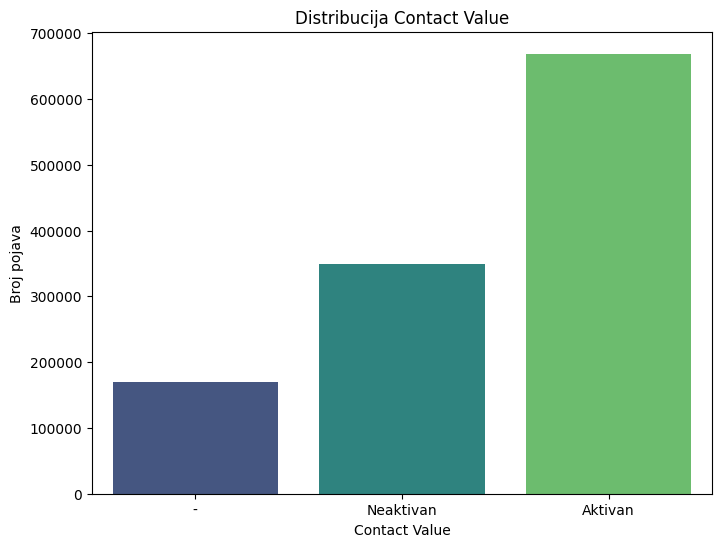

Distribucija 'contact_value' kategorija:
contact_value
Aktivan      56.331312
Neaktivan    29.390195
-            14.278494
Name: proportion, dtype: float64


In [7]:
plt.figure(figsize=(8, 6))
sns.countplot(x='contact_value', data=df, palette='viridis', hue='contact_value', legend=False)
plt.title('Distribucija Contact Value')
plt.xlabel('Contact Value')
plt.ylabel('Broj pojava')
plt.show()

print("Distribucija 'contact_value' kategorija:")
print(df['contact_value'].value_counts(normalize=True) * 100)

### Distribucija ciljne varijable (`withdrawl_flag`)

Vizualizirajmo distribuciju `withdrawl_flag` kako bismo stekli uvid u brojnost svake klase (krađa, normalna potrošnja, točenje goriva) na početku analize. Ovo će nam pomoći razumjeti neuravnoteženost klasa, što je ključno za naknadnu pripremu podataka i modeliranje.

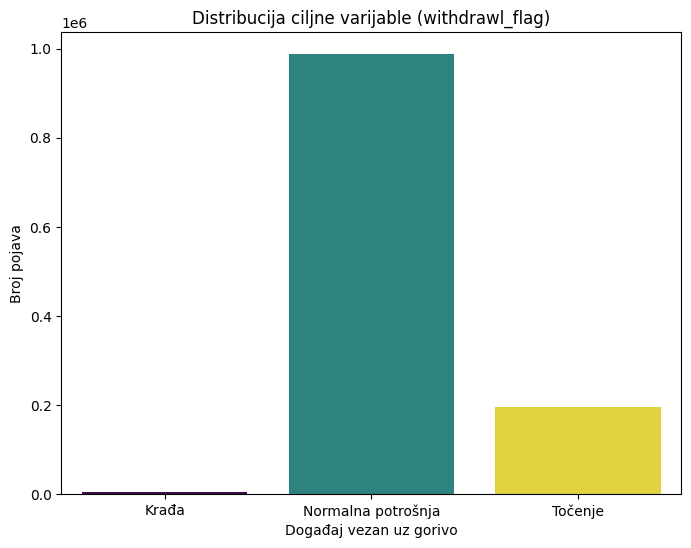

Distribucija 'withdrawl_flag' kategorija:
withdrawl_flag
 0    83.199309
 1    16.423216
-1     0.377475
Name: proportion, dtype: float64


In [8]:
plt.figure(figsize=(8, 6))
sns.countplot(x='withdrawl_flag', data=df, palette='viridis', hue='withdrawl_flag', legend=False)
plt.title('Distribucija ciljne varijable (withdrawl_flag)')
plt.xlabel('Događaj vezan uz gorivo')
plt.ylabel('Broj pojava')
plt.xticks(ticks=[0, 1, 2], labels=['Krađa', 'Normalna potrošnja', 'Točenje'])
plt.show()

print("Distribucija 'withdrawl_flag' kategorija:")
print(df['withdrawl_flag'].value_counts(normalize=True) * 100)

## 2.2. Numeričke varijable (strukturna tablica)
Od numeričkih varijabli u datasetu imamo:
1. fuel_lvl
2. speed
3. gps_latitude
4. gps_longitude
5. time (iako trenutno nije nužno numerička bit će pretvorena u nju funkcijom tkd. je svrstana ovdje)

### Distribucija numeričkih varijabli

Kako bismo bolje razumjeli raspodjelu numeričkih značajki, prikazujemo histogram i procjenu gustoće za ključne varijable. Ova vizualizacija pomaže u uočavanju asimetrije distribucije, koncentracije vrijednosti te mogućih anomalija koje nisu odmah vidljive iz same tablice ili box plota.

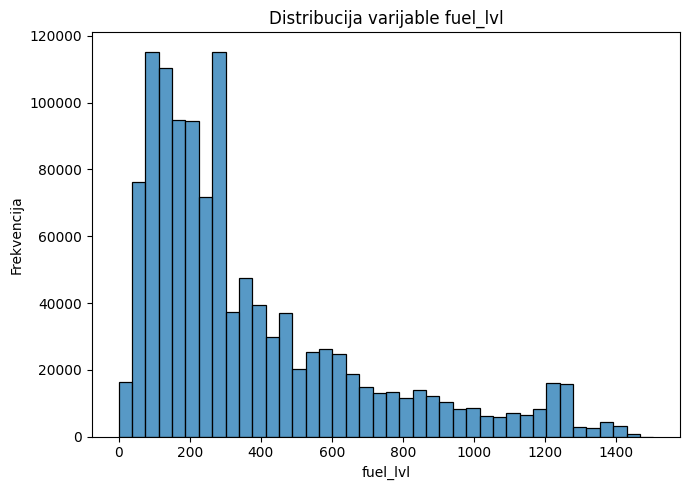

In [9]:
numerical_columns = ['fuel_lvl']

plt.figure(figsize=(7, 5))

for i, col in enumerate(numerical_columns, 1):
    plt.subplot(1, 1, i)
    sns.histplot(df[col], bins=40, kde=False)
    plt.title(f'Distribucija varijable {col}')
    plt.xlabel(col)
    plt.ylabel('Frekvencija')

plt.tight_layout()
plt.show()

Broj zapisa gdje je 'speed' = 0: 658175
Postotak zapisa gdje je 'speed' = 0: 55.44%


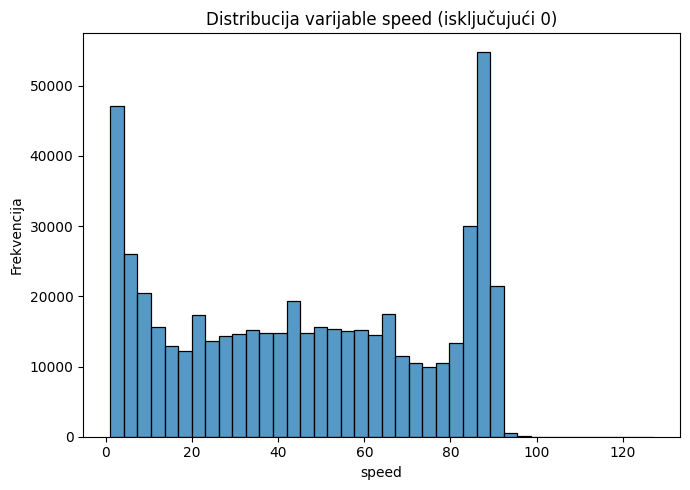

In [10]:
numerical_columns = ['speed']

speed_zero_count = df[df['speed'] == 0].shape[0]
total_records = df.shape[0]
speed_zero_percentage = (speed_zero_count / total_records) * 100

print(f"Broj zapisa gdje je 'speed' = 0: {speed_zero_count}")
print(f"Postotak zapisa gdje je 'speed' = 0: {speed_zero_percentage:.2f}%")

plt.figure(figsize=(7, 5))

for i, col in enumerate(numerical_columns, 1):
    plt.subplot(1, 1, i)
    df_to_plot = df[df[col] > 0]
    sns.histplot(df_to_plot[col], bins=40, kde=False)
    plt.title(f'Distribucija varijable {col} (isključujući 0)')
    plt.xlabel(col)
    plt.ylabel('Frekvencija')

plt.tight_layout()
plt.show()

# 3. Kvaliteta podataka
## 3.1. Nedostajuće vrijednosti


In [11]:
df.isnull().sum()


,0
obj_id,0
time,0
fuel_lvl,0
withdrawl_flag,0
speed,0
contact_value,0
gps_latitude,18
gps_longitude,18


In [12]:
df['gps_latitude'] = df['gps_latitude'].astype(str).str.replace(',', '.', regex=False)
df['gps_longitude'] = df['gps_longitude'].astype(str).str.replace(',', '.', regex=False)

df['gps_latitude'] = pd.to_numeric(df['gps_latitude'], errors='coerce')
df['gps_longitude'] = pd.to_numeric(df['gps_longitude'], errors='coerce')

print("Provjera broja NaN vrijednosti nakon pretvorbe:")
print(df[['gps_latitude', 'gps_longitude']].isnull().sum())

Provjera broja NaN vrijednosti nakon pretvorbe:
gps_latitude     18
gps_longitude    18
dtype: int64


### Vizualizacija nedostajućih vrijednosti

Kako bismo jasnije prikazali kvalitetu podataka prije imputacije, prikazujemo broj nedostajućih vrijednosti po stupcu. Ova vizualizacija omogućuje brzu identifikaciju stupaca koji zahtijevaju dodatnu obradu i olakšava obrazloženje postupka imputacije.

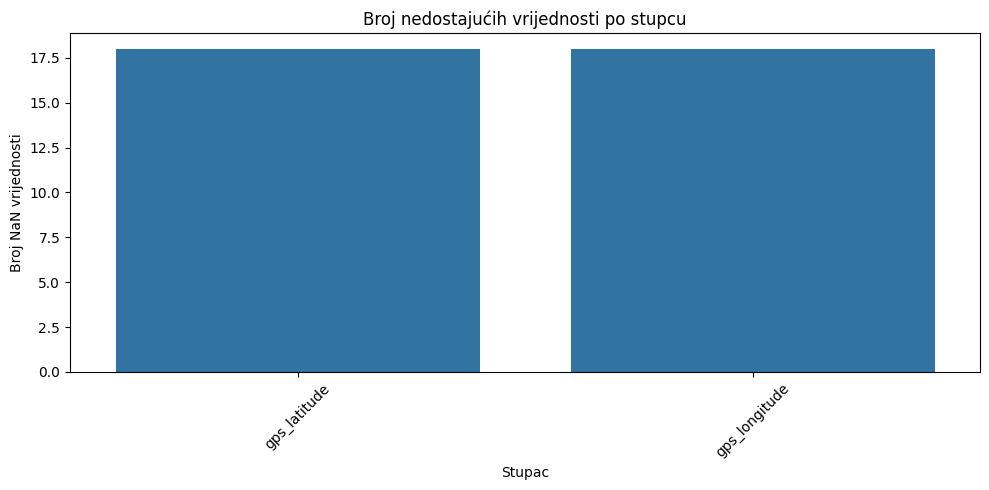

In [13]:
missing_counts = df.isnull().sum().sort_values(ascending=False)
missing_counts = missing_counts[missing_counts > 0]

plt.figure(figsize=(10, 5))
sns.barplot(x=missing_counts.index, y=missing_counts.values)
plt.title('Broj nedostajućih vrijednosti po stupcu')
plt.xlabel('Stupac')
plt.ylabel('Broj NaN vrijednosti')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
median_latitude = df['gps_latitude'].median()
median_longitude = df['gps_longitude'].median()

df['gps_latitude'] = df['gps_latitude'].fillna(median_latitude)
df['gps_longitude'] = df['gps_longitude'].fillna(median_longitude)

print("\nProvjera broja NaN vrijednosti nakon imputacije medijanom:")
print(df[['gps_latitude', 'gps_longitude']].isnull().sum())


Provjera broja NaN vrijednosti nakon imputacije medijanom:
gps_latitude     0
gps_longitude    0
dtype: int64


In [15]:
print("\nNovi tipovi podataka za gps_latitude i gps_longitude:")
print(df[['gps_latitude', 'gps_longitude']].dtypes)


Novi tipovi podataka za gps_latitude i gps_longitude:
gps_latitude     float64
gps_longitude    float64
dtype: object


### Prostorna raspodjela zabilježenih događaja

Budući da skup podataka sadrži geografske koordinate, korisno je prikazati prostorni raspored zabilježenih događaja. Ova vizualizacija može pomoći u uočavanju prostornih obrazaca, grupiranja vozila ili mogućih lokacija na kojima su određeni tipovi događaja češći.

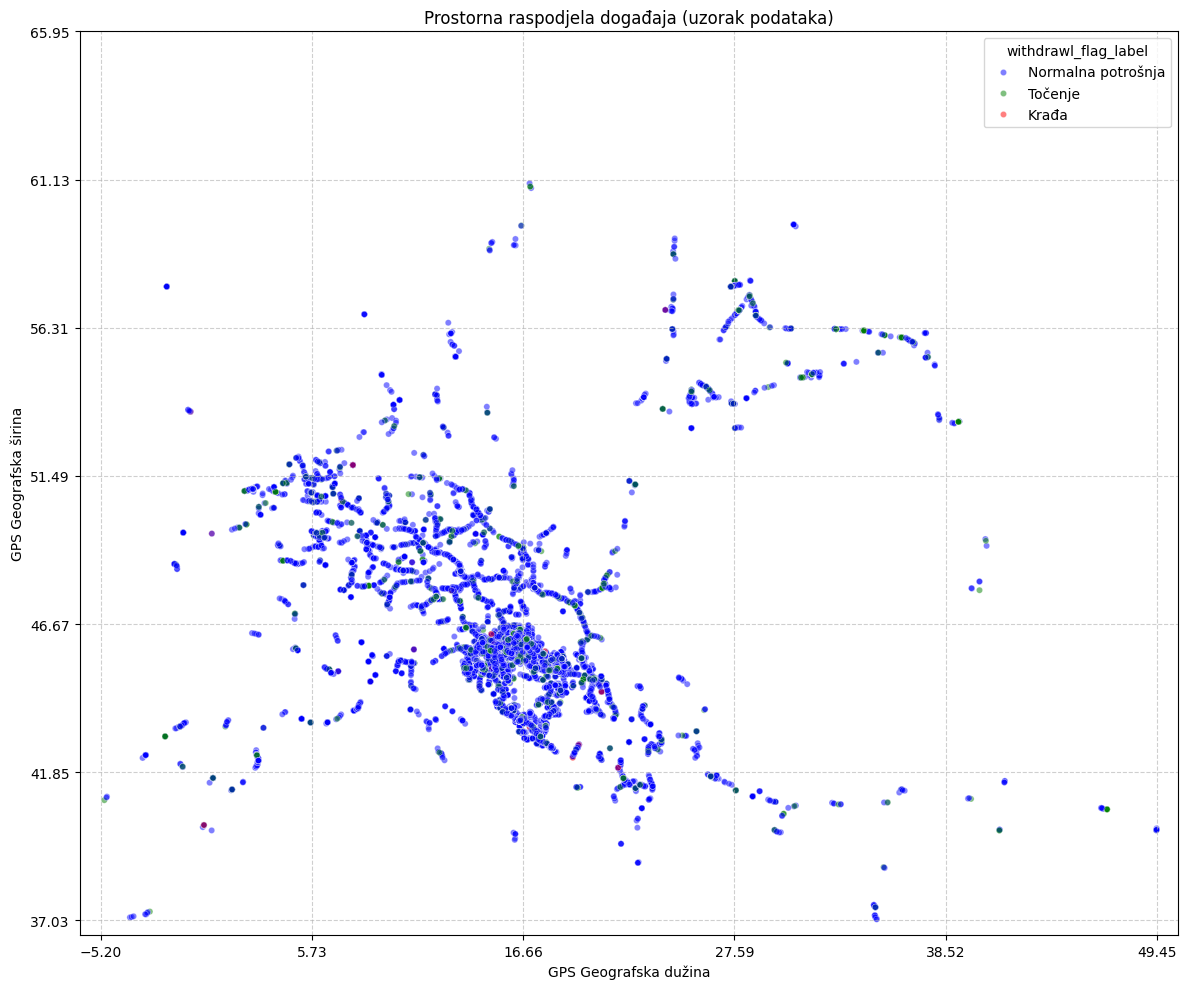

In [16]:
sample_df = df.sample(min(100000, len(df)), random_state=42).copy()
sample_df['withdrawl_flag_label'] = sample_df['withdrawl_flag'].map({-1: 'Krađa', 0: 'Normalna potrošnja', 1: 'Točenje'})

min_lat = df['gps_latitude'].min()
max_lat = df['gps_latitude'].max()
min_lon = df['gps_longitude'].min()
max_lon = df['gps_longitude'].max()

plt.figure(figsize=(12, 10))
sns.scatterplot(
    data=sample_df,
    x='gps_longitude',
    y='gps_latitude',
    hue='withdrawl_flag_label',
    alpha=0.5,
    s=20,
    palette={'Krađa': 'red', 'Normalna potrošnja': 'blue', 'Točenje': 'green'}
)

plt.title('Prostorna raspodjela događaja (uzorak podataka)')
plt.xlabel('GPS Geografska dužina')
plt.ylabel('GPS Geografska širina')

margin_lat = (max_lat - min_lat) * 0.02
margin_lon = (max_lon - min_lon) * 0.02
plt.xlim(min_lon - margin_lon, max_lon + margin_lon)
plt.ylim(min_lat - margin_lat, max_lat + margin_lat)

lat_interval = round((max_lat - min_lat) / 5, 2)
lon_interval = round((max_lon - min_lon) / 5, 2)

if lat_interval == 0: lat_interval = 0.1
if lon_interval == 0: lon_interval = 0.1

plt.xticks(np.arange(min_lon, max_lon + lon_interval, lon_interval))
plt.yticks(np.arange(min_lat, max_lat + lat_interval, lat_interval))

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

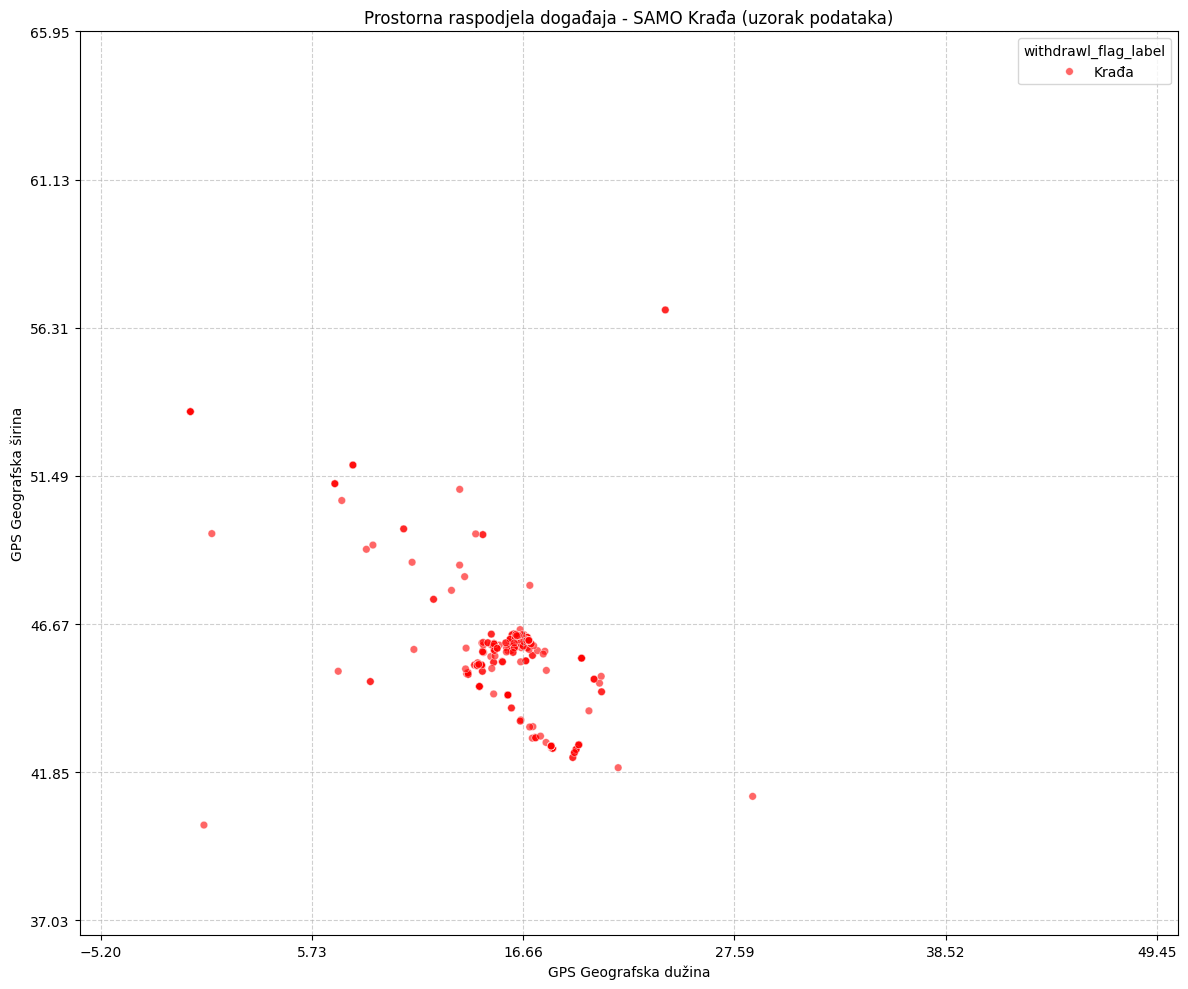

In [17]:
sample_df_theft = df.sample(min(100000, len(df)), random_state=42).copy()
sample_df_theft = sample_df_theft[sample_df_theft['withdrawl_flag'] == -1]
sample_df_theft['withdrawl_flag_label'] = sample_df_theft['withdrawl_flag'].map({-1: 'Krađa', 0: 'Normalna potrošnja', 1: 'Točenje'})

# Calculate global min/max for GPS coordinates from the full DataFrame
min_lat = df['gps_latitude'].min()
max_lat = df['gps_latitude'].max()
min_lon = df['gps_longitude'].min()
max_lon = df['gps_longitude'].max()

plt.figure(figsize=(12, 10))
sns.scatterplot(
    data=sample_df_theft,
    x='gps_longitude',
    y='gps_latitude',
    hue='withdrawl_flag_label',
    alpha=0.6,
    s=30,
    palette={'Krađa': 'red'}
)

plt.title('Prostorna raspodjela događaja - SAMO Krađa (uzorak podataka)')
plt.xlabel('GPS Geografska dužina')
plt.ylabel('GPS Geografska širina')

# Set xlim and ylim to global min/max with a small margin
margin_lat = (max_lat - min_lat) * 0.02
margin_lon = (max_lon - min_lon) * 0.02
plt.xlim(min_lon - margin_lon, max_lon + margin_lon)
plt.ylim(min_lat - margin_lat, max_lat + margin_lat)

# Generate periodic ticks for latitude and longitude
lat_interval = round((max_lat - min_lat) / 5, 2)
lon_interval = round((max_lon - min_lon) / 5, 2)

if lat_interval == 0: lat_interval = 0.1
if lon_interval == 0: lon_interval = 0.1

plt.xticks(np.arange(min_lon, max_lon + lon_interval, lon_interval))
plt.yticks(np.arange(min_lat, max_lat + lat_interval, lat_interval))

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 3.2. Duplikati

In [18]:
print(f"Broj dupliciranih redaka: {df.duplicated().sum()}")

Broj dupliciranih redaka: 8681


In [19]:
display(df[df.duplicated(keep=False)].head())

,obj_id,time,fuel_lvl,withdrawl_flag,speed,contact_value,gps_latitude,gps_longitude
3992,13886,2025-12-19 11:27:00.000,123,-1,0,Neaktivan,45.897849,16.201202
3993,13886,2025-12-19 11:27:00.000,123,-1,0,Neaktivan,45.897849,16.201202
3994,13886,2025-12-19 11:28:00.000,123,0,0,Neaktivan,45.897847,16.201200
3995,13886,2025-12-19 11:28:00.000,123,0,0,Neaktivan,45.897847,16.201200
3996,13886,2025-12-19 11:29:00.000,123,0,0,Neaktivan,45.897854,16.201197


In [20]:
initial_rows = df.shape[0]
df.drop_duplicates(inplace=True)
final_rows = df.shape[0]

print(f"Broj redaka prije uklanjanja duplikata: {initial_rows}")
print(f"Broj redaka nakon uklanjanja duplikata: {final_rows}")
print(f"Uklonjeno je {initial_rows - final_rows} dupliciranih redaka.")

Broj redaka prije uklanjanja duplikata: 1187100
Broj redaka nakon uklanjanja duplikata: 1178419
Uklonjeno je 8681 dupliciranih redaka.


## 3.3. Stršila


### 3.3.1. Identifikacija stršila pomoću IQR metode

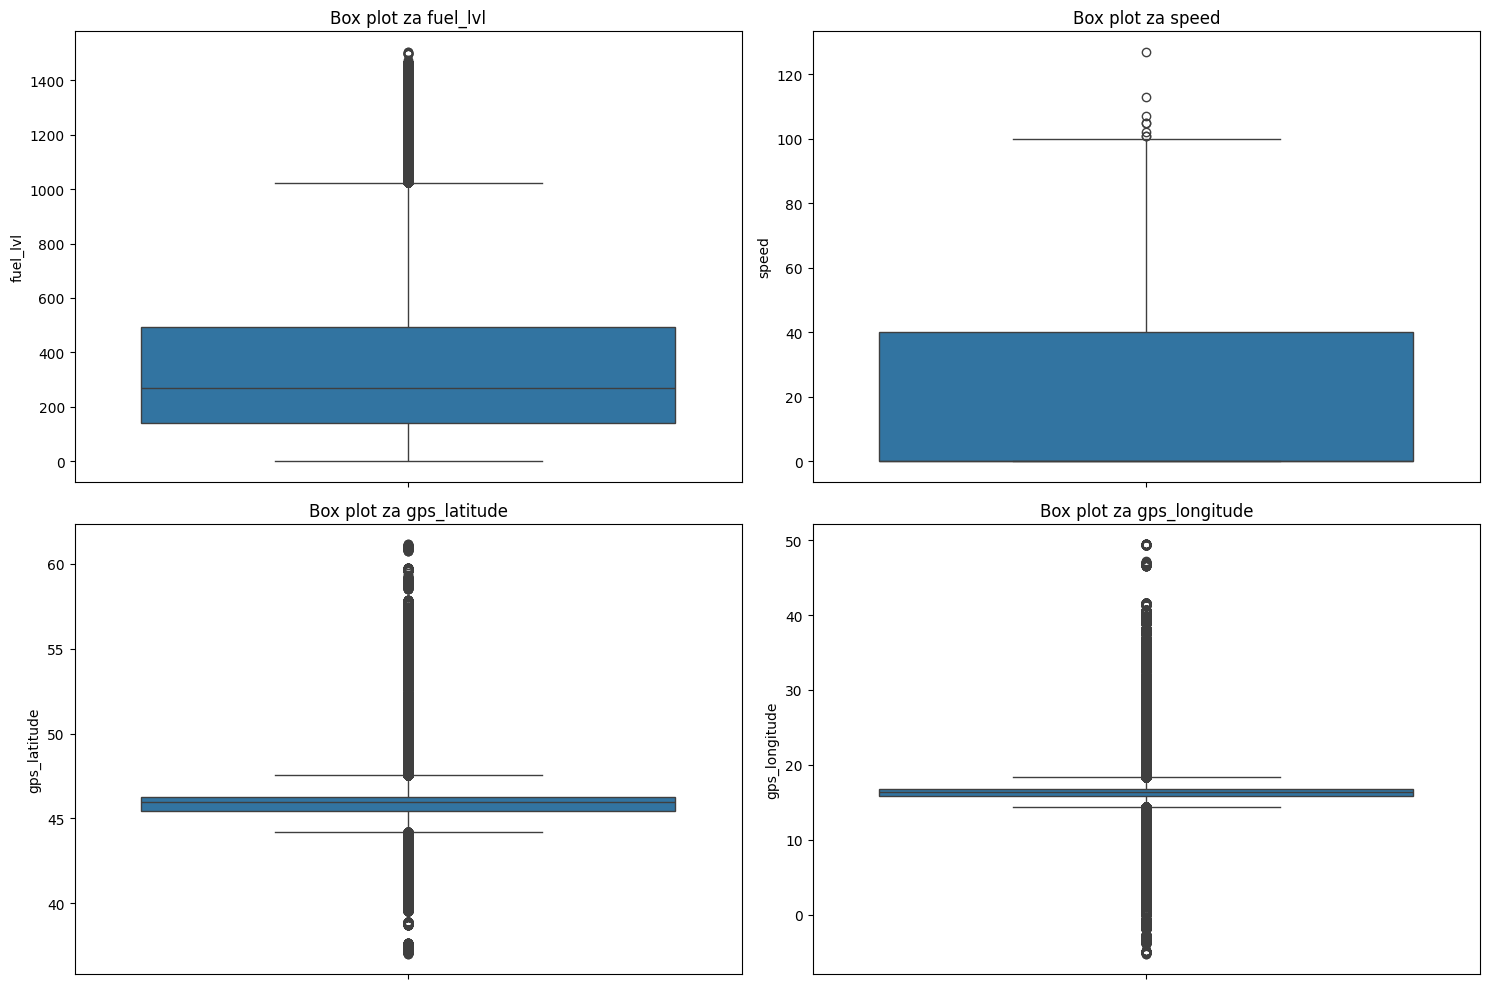

In [21]:
numeric_cols = ['fuel_lvl', 'speed', 'gps_latitude', 'gps_longitude']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box plot za {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

### 3.3.2. Obrazloženje odabira značajki za analizu stršila

In [22]:
def find_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

for col in numeric_cols:
    outliers, lower_bound, upper_bound = find_outliers_iqr(df, col)
    print(f"\n--- Analiza stršila za stupac: {col} ---")
    print(f"Broj stršila: {len(outliers)}")
    print(f"Donja granica (Lower Bound): {lower_bound:.2f}")
    print(f"Gornja granica (Upper Bound): {upper_bound:.2f}")


--- Analiza stršila za stupac: fuel_lvl ---
Broj stršila: 77233
Donja granica (Lower Bound): -387.50
Gornja granica (Upper Bound): 1024.50

--- Analiza stršila za stupac: speed ---
Broj stršila: 8
Donja granica (Lower Bound): -60.00
Gornja granica (Upper Bound): 100.00

--- Analiza stršila za stupac: gps_latitude ---
Broj stršila: 231744
Donja granica (Lower Bound): 44.17
Gornja granica (Upper Bound): 47.55

--- Analiza stršila za stupac: gps_longitude ---
Broj stršila: 200318
Donja granica (Lower Bound): 14.32
Gornja granica (Upper Bound): 18.36


1. Za razinu goriva (fuel_lvl) pronađeno je 77,233 stršila. Donja granica je -387.5 (iako razina goriva nikada ne ide ispod 0), a gornja 1024.5. Veliki broj stršila (oko 6.5% od ukupnog broja redaka) ukazuje na to da su mnoge vrijednosti razine goriva izvan uobičajenog raspona.

2. Za brzinu je pronađeno samo 8 stršila. Donja je granica -60 (iako ponovno ne može ići ispod 0), a gornja 100. Vrlo mali broj stršila prikazuje da su podaci o brzini relativno čisti i da ekstremne brzine nisu česte. Ovaj feature ne zahtjeva dodatno ispitivanje.

3. Za geografsku širinu (gps_latitude) pronađeno je čak 231,744 stršila. Donja je granica 44.17, a gornja 47.55. Ovo je značajan broj stršila (oko 19.5% od ukupnog broja redaka), to mogu uzrokovati greške senzora, ali i putovanja vozila na vrlo različite lokacije.

4. Za geografsku dužinu (gps_longitude) pronađeno je 200,318 stršila. Donja je granica 14.32, a gornja 18.36. Ovo je također značajan broj stršila i opet upućuje na različitosti lokacija vozila ili potencijalne greške u senzorima.


#### Ispitivanje stršila za 'fuel_lvl'

In [23]:
outliers_fuel_lvl, _, _ = find_outliers_iqr(df, 'fuel_lvl')
print(f"Broj stršila u 'fuel_lvl': {len(outliers_fuel_lvl)}")
display(outliers_fuel_lvl[['obj_id', 'time', 'fuel_lvl', 'speed', 'gps_latitude', 'gps_longitude', 'withdrawl_flag']].head(50))

Broj stršila u 'fuel_lvl': 77233


,obj_id,time,fuel_lvl,speed,gps_latitude,gps_longitude,withdrawl_flag
6637,27739,2025-12-02 16:24:00.000,1104,0,45.875920,16.370675,1
6638,27739,2025-12-02 16:25:00.000,1182,0,45.875920,16.370675,1
6639,27739,2025-12-02 16:26:00.000,1185,0,45.875920,16.370675,1
6640,27739,2025-12-02 16:27:00.000,1185,0,45.875920,16.370675,0
6641,27739,2025-12-02 16:28:00.000,1185,0,45.875920,16.370675,0
6642,27739,2025-12-02 16:29:00.000,1185,0,45.875919,16.370712,0
6643,27739,2025-12-02 16:30:00.000,1188,10,45.876170,16.371822,0
6644,27739,2025-12-02 16:31:00.000,1188,22,45.876540,16.375554,0
6645,27739,2025-12-02 16:32:00.000,1187,18,45.876411,16.379185,0
6646,27739,2025-12-02 16:33:00.000,1187,26,45.877320,16.382935,0


#### Ispitivanje stršila za 'gps_latitude'

In [24]:
outliers_gps_latitude, _, _ = find_outliers_iqr(df, 'gps_latitude')
print(f"Broj stršila u 'gps_latitude': {len(outliers_gps_latitude)}")
display(outliers_gps_latitude[['obj_id', 'time', 'fuel_lvl', 'speed', 'gps_latitude', 'gps_longitude']].head(50))

Broj stršila u 'gps_latitude': 231744


,obj_id,time,fuel_lvl,speed,gps_latitude,gps_longitude
6660,27739,2025-12-05 11:56:00.000,389,70,49.157929,17.179062
6661,27739,2025-12-05 11:57:00.000,388,63,49.157325,17.191365
6662,27739,2025-12-05 11:58:00.000,388,72,49.156058,17.208117
6663,27739,2025-12-05 11:59:00.000,385,68,49.151438,17.219420
6664,27739,2025-12-05 12:00:00.000,383,70,49.142394,17.229677
6665,27739,2025-12-05 12:01:00.000,383,57,49.141569,17.240838
6666,27739,2025-12-05 12:02:00.000,383,70,49.135343,17.248516
6667,27739,2025-12-05 12:03:00.000,383,72,49.127185,17.257828
6668,27739,2025-12-05 12:04:00.000,382,51,49.124215,17.271094
6669,27739,2025-12-05 12:05:00.000,382,36,49.124628,17.278470


#### Ispitivanje stršila za 'gps_longitude'

In [25]:
outliers_gps_longitude, _, _ = find_outliers_iqr(df, 'gps_longitude')
print(f"Broj stršila u 'gps_longitude': {len(outliers_gps_longitude)}")
display(outliers_gps_longitude[['obj_id', 'time', 'fuel_lvl', 'speed', 'gps_latitude', 'gps_longitude']].head(50))

Broj stršila u 'gps_longitude': 200318


,obj_id,time,fuel_lvl,speed,gps_latitude,gps_longitude
6780,27739,2025-12-16 11:19:00.000,265,63,50.696014,13.111706
6781,27739,2025-12-16 11:20:00.000,265,69,50.686745,13.116250
6782,27739,2025-12-16 11:21:00.000,265,29,50.680860,13.119214
6783,27739,2025-12-16 11:22:00.000,267,32,50.679129,13.120488
6784,27739,2025-12-16 11:23:00.000,267,68,50.671651,13.128528
6785,27739,2025-12-16 11:24:00.000,266,69,50.669078,13.141647
6786,27739,2025-12-16 11:25:00.000,266,73,50.670369,13.157401
6787,27739,2025-12-16 11:26:00.000,263,70,50.660881,13.166549
6788,27739,2025-12-16 11:27:00.000,262,71,50.655457,13.175931
6789,27739,2025-12-16 11:28:00.000,262,66,50.646674,13.187472


### 3.3.3. Obrazloženje za netretiranje stršila

Nakon detaljne analize stršila u podacima, donesena je odluka o netretiranju stršila za pojedine značajke, uzimajući u obzir kontekst projekta i potencijalni gubitak relevantnih informacija:

1.  **`fuel_lvl` (Razina goriva):**
    *   **Visoke vrijednosti:** Značajan broj stršila identificiran je kao visoke vrijednosti `fuel_lvl`. Daljnjim ispitivanjem utvrđeno je da se ove visoke vrijednosti često podudaraju s trenucima kada je vozilo stacionarno (`speed=0`) i potencijalno s oznakom `withdrawl_flag=1` (točenje goriva). S obzirom na cilj klasifikacije događaja vezanih uz gorivo (normalna potrošnja, točenje, krađa), ekstremno visoke razine goriva (koje prelaze prosječni nivo) mogu biti ključni indikatori događaja točenja goriva. Tretiranjem (npr. ograničavanjem) ovih vrijednosti mogli bismo ukloniti ili oslabiti signal koji je važan za predikciju 'točenja goriva'.

2.  **`gps_latitude` i `gps_longitude` (Geografska širina i dužina):**
    *   **Geografski raspon:** Velik broj stršila u ovim varijablama sugerira da se vozila kreću po širokom geografskom području. Umjesto da su greške senzora, ovi podaci vjerojatno odražavaju stvarna putovanja vozila na udaljenije lokacije, što je legitimni dio njihovog operativnog profila. Na primjer, **vozilo s `obj_id=27739` je konzistentno bilježilo geografske koordinate znatno izvan uobičajenog raspona, što upućuje na to da se kretalo na vrlo udaljene lokacije.** Ograničavanje ili uklanjanje ovih vrijednosti rezultiralo bi gubitkom informacija o punom opsegu kretanja vozila, što bi moglo biti relevantno za neke aspekte modeliranja (npr. otkrivanje krađe vozila ako se kreću izvan uobičajenih ruta). Stoga je odlučeno da se ovi podaci zadrže kako bi se očuvala cjelovitost informacija o lokaciji.

3.  **`speed` (Brzina):**
    *   **Neznatni broj stršila:** Pronađeno je zanemarivo mali broj stršila (samo 8) u varijabli `speed`. S obzirom na veliki obujam skupa podataka, utjecaj ovih rijetkih ekstremnih vrijednosti na ukupnu analizu i modeliranje je minimalan. Uklanjanje ili tretiranje tako malog broja točaka ne bi donijelo značajnu korist, a moglo bi nepotrebno komplicirati proces pripreme podataka.

# 4. Priprema podataka

## 4.1. Odabir podataka
Za sada nema smisla izbacivati nikakve značajke, svaka značajka će ili biti korištena sama po sebi ili će se iz nje konstruirati druge značajke.

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1178419 entries, 0 to 1187099
Data columns (total 8 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   obj_id          1178419 non-null  int64  
 1   time            1178419 non-null  object 
 2   fuel_lvl        1178419 non-null  int64  
 3   withdrawl_flag  1178419 non-null  int64  
 4   speed           1178419 non-null  int64  
 5   contact_value   1178419 non-null  object 
 6   gps_latitude    1178419 non-null  float64
 7   gps_longitude   1178419 non-null  float64
dtypes: float64(2), int64(4), object(2)
memory usage: 80.9+ MB


## 4.2. Čišćenje podataka
S obzirom na već odrađeno popunjavanje nedostajućih numeričkih vrijednosti i već obrađene duplikate. Uz analizirana stršila prije konstrukcije novih podataka odn. značajki ostalo nam je pretvoriti **`time`** u datetime tip podatka. Ovakva lagana konverzija bez enkodiranja za contact value koji je trenutno object i sadrži vrijednosti tipa "Aktivan", "Neaktivan" i "-" nije moguća.

In [27]:
df['time'] = pd.to_datetime(df['time'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1178419 entries, 0 to 1187099
Data columns (total 8 columns):
 #   Column          Non-Null Count    Dtype         
---  ------          --------------    -----         
 0   obj_id          1178419 non-null  int64         
 1   time            1178419 non-null  datetime64[ns]
 2   fuel_lvl        1178419 non-null  int64         
 3   withdrawl_flag  1178419 non-null  int64         
 4   speed           1178419 non-null  int64         
 5   contact_value   1178419 non-null  object        
 6   gps_latitude    1178419 non-null  float64       
 7   gps_longitude   1178419 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(4), object(1)
memory usage: 80.9+ MB


### 4.2.1. Imputacija 'contact_value' pomoću XGBoost modela

Prije nego što nastavimo s daljnjim inženjeringom značajki, imputirat ćemo nedostajuće vrijednosti za `contact_value` (označene s '-') koristeći XGBoost klasifikator. Ovaj model će se trenirati na ostalim dostupnim značajkama (`fuel_lvl`, `speed`, `gps_latitude`, `gps_longitude`) iz redova gdje je `contact_value` poznat ('Aktivan' ili 'Neaktivan'), a zatim će predvidjeti nedostajuće vrijednosti. Ovo osigurava da se vrijednosti '- ' popunjavaju na inteligentan način, umjesto jednostavnog uklanjanja ili zamjene.


In [28]:
import xgboost as xgb
import numpy as np # Import numpy for np.nan

# Map 'Aktivan' to 1, 'Neaktivan' to 0, and '-' to NaN for contact_value
# This ensures it's numeric from the start and stays numeric
df['contact_value'] = df['contact_value'].map({'Aktivan': 1, 'Neaktivan': 0, '-': np.nan})

# Separate data for imputation: known (non-NaN) and unknown (NaN) contact_value
df_known = df[df['contact_value'].notna()].copy()
df_unknown = df[df['contact_value'].isna()].copy()

if not df_unknown.empty:
    print(f"Pronađeno {len(df_unknown)} redaka s 'contact_value' = NaN. Pokreće se imputacija...")

    # Features for imputation (using features available at this point)
    impute_features = ['fuel_lvl', 'speed', 'gps_latitude', 'gps_longitude']

    # The target variable `contact_value` in `df_known` is already 0 or 1.
    # Convert it to int for XGBoost training.
    df_known['contact_value'] = df_known['contact_value'].astype(int)

    # Initialize and train XGBoost classifier
    xgb_imputer = xgb.XGBClassifier(
        objective='binary:logistic', # Binary classification for 0/1
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    )
    xgb_imputer.fit(df_known[impute_features], df_known['contact_value'])

    # Predict missing values
    df_unknown['contact_value'] = xgb_imputer.predict(df_unknown[impute_features])

    # Combine the dataframes back into the main DataFrame
    # Ensure all contact_value are integers
    df = pd.concat([df_known, df_unknown], ignore_index=True)
    df['contact_value'] = df['contact_value'].astype(int) # Final conversion to int
    print("Imputacija 'contact_value' uspješno završena.")
else:
    print("'contact_value' ne sadrži NaN vrijednosti, imputacija nije potrebna.")
    # Ensure it's int even if no imputation was needed
    df['contact_value'] = df['contact_value'].astype(int)

print("\nProvjera 'contact_value' nakon imputacije:")
print(df['contact_value'].value_counts())
print(df['contact_value'].dtype)

Pronađeno 167898 redaka s 'contact_value' = NaN. Pokreće se imputacija...
Imputacija 'contact_value' uspješno završena.

Provjera 'contact_value' nakon imputacije:
contact_value
1    771272
0    407147
Name: count, dtype: int64
int64


In [29]:
df.sample(5)

,obj_id,time,fuel_lvl,withdrawl_flag,speed,contact_value,gps_latitude,gps_longitude
366003,61266,2026-01-05 21:59:00,161,0,1,1,45.717026,16.050557
864012,56518,2026-03-18 05:19:00,90,0,9,1,42.647692,18.083035
19361,42434,2025-12-05 16:58:00,159,0,37,1,43.558574,16.364398
790366,108923,2026-02-13 08:29:00,116,0,0,1,46.396200,16.450240
527090,33637,2026-02-23 06:42:00,713,0,46,1,45.694442,16.393929


## 4.3. Konstrukcija podataka


### 4.3.1. Konstrukcija značajki temeljenih na vremenu i promjenama goriva

In [30]:
from math import radians, sin, cos, sqrt, atan2

def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371

    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    distance = R * c
    return distance

df = df.sort_values(by=['obj_id', 'time']).reset_index(drop=True)

df['fuel_lvl_change'] = df.groupby('obj_id')['fuel_lvl'].diff()

df['time_diff'] = df.groupby('obj_id')['time'].diff().dt.total_seconds()

df['fuel_lvl_change_rate'] = df['fuel_lvl_change'] / df['time_diff']
df['fuel_lvl_change_rate'] = df['fuel_lvl_change_rate'].replace([np.inf, -np.inf], np.nan)

df['is_stationary'] = (df['speed'] == 0).astype(int)

df['hour'] = df['time'].dt.hour
df['day_of_week'] = df['time'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
df['day_of_month'] = df['time'].dt.day
df['month'] = df['time'].dt.month

df['previous_fuel_lvl'] = df.groupby('obj_id')['fuel_lvl'].shift(1)
df['previous_speed'] = df.groupby('obj_id')['speed'].shift(1)

df['prev_gps_latitude'] = df.groupby('obj_id')['gps_latitude'].shift(1)
df['prev_gps_longitude'] = df.groupby('obj_id')['gps_longitude'].shift(1)

df['distance_traveled'] = df.apply(
    lambda row: haversine_distance(row['gps_latitude'], row['gps_longitude'],
                                   row['prev_gps_latitude'], row['prev_gps_longitude'])
    if pd.notna(row['prev_gps_latitude']) else 0, axis=1
)

df['fuel_lvl_change'] = df['fuel_lvl_change'].fillna(0)
df['time_diff'] = df['time_diff'].fillna(0.0)
df['fuel_lvl_change_rate'] = df['fuel_lvl_change_rate'].fillna(0)

df['previous_fuel_lvl'] = df['previous_fuel_lvl'].fillna(0)
df['previous_speed'] = df['previous_speed'].fillna(0)

df.drop(columns=['prev_gps_latitude', 'prev_gps_longitude'], inplace=True)

print("Prvih nekoliko redaka s novim konstruiranim značajkama:")
display(df[['obj_id', 'time', 'fuel_lvl', 'fuel_lvl_change', 'time_diff', 'fuel_lvl_change_rate', 'speed', 'is_stationary', 'hour', 'day_of_week', 'is_weekend', 'day_of_month', 'month', 'previous_fuel_lvl', 'previous_speed', 'distance_traveled']].sample(10))

Prvih nekoliko redaka s novim konstruiranim značajkama:


,obj_id,time,fuel_lvl,fuel_lvl_change,time_diff,fuel_lvl_change_rate,speed,is_stationary,hour,day_of_week,is_weekend,day_of_month,month,previous_fuel_lvl,previous_speed,distance_traveled
711684,78902,2026-01-29 07:24:00,79,0.0,60.0,0.000000,0,1,7,3,0,29,1,79.0,0.0,0.000154
1052545,103637,2026-03-22 22:05:00,1152,0.0,60.0,0.000000,0,1,22,6,1,22,3,1152.0,1.0,0.001786
639347,74502,2025-12-04 10:59:00,182,0.0,60.0,0.000000,18,0,10,3,0,4,12,182.0,18.0,0.281113
792308,81528,2026-01-02 11:30:00,136,0.0,60.0,0.000000,0,1,11,4,0,2,1,136.0,0.0,0.000000
164113,46082,2026-01-16 01:33:00,163,0.0,60.0,0.000000,0,1,1,4,0,16,1,163.0,0.0,0.000000
514850,69207,2026-01-23 14:16:00,216,49.0,60.0,0.816667,0,1,14,4,0,23,1,167.0,0.0,0.000000
8714,7936,2026-02-10 09:23:00,201,0.0,60.0,0.000000,0,1,9,1,0,10,2,201.0,0.0,0.000000
754111,81141,2025-12-22 11:38:00,112,0.0,60.0,0.000000,22,0,11,0,0,22,12,112.0,19.0,0.412293
144459,44139,2026-02-17 11:01:00,684,0.0,60.0,0.000000,0,1,11,1,0,17,2,684.0,2.0,0.005495
983620,89684,2025-12-13 08:50:00,171,0.0,60.0,0.000000,6,0,8,5,1,13,12,171.0,0.0,0.011184


### Vremenska raspodjela događaja

Budući da su iz varijable `time` konstruirane vremenske značajke, korisno je analizirati kako se događaji raspoređuju kroz sate u danu i dane u tjednu. Ova vizualizacija može otkriti pojavljuju li se određeni tipovi događaja češće u specifičnim vremenskim intervalima, što može biti važno za detekciju sumnjivih obrazaca.


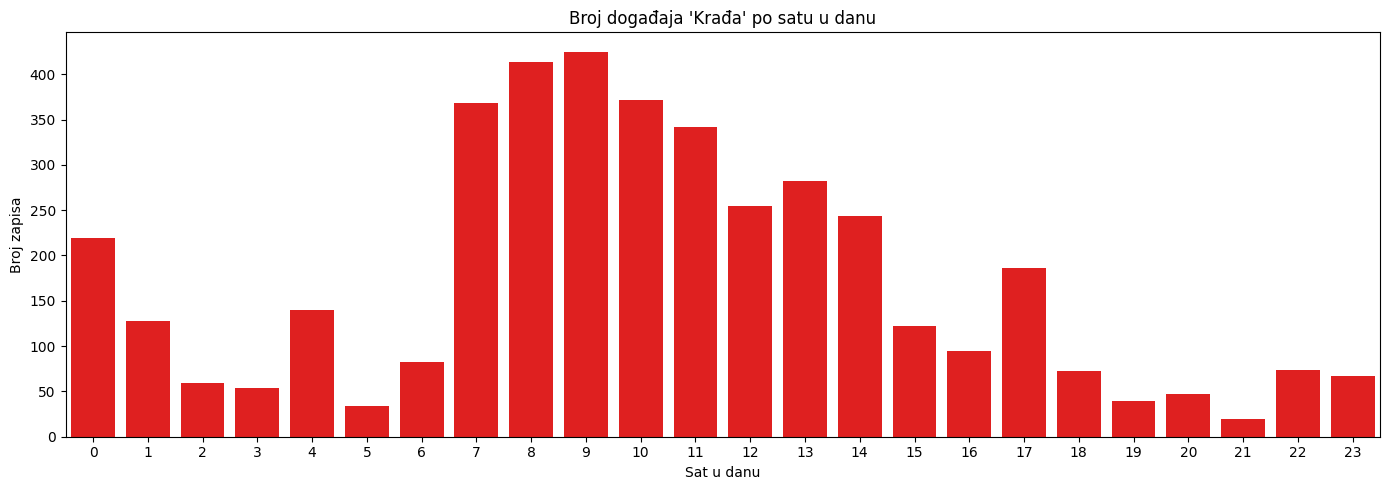

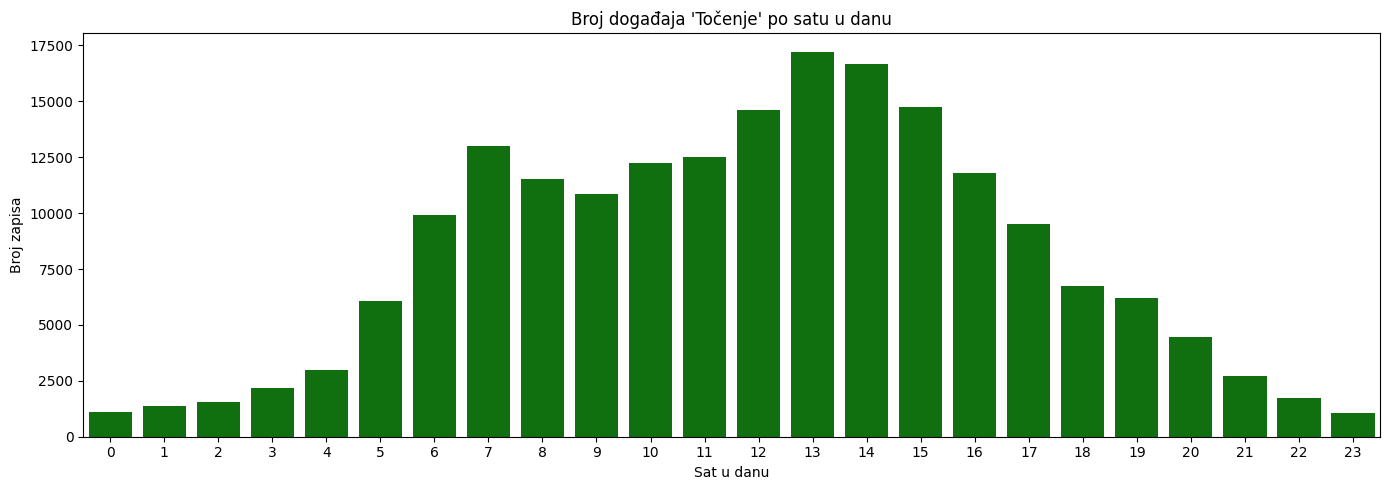

In [31]:
flag_labels = {-1: 'Krađa', 0: 'Normalna potrošnja', 1: 'Točenje'}
df_time_plot = df.copy()
df_time_plot['withdrawl_flag_label'] = df_time_plot['withdrawl_flag'].map(flag_labels)

df_theft = df_time_plot[df_time_plot['withdrawl_flag_label'] == 'Krađa'].copy()
plt.figure(figsize=(14, 5))
sns.countplot(data=df_theft, x='hour', hue='withdrawl_flag_label', palette={'Krađa': 'red'}, legend=False)
plt.title('Broj događaja \'Krađa\' po satu u danu')
plt.xlabel('Sat u danu')
plt.ylabel('Broj zapisa')
plt.tight_layout()
plt.show()

df_fueling = df_time_plot[df_time_plot['withdrawl_flag_label'] == 'Točenje'].copy()
plt.figure(figsize=(14, 5))
sns.countplot(data=df_fueling, x='hour', hue='withdrawl_flag_label', palette={'Točenje': 'green'}, legend=False)
plt.title('Broj događaja \'Točenje\' po satu u danu')
plt.xlabel('Sat u danu')
plt.ylabel('Broj zapisa')
plt.tight_layout()
plt.show()

### Trend događaja kroz vrijeme

Kako bismo analizirali kako se događaji mijenjaju kroz promatrano razdoblje, agregiramo broj zapisa po danima. Ova vizualizacija omogućuje uočavanje vršnih razdoblja, mogućih sezonskih obrazaca i promjena u učestalosti događaja tijekom vremena.


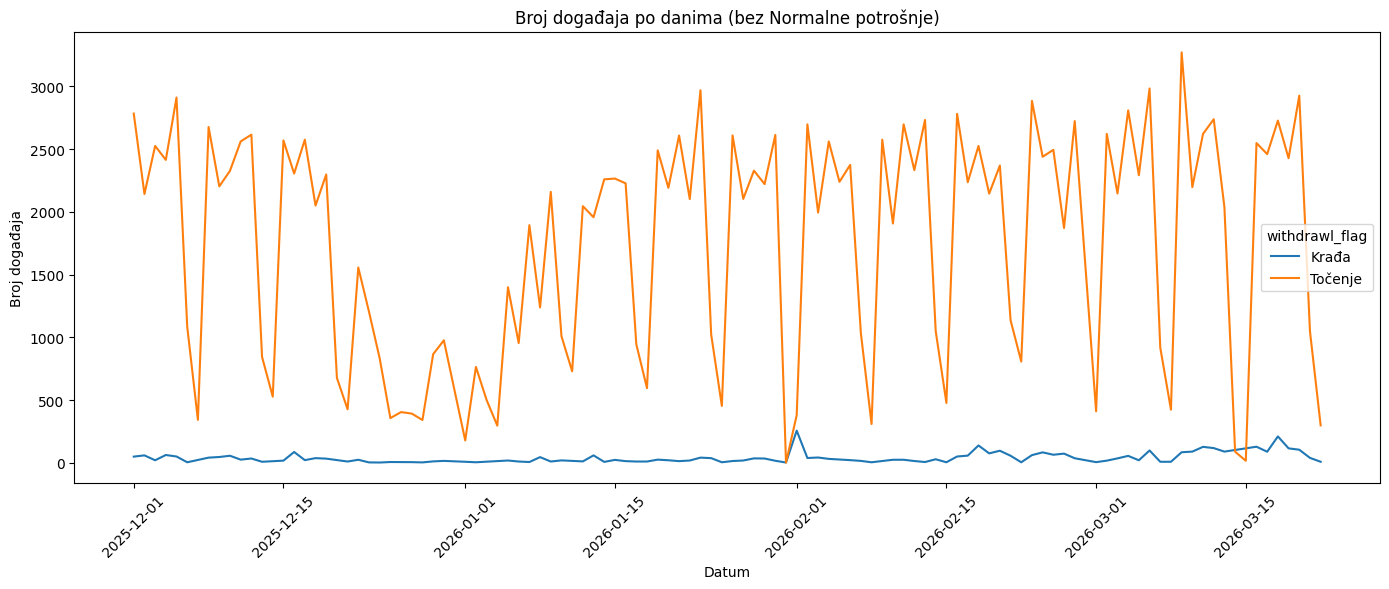

In [32]:
df_trend = df.copy()
df_trend['date'] = df_trend['time'].dt.date

df_filtered_for_plot = df_trend[df_trend['withdrawl_flag'] != 0].copy()

daily_events = df_filtered_for_plot.groupby(['date', 'withdrawl_flag']).size().reset_index(name='count')
daily_events['withdrawl_flag'] = daily_events['withdrawl_flag'].map({-1: 'Krađa', 0: 'Normalna potrošnja', 1: 'Točenje'})

plt.figure(figsize=(14, 6))
sns.lineplot(data=daily_events, x='date', y='count', hue='withdrawl_flag')
plt.title('Broj događaja po danima (bez Normalne potrošnje)')
plt.xlabel('Datum')
plt.ylabel('Broj događaja')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Vizualizacija konstruiranih značajki: `fuel_lvl_change` i `fuel_lvl_change_rate`

Nakon što smo konstruirali značajke koje opisuju promjenu razine goriva i stopu te promjene, korisno je vizualizirati njihovu distribuciju u odnosu na ciljnu varijablu (`withdrawl_flag`). Ovo nam može pomoći razumjeti kako se ove značajke ponašaju tijekom različitih događaja (krađa, normalna potrošnja, točenje goriva) i potvrditi njihovu važnost za modeliranje.

### Raspodjela promjene razine goriva po klasama

Kako bismo detaljnije prikazali način na koji se promjena razine goriva razlikuje među klasama, koristimo violin plot. Za razliku od box plota, ova vizualizacija prikazuje i oblik distribucije, što omogućuje dublje razumijevanje ponašanja pojedinih događaja.


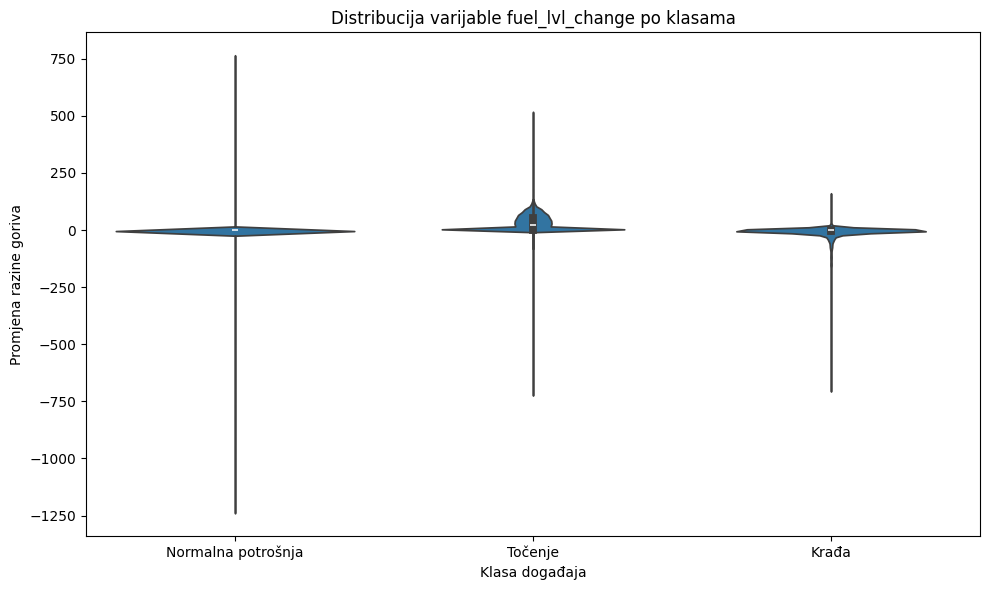

In [33]:
df_violin = df.copy()
df_violin['withdrawl_flag_label'] = df_violin['withdrawl_flag'].map({-1: 'Krađa', 0: 'Normalna potrošnja', 1: 'Točenje'})

plt.figure(figsize=(10, 6))
sns.violinplot(data=df_violin, x='withdrawl_flag_label', y='fuel_lvl_change')
plt.title('Distribucija varijable fuel_lvl_change po klasama')
plt.xlabel('Klasa događaja')
plt.ylabel('Promjena razine goriva')
plt.tight_layout()
plt.show()

### 4.3.2. Konstrukcija značajki pomoću kliznih prozora (Rolling Features)

In [34]:

window_size = '5min'

rolling_fuel_change_series = df.groupby('obj_id').apply(lambda x: x.set_index('time')['fuel_lvl_change'].rolling(window=window_size, min_periods=1).mean()).reset_index()

rolling_speed_series = df.groupby('obj_id').apply(lambda x: x.set_index('time')['speed'].rolling(window=window_size, min_periods=1).mean()).reset_index()

rolling_fuel_change_series = rolling_fuel_change_series.rename(columns={'fuel_lvl_change': f'rolling_mean_fuel_change_{window_size}'})
rolling_speed_series = rolling_speed_series.rename(columns={'speed': f'rolling_mean_speed_{window_size}'})

df = pd.merge(df, rolling_fuel_change_series, on=['obj_id', 'time'], how='left')
df = pd.merge(df, rolling_speed_series, on=['obj_id', 'time'], how='left')

for col_name in [f'rolling_mean_fuel_change_{window_size}', f'rolling_mean_speed_{window_size}']:
    df[col_name] = df[col_name].fillna(0)

print("Prvih nekoliko redaka s novim kliznim značajkama (vremenski baziran prozor):")
display(df.filter(like='rolling').sample(10))

/tmp/ipykernel_902/851044738.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rolling_fuel_change_series = df.groupby('obj_id').apply(lambda x: x.set_index('time')['fuel_lvl_change'].rolling(window=window_size, min_periods=1).mean()).reset_index()
/tmp/ipykernel_902/851044738.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rolling_speed_series = df.groupby('obj_id').apply(lambda x: x.set_index('time'

Prvih nekoliko redaka s novim kliznim značajkama (vremenski baziran prozor):


,rolling_mean_fuel_change_5min,rolling_mean_speed_5min
293230,0.0,32.8
357292,-0.2,58.8
291011,-0.2,69.4
366348,9.2,0.0
950166,67.8,0.0
964703,0.0,0.0
158579,-0.6,53.4
40516,0.0,0.0
525540,0.0,22.2
950599,-0.8,0.0


In [35]:
df.drop(['obj_id', 'time', 'time_diff'], axis=1, inplace=True)
print(f"Stupci 'obj_id', 'time' i 'time_diff' uspješno izbačeni. Trenutni broj značajki: {df.shape[1]}")
print("Ažurirani popis značajki:")
df.info()

Stupci 'obj_id', 'time' i 'time_diff' uspješno izbačeni. Trenutni broj značajki: 19
Ažurirani popis značajki:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1178419 entries, 0 to 1178418
Data columns (total 19 columns):
 #   Column                         Non-Null Count    Dtype  
---  ------                         --------------    -----  
 0   fuel_lvl                       1178419 non-null  int64  
 1   withdrawl_flag                 1178419 non-null  int64  
 2   speed                          1178419 non-null  int64  
 3   contact_value                  1178419 non-null  int64  
 4   gps_latitude                   1178419 non-null  float64
 5   gps_longitude                  1178419 non-null  float64
 6   fuel_lvl_change                1178419 non-null  float64
 7   fuel_lvl_change_rate           1178419 non-null  float64
 8   is_stationary                  1178419 non-null  int64  
 9   hour                           1178419 non-null  int32  
 10  day_of_week                 

### 4.3.3. Cirkularna transformacija značajki

In [36]:
import numpy as np

cyclical_features = {
    'hour': 24,
    'day_of_week': 7,
    'day_of_month': 31,
    'month': 12
}

for col, period in cyclical_features.items():
    df[col + '_sin'] = np.sin(2 * np.pi * df[col] / period)
    df[col + '_cos'] = np.cos(2 * np.pi * df[col] / period)

df.drop(columns=list(cyclical_features.keys()), inplace=True)

print("Transformirane cikličke značajke:")
display(df[['hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'day_of_month_sin', 'day_of_month_cos', 'month_sin', 'month_cos']].sample(5))

Transformirane cikličke značajke:


,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,day_of_month_sin,day_of_month_cos,month_sin,month_cos
1142612,-0.965926,-0.258819,0.974928,-0.222521,0.790776,-0.612106,1.0,6.123234e-17
651513,-0.500000,-0.866025,0.433884,-0.900969,0.848644,0.528964,1.0,6.123234e-17
438715,-0.258819,-0.965926,0.781831,0.623490,0.571268,0.820763,1.0,6.123234e-17
349675,-0.258819,-0.965926,0.974928,-0.222521,0.299363,-0.954139,0.5,8.660254e-01
1067954,-0.500000,-0.866025,-0.974928,-0.222521,0.571268,0.820763,0.5,8.660254e-01


## 4.4. Integriranje podataka


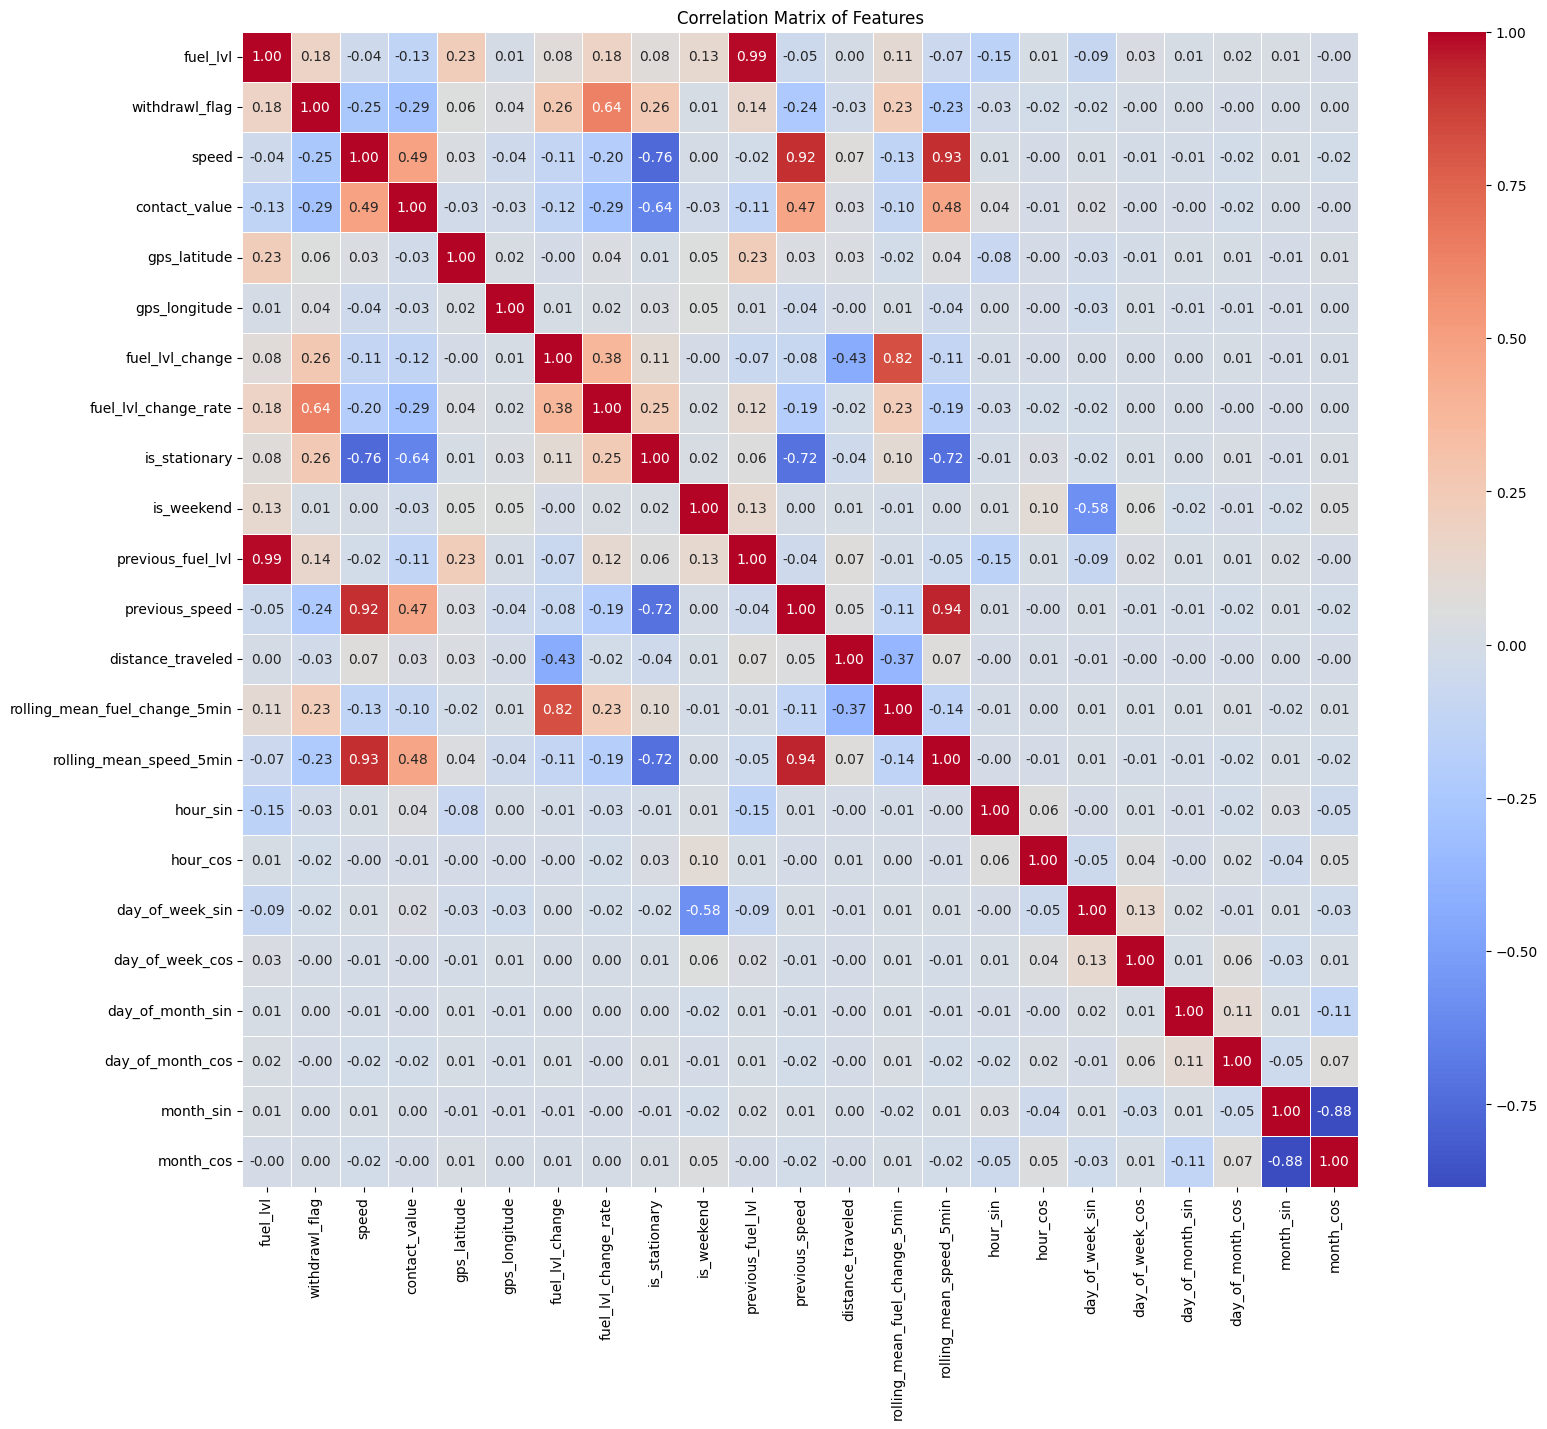

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = df.corr()

plt.figure(figsize=(18, 15))

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Features')
plt.show()

In [38]:
print(f"Prije integracije, DataFrame ima {df.shape[1]} stupaca.")

y = df['withdrawl_flag']
X = df.drop('withdrawl_flag', axis=1)

print(f"Nakon odvajanja, X ima {X.shape[1]} značajki, a y je veličine {y.shape[0]}.\n")
print("Info o značajkama (X) prije podjele:")
X.info()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)

print(f"\nVeličina trening skupa X_train: {X_train.shape}")
print(f"Veličina test skupa X_test: {X_test.shape}")
print(f"Veličina trening skupa y_train: {y_train.shape}")
print(f"Veličina test skupa y_test: {y_test.shape}")

Prije integracije, DataFrame ima 23 stupaca.
Nakon odvajanja, X ima 22 značajki, a y je veličine 1178419.

Info o značajkama (X) prije podjele:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1178419 entries, 0 to 1178418
Data columns (total 22 columns):
 #   Column                         Non-Null Count    Dtype  
---  ------                         --------------    -----  
 0   fuel_lvl                       1178419 non-null  int64  
 1   speed                          1178419 non-null  int64  
 2   contact_value                  1178419 non-null  int64  
 3   gps_latitude                   1178419 non-null  float64
 4   gps_longitude                  1178419 non-null  float64
 5   fuel_lvl_change                1178419 non-null  float64
 6   fuel_lvl_change_rate           1178419 non-null  float64
 7   is_stationary                  1178419 non-null  int64  
 8   is_weekend                     1178419 non-null  int64  
 9   previous_fuel_lvl              1178419 non-null  float64

## 4.5. Oblikovanje podataka
Sada je potrebno ponovno podijeliti podatke na trening i test set, te ažurirati liste numeričkih i kategoričkih značajki za `ColumnTransformer`.

### Provjera distribucije klasa u `y_train`

Distribucija klasa u y_train:
withdrawl_flag
 0    883346
 1    173503
-1      3728
Name: count, dtype: int64

Postotak distribucije klasa u y_train:
withdrawl_flag
 0    83.289191
 1    16.359303
-1     0.351507
Name: proportion, dtype: float64


/tmp/ipykernel_902/2589005802.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_percentage_y_train.index, y=class_percentage_y_train.values, palette='viridis')


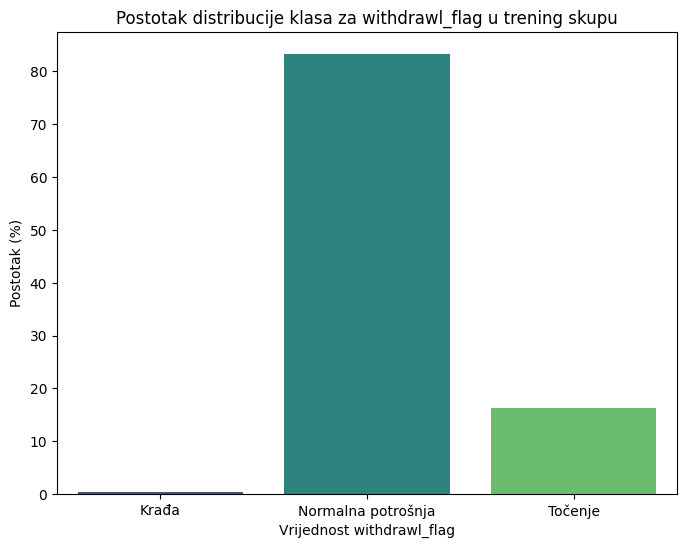


Distribucija klasa u cijelom skupu podataka (df):
withdrawl_flag
 0    981496
 1    192781
-1      4142
Name: count, dtype: int64

Postotak distribucije klasa u cijelom skupu podataka (df):
withdrawl_flag
 0    83.289221
 1    16.359292
-1     0.351488
Name: proportion, dtype: float64


/tmp/ipykernel_902/2589005802.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_percentage_df.index, y=class_percentage_df.values, palette='plasma')


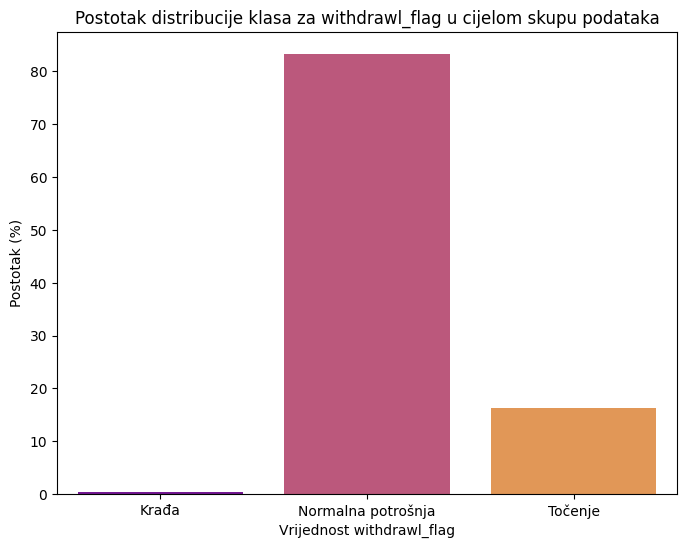

In [39]:
class_distribution_y_train = y_train.value_counts()
print("Distribucija klasa u y_train:")
print(class_distribution_y_train)

print("\nPostotak distribucije klasa u y_train:")
class_percentage_y_train = y_train.value_counts(normalize=True) * 100
print(class_percentage_y_train)

plt.figure(figsize=(8, 6))
sns.barplot(x=class_percentage_y_train.index, y=class_percentage_y_train.values, palette='viridis')
plt.title('Postotak distribucije klasa za withdrawl_flag u trening skupu')
plt.xlabel('Vrijednost withdrawl_flag')
plt.ylabel('Postotak (%)')
plt.xticks(ticks=[0, 1, 2], labels=['Krađa', 'Normalna potrošnja', 'Točenje'], rotation=0)
plt.show()

class_distribution_df = df['withdrawl_flag'].value_counts()
print("\nDistribucija klasa u cijelom skupu podataka (df):")
print(class_distribution_df)

print("\nPostotak distribucije klasa u cijelom skupu podataka (df):")
class_percentage_df = df['withdrawl_flag'].value_counts(normalize=True) * 100
print(class_percentage_df)

plt.figure(figsize=(8, 6))
sns.barplot(x=class_percentage_df.index, y=class_percentage_df.values, palette='plasma')
plt.title('Postotak distribucije klasa za withdrawl_flag u cijelom skupu podataka')
plt.xlabel('Vrijednost withdrawl_flag')
plt.ylabel('Postotak (%)')
plt.xticks(ticks=[0, 1, 2], labels=['Krađa', 'Normalna potrošnja', 'Točenje'], rotation=0)
plt.show()

### Primjena SMOTE-a za rješavanje neuravnoteženosti klasa

S obzirom na značajnu neuravnoteženost klasa, posebno klase `-1` (krađa goriva), primijenit ćemo SMOTE (Synthetic Minority Over-sampling Technique) na trening skup. SMOTE će generirati sintetičke uzorke za manjinske klase, čime će se povećati njihov broj i uravnotežiti distribucija klasa u trening skupu. Važno je napomenuti da se SMOTE primjenjuje samo na trening skup kako bi se izbjeglo curenje podataka (data leakage) u test skup.

In [40]:
from imblearn.over_sampling import SMOTE

print("Distribucija klasa prije SMOTE-a:")
print(y_train.value_counts())

sm = SMOTE(random_state=42, k_neighbors=5)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train, y_train)

print("\nDistribucija klasa nakon SMOTE-a:")
print(y_train_resampled.value_counts())

print(f"Oblik X_train_resampled: {X_train_resampled.shape}")
print(f"Oblik y_train_resampled: {y_train_resampled.shape}")

Distribucija klasa prije SMOTE-a:
withdrawl_flag
 0    883346
 1    173503
-1      3728
Name: count, dtype: int64

Distribucija klasa nakon SMOTE-a:
withdrawl_flag
 0    883346
 1    883346
-1    883346
Name: count, dtype: int64
Oblik X_train_resampled: (2650038, 22)
Oblik y_train_resampled: (2650038,)


### Usporedba distribucije klasa prije i poslije SMOTE-a

S obzirom na izraženu neuravnoteženost ciljne varijable, važno je vizualno prikazati učinak SMOTE metode. Usporedba distribucije klasa prije i nakon balansiranja jasno pokazuje kako je postupak utjecao na strukturu trening skupa.


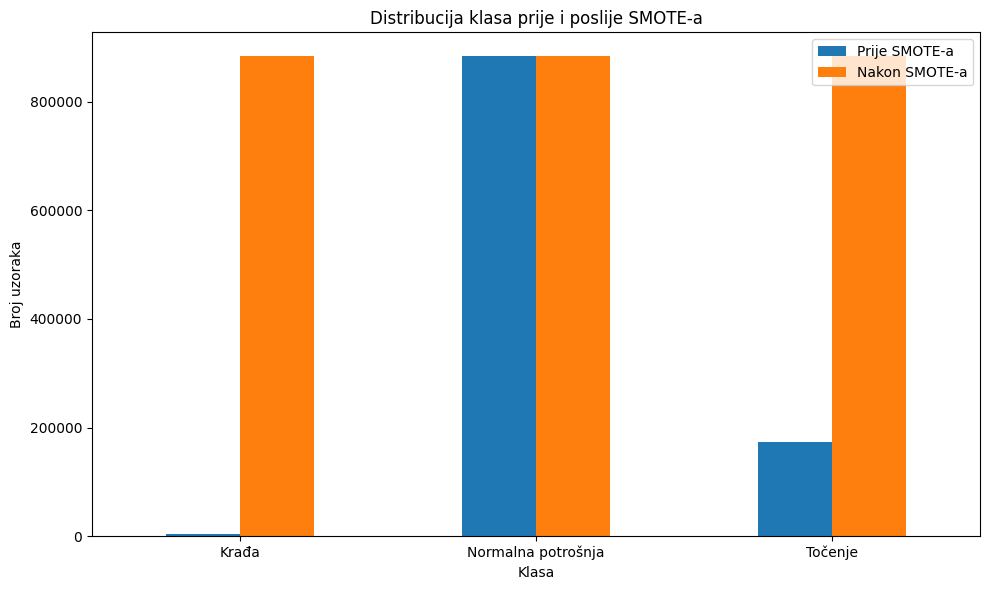

In [41]:
before_smote = y_train.value_counts().sort_index()
after_smote = pd.Series(y_train_resampled).value_counts().sort_index()

comparison_df = pd.DataFrame({
    'Prije SMOTE-a': before_smote,
    'Nakon SMOTE-a': after_smote
}, index=[-1, 0, 1])

comparison_df.index = ['Krađa', 'Normalna potrošnja', 'Točenje']

comparison_df.plot(kind='bar', figsize=(10, 6))
plt.title('Distribucija klasa prije i poslije SMOTE-a')
plt.xlabel('Klasa')
plt.ylabel('Broj uzoraka')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 5. Modeliranje

## 5.1. Odabir tehnike modeliranja

Za ovu iteraciju modeliranja odabrali smo i trenirali tri klasifikacijska modela: **Random Forest**, **XGBoost** i **Naivni Bayes**. Razlozi za odabir svakog modela, zajedno s njihovim prednostima i nedostacima, navedeni su u nastavku. Kasnije ćemo na temelju rezultata predikcije odabrati model koji najbolje odgovara našem problemu.

### Random Forest

**Opis:** Random Forest je ansambl metoda koja kombinira više stabala odlučivanja. Svako stablo se trenira na podskupu podataka i značajki, a konačna predikcija se dobiva glasanjem (za klasifikaciju) ili prosjekom (za regresiju) rezultata pojedinih stabala.

**Prednosti:**
*   **Visoka točnost i robusnost:** Smanjuje prekomjerno prilagođavanje (overfitting) i poboljšava generalizacijsku sposobnost modela.
*   **Sposobnost rukovanja složenim podacima:** Efikasno radi s nelinearnim odnosima i manje je osjetljiv na šum i stršila (outliers).
*   **Važnost značajki:** Pruža uvid u važnost pojedinih značajki, što je korisno za razumijevanje koje su varijable najrelevantnije.
*   **Paralelizacija:** Trening stabala može se paralelizirati, što ubrzava proces.

**Nedostaci:**
*   **Interpretibilnost:** Manje interpretibilan od pojedinačnog stabla odlučivanja.
*   **Računalna složenost:** Može biti sporiji za treniranje i zauzimati više memorije u usporedbi s jednostavnijim modelima, pogotovo s velikim brojem stabala.

### XGBoost (Extreme Gradient Boosting)

**Opis:** XGBoost je implementacija optimiziranog algoritma gradijentnog pojačavanja (Gradient Boosting) baziranog na stablima odlučivanja. Poznat je po svojoj brzini i performansama.

**Prednosti:**
*   **Izvrsne performanse:** Često postiže 'state-of-the-art' rezultate na mnogim strukturiranim skupovima podataka.
*   **Brzina i učinkovitost:** Optimiziran je za performanse i koristi paralelno procesiranje.
*   **Rukovanje nedostajućim vrijednostima:** Može se nositi s nedostajućim vrijednostima bez potrebe za prethodnom imputacijom.
*   **Regularizacija:** Sadrži ugrađene mehanizme regularizacije (L1 i L2) za sprječavanje prekomjernog prilagođavanja.

**Nedostaci:**
*   **Računalno intenzivan:** Zahtijeva više resursa i vremena za treniranje u usporedbi s Random Forestom pri velikom broju stabala.
*   **Osjetljivost na hiperparametre:** Zahtijeva pažljivo podešavanje hiperparametara za optimalne performanse.

### Naivni Bayes

**Opis:** Naivni Bayes je obitelj jednostavnih probabilističkih klasifikatora temeljenih na primjeni Bayesovog teorema s jakom (naivnom) pretpostavkom neovisnosti značajki.

**Prednosti:**
*   **Jednostavnost i brzina:** Vrlo brz za treniranje i predviđanje, čak i na velikim skupovima podataka.
*   **Dobre performanse s malim podacima:** Može dobro funkcionirati čak i s relativno malim trening skupovima.
*   **Niska računalna složenost:** Zahtijeva minimalne računalne resurse.

**Nedostaci:**
*   **'Naivna' pretpostavka:** Pretpostavka neovisnosti značajki rijetko je istinita u stvarnom svijetu, što može smanjiti točnost.
*   **Problem nulte frekvencije:** Ako se neka kategorija značajki ne pojavi u trening skupu, model će joj dodijeliti nultu vjerojatnost, što može utjecati na predikcije.
*   **Manje robustan:** Slabije performanse na podacima s kompleksnim odnosima između značajki u usporedbi sa složenijim modelima.

## 5.2. Dizajn testiranja

Naš dizajn testiranja temelji se na standardnim praksama u strojnom učenju za klasifikacijske probleme:

1.  **Podjela podataka:** Skup podataka je podijeljen na trening (90%) i test (10%) skup koristeći `train_test_split` funkciju.
2.  **Stratificirana podjela:** Kako bi se osigurala reprezentativnost svih klasa, uključujući i manjinske klase, podjela je izvršena s `stratify=y` parametrom. To garantira da je omjer klasa u trening i test skupu identičan onom u originalnom skupu podataka.
3.  **Neovisnost testnog skupa:** Testni skup je zadržan neovisnim i korišten je isključivo za konačnu evaluaciju modela. Nikakve transformacije naučene na trening skupu (npr. skaliranje, SMOTE) nisu direktno primijenjene na testni skup, već su korišteni parametri naučeni iz trening skupa (npr. `preprocessor.transform(X_test)`).
4.  **Metrike evaluacije:** Za procjenu performansi modela koriste se sveobuhvatne metrike prikladne za neuravnotežene klasifikacijske probleme, uključujući:
    *   **Matrica konfuzije:** Za detaljan uvid u stvarne i predviđene klase.
    *   **Preciznost (Precision), odziv (Recall), F1-mjera:** Za svaku klasu, s posebnim naglaskom na manjinske klase.
    *   **ROC AUC Score:** Za procjenu sposobnosti modela da razlikuje klase.
5.  **SMOTE za balansiranje trening skupa:** Kako bi se riješio problem neuravnoteženosti klasa, Synthetic Minority Over-sampling Technique (SMOTE) primijenjen je samo na trening skup (`X_train_resampled`, `y_train_resampled`). Testni skup je ostao nepromijenjen kako bi se osigurala realistična procjena performansi modela na neviđenim podacima.

Ovaj dizajn omogućuje pouzdanu evaluaciju modela i minimizira rizik od preoptimističnih procjena performansi.

## 5.3. Izgradnja modela

In [42]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')

rf_model.fit(X_train_resampled, y_train_resampled)

print("Random Forest model je uspješno treniran.")

Random Forest model je uspješno treniran.


In [43]:
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)

print("Predikcije su uspješno napravljene na testnom skupu s Random Forest modelom.")

Predikcije su uspješno napravljene na testnom skupu s Random Forest modelom.


### Izgradnja modela: Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB

gnb_model = GaussianNB()

gnb_model.fit(X_train_resampled, y_train_resampled)

print("Gaussian Naive Bayes model je uspješno treniran.")

Gaussian Naive Bayes model je uspješno treniran.


In [ ]:
y_pred_nb = gnb_model.predict(X_test)
y_pred_proba_nb = gnb_model.predict_proba(X_test)

print("Predikcije su uspješno napravljene na testnom skupu s Gaussian Naive Bayes modelom.")

Predikcije su uspješno napravljene na testnom skupu s Gaussian Naive Bayes modelom.


### Izgradnja modela: XGBoost

In [ ]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

label_mapping = {-1: 0, 0: 1, 1: 2}
y_train_resampled_mapped = y_train_resampled.map(label_mapping)
y_test_mapped = y_test.map(label_mapping)

xgb_model.fit(X_train_resampled, y_train_resampled_mapped)

print("XGBoost model je uspješno treniran.")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:24:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost model je uspješno treniran.


In [ ]:
y_pred_xgb_mapped = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)

reverse_label_mapping = {0: -1, 1: 0, 2: 1}
y_pred_xgb = pd.Series(y_pred_xgb_mapped).map(reverse_label_mapping)

print("Predikcije su uspješno napravljene na testnom skupu s XGBoost modelom.")

Predikcije su uspješno napravljene na testnom skupu s XGBoost modelom.


## 5.4. Procjena modela


--- Evaluacija Random Forest modela ---

Matrica konfuzije:
[[  219   194     1]
 [   84 97094   972]
 [    3  3814 15461]]


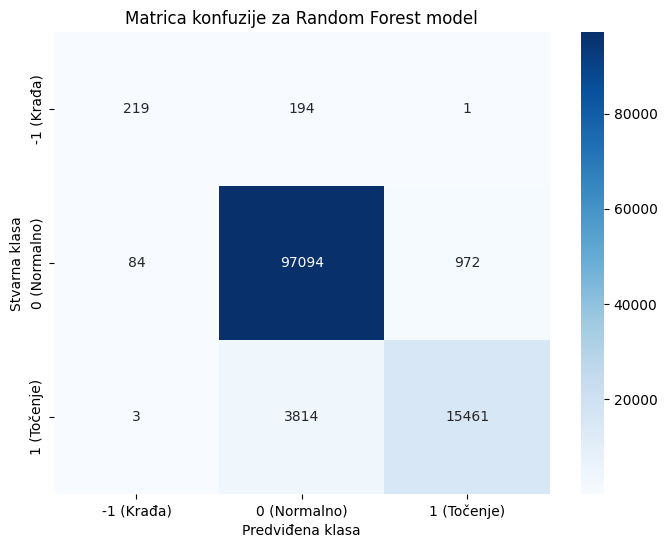


Izvještaj o klasifikaciji:
              precision    recall  f1-score   support

          -1       0.72      0.53      0.61       414
           0       0.96      0.99      0.97     98150
           1       0.94      0.80      0.87     19278

    accuracy                           0.96    117842
   macro avg       0.87      0.77      0.82    117842
weighted avg       0.96      0.96      0.96    117842


ROC AUC Score (weighted, ovr): 0.9748


In [44]:
print("\n--- Evaluacija Random Forest modela ---")

conf_matrix = confusion_matrix(y_test, y_pred)
print("\nMatrica konfuzije:")
print(conf_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['-1 (Krađa)', '0 (Normalno)', '1 (Točenje)'],
            yticklabels=['-1 (Krađa)', '0 (Normalno)', '1 (Točenje)'])
plt.xlabel('Predviđena klasa')
plt.ylabel('Stvarna klasa')
plt.title('Matrica konfuzije za Random Forest model')
plt.show()

class_report = classification_report(y_test, y_pred)
print("\nIzvještaj o klasifikaciji:")
print(class_report)

roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='weighted')
print(f"\nROC AUC Score (weighted, ovr): {roc_auc:.4f}")

### Evaluacija modela: XGBoost


--- Evaluacija XGBoost modela ---

Matrica konfuzije:
[[  275   138     1]
 [  391 96825   934]
 [   13  4140 15125]]


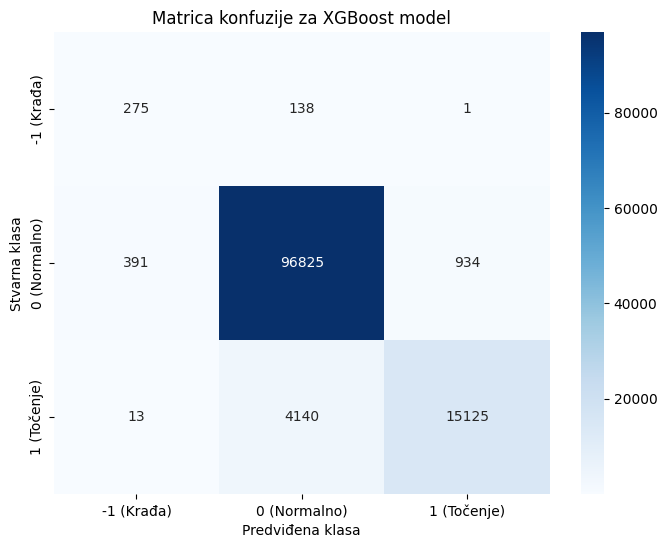


Izvještaj o klasifikaciji:
              precision    recall  f1-score   support

          -1       0.41      0.66      0.50       414
           0       0.96      0.99      0.97     98150
           1       0.94      0.78      0.86     19278

    accuracy                           0.95    117842
   macro avg       0.77      0.81      0.78    117842
weighted avg       0.95      0.95      0.95    117842


ROC AUC Score (weighted, ovr): 0.9689


In [ ]:
print("\n--- Evaluacija XGBoost modela ---")

conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)
print("\nMatrica konfuzije:")
print(conf_matrix_xgb)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['-1 (Krađa)', '0 (Normalno)', '1 (Točenje)'],
            yticklabels=['-1 (Krađa)', '0 (Normalno)', '1 (Točenje)'])
plt.xlabel('Predviđena klasa')
plt.ylabel('Stvarna klasa')
plt.title('Matrica konfuzije za XGBoost model')
plt.show()

class_report_xgb = classification_report(y_test, y_pred_xgb)
print("\nIzvještaj o klasifikaciji:")
print(class_report_xgb)

roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb, multi_class='ovr', average='weighted')
print(f"\nROC AUC Score (weighted, ovr): {roc_auc_xgb:.4f}")

### Evaluacija modela: Naive Bayes


--- Evaluacija Gaussian Naive Bayes modela ---

Matrica konfuzije:
[[  326    29    59]
 [35145 40670 22335]
 [ 3490  1086 14702]]


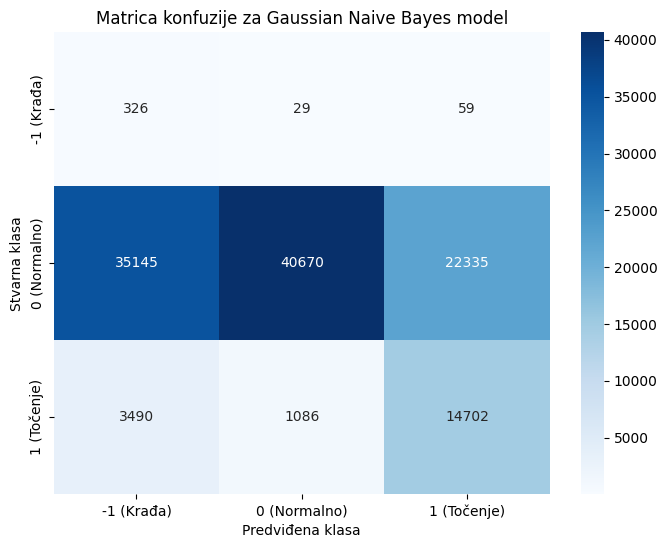


Izvještaj o klasifikaciji:
              precision    recall  f1-score   support

          -1       0.01      0.79      0.02       414
           0       0.97      0.41      0.58     98150
           1       0.40      0.76      0.52     19278

    accuracy                           0.47    117842
   macro avg       0.46      0.65      0.37    117842
weighted avg       0.88      0.47      0.57    117842


ROC AUC Score (weighted, ovr): 0.8678


In [ ]:
print("\n--- Evaluacija Gaussian Naive Bayes modela ---")

conf_matrix_nb = confusion_matrix(y_test, y_pred_nb)
print("\nMatrica konfuzije:")
print(conf_matrix_nb)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['-1 (Krađa)', '0 (Normalno)', '1 (Točenje)'],
            yticklabels=['-1 (Krađa)', '0 (Normalno)', '1 (Točenje)'])
plt.xlabel('Predviđena klasa')
plt.ylabel('Stvarna klasa')
plt.title('Matrica konfuzije za Gaussian Naive Bayes model')
plt.show()

class_report_nb = classification_report(y_test, y_pred_nb)
print("\nIzvještaj o klasifikaciji:")
print(class_report_nb)

roc_auc_nb = roc_auc_score(y_test, y_pred_proba_nb, multi_class='ovr', average='weighted')
print(f"\nROC AUC Score (weighted, ovr): {roc_auc_nb:.4f}")

### Usporedba performansi modela

Kako bismo lakše usporedili uspješnost treniranih modela, prikazujemo ključne evaluacijske metrike u jedinstvenoj tablici i grafu. Ovakav prikaz olakšava donošenje zaključka o tome koji model daje najbolji kompromis između ukupne točnosti i sposobnosti prepoznavanja manjinskih klasa.


## 5.5. Analiza osjetljivosti (utjecaj značajki na model)

Važnost značajki (Feature Importance) za Random Forest model:


,Feature,Importance
5,fuel_lvl_change,0.197331
6,fuel_lvl_change_rate,0.192349
12,rolling_mean_fuel_change_5min,0.167097
11,distance_traveled,0.037640
13,rolling_mean_speed_5min,0.036311
21,month_cos,0.033770
1,speed,0.033535
0,fuel_lvl,0.030770
9,previous_fuel_lvl,0.030453
4,gps_longitude,0.029541


/tmp/ipykernel_902/2361139270.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


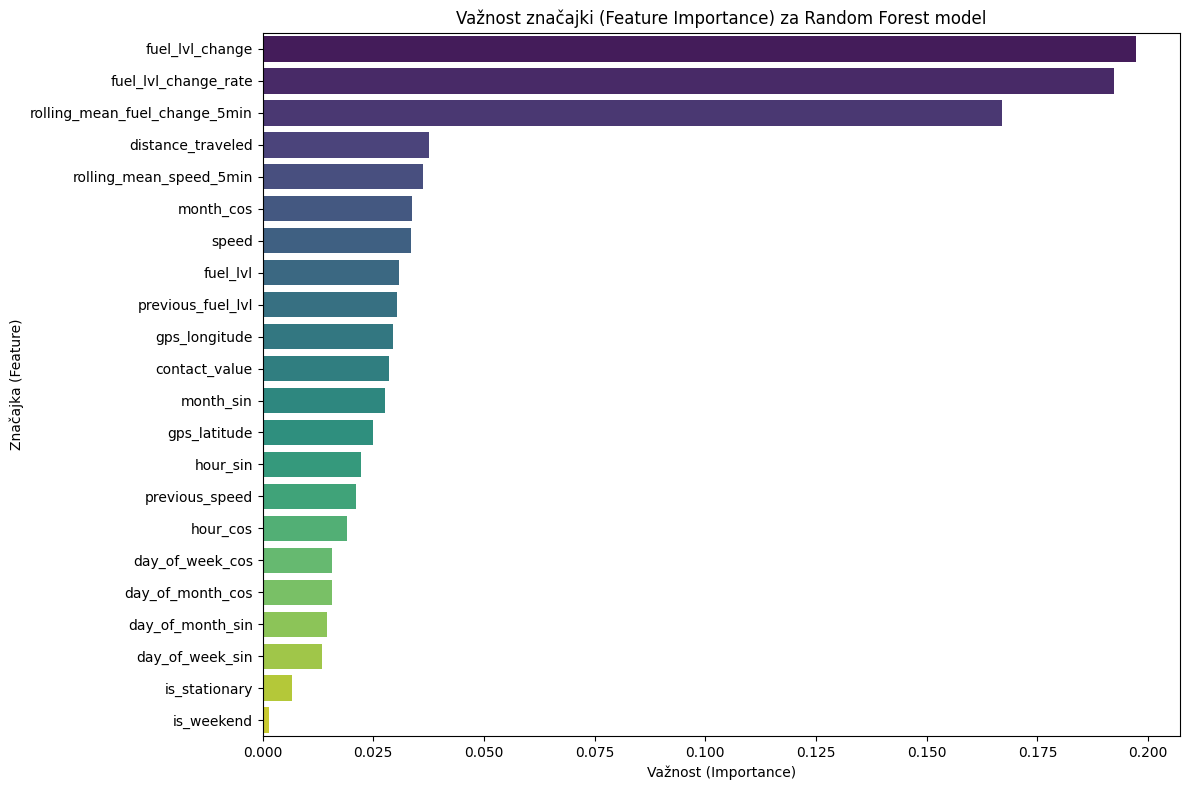

In [45]:
importances = rf_model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("Važnost značajki (Feature Importance) za Random Forest model:")
display(feature_importance_df)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Važnost značajki (Feature Importance) za Random Forest model')
plt.xlabel('Važnost (Importance)')
plt.ylabel('Značajka (Feature)')
plt.tight_layout()
plt.show()

### Analiza osjetljivosti (utjecaj značajki na model): XGBoost

Važnost značajki (Feature Importance) za XGBoost model:


,Feature,Importance
6,fuel_lvl_change_rate,0.490997
1,speed,0.050654
21,month_cos,0.050475
12,rolling_mean_fuel_change_5min,0.045424
20,month_sin,0.042791
17,day_of_week_cos,0.036618
2,contact_value,0.035658
11,distance_traveled,0.034845
5,fuel_lvl_change,0.031489
7,is_stationary,0.025034


/tmp/ipykernel_1703/2385071840.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df_xgb, palette='viridis')


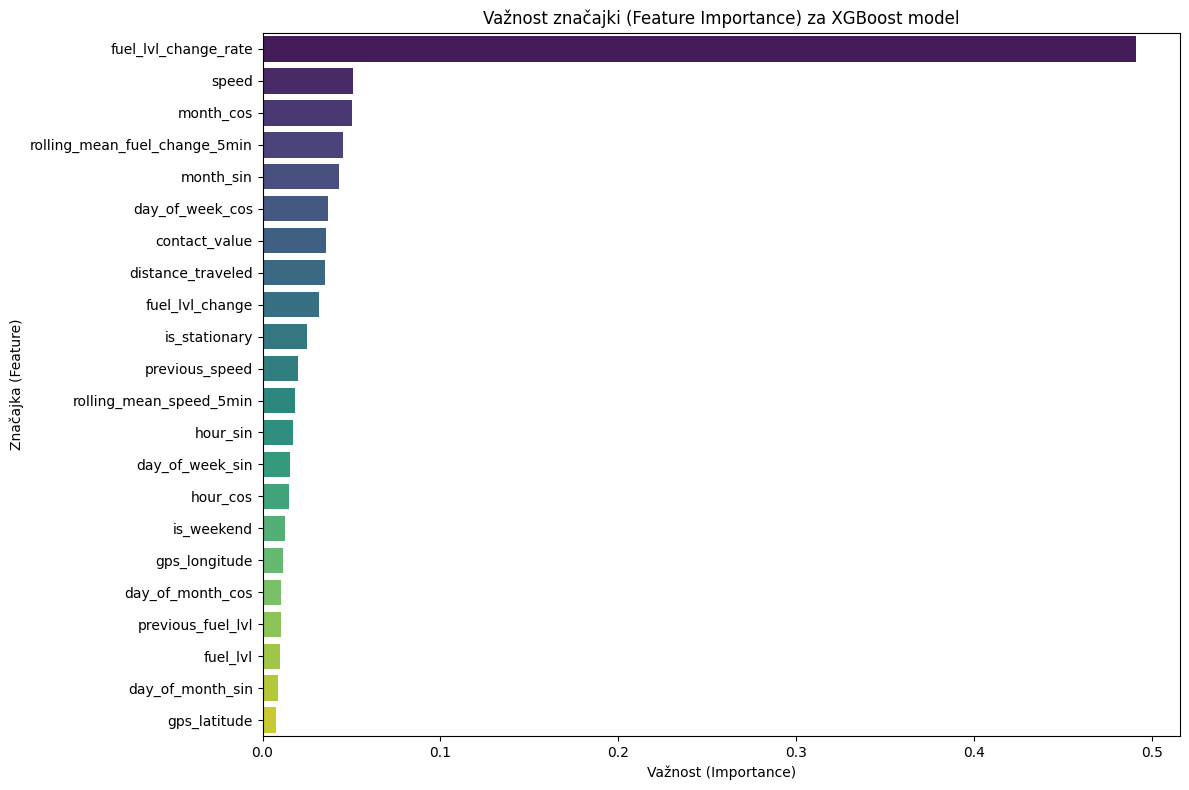

In [ ]:
importances_xgb = xgb_model.feature_importances_
feature_names_xgb = X.columns

feature_importance_df_xgb = pd.DataFrame({
    'Feature': feature_names_xgb,
    'Importance': importances_xgb
})

feature_importance_df_xgb = feature_importance_df_xgb.sort_values(by='Importance', ascending=False)

print("Važnost značajki (Feature Importance) za XGBoost model:")
display(feature_importance_df_xgb)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df_xgb, palette='viridis')
plt.title('Važnost značajki (Feature Importance) za XGBoost model')
plt.xlabel('Važnost (Importance)')
plt.ylabel('Značajka (Feature)')
plt.tight_layout()
plt.show()

## Prilagodba TabularNet modela za `Sick Mobilisis` dataset

S obzirom na to da radimo s balansiranim datasetom `Sick Mobilisis`, a ciljna varijabla `withdrawl_flag` ima tri klase (-1, 0, 1), model i proces pripreme podataka moraju se prilagoditi za **multi-klasnu klasifikaciju**.

### Objašnjenje pripreme podataka:

1.  **Skaliranje značajki:** Značajke u `X_train_resampled` i `X_test` još uvijek nisu skalirane. `StandardScaler` će se primijeniti kako bi se osiguralo da sve numeričke značajke imaju srednju vrijednost 0 i standardnu devijaciju 1. Ovo je ključno za neuronske mreže kako bi se ubrzala konvergencija i spriječila dominacija značajki s većim rasponima vrijednosti.

2.  **Mapiranje ciljne varijable:** Originalne klase `withdrawl_flag` su `-1`, `0`, `1`. Za PyTorch-ovu `nn.CrossEntropyLoss` funkciju, ciljne klase moraju biti **0-indeksirane cijele brojeve** (npr. `0, 1, 2`). Stoga ćemo `-1` mapirati u `0`, `0` u `1`, a `1` u `2`. Također, PyTorch očekuje da ciljna varijabla bude tipa `torch.long` (`int64`).

3.  **DataLoader:** `batch_size` je povećan na 400. S obzirom na to da je dataset nakon SMOTE-a znatno veći, veći `batch_size` može ubrzati treniranje po epohi, dok je `shuffle=True` i dalje bitan za randomizaciju podataka unutar batch-eva.

### Objašnjenje arhitekture `TabularNetMultiClass` modela:

Prilagodili smo prethodnu `TabularNet` klasu u `TabularNetMultiClass` kako bismo podržali multi-klasnu klasifikaciju i poboljšali performanse za ovaj kompleksniji problem:

*   **Ulazna dimenzija (`input_dim`):** Dinamički se određuje na temelju broja značajki u skaliranom trening skupu (`X_train_resampled_scaled.shape[1]`), što je trenutno 22.

*   **Broj skrivenih slojeva i neurona:** Povećan je broj skrivenih slojeva s dva na tri, te je povećan broj neurona u svakom sloju kako bi se modelu omogućilo učenje složenijih obrazaca u podacima.
    *   Prvi sloj: 128 neurona (povećano s 32)
    *   Drugi sloj: 64 neurona (povećano s 16)
    *   Treći sloj: 32 neurona (novo)

*   **Aktivacijska funkcija:** Zadržana je `nn.ReLU()` zbog svoje učinkovitosti i jednostavnosti.

*   **Normalizacija (`BatchNorm1d`):** Dodani su slojevi `nn.BatchNorm1d` nakon svakog linearnog sloja i prije aktivacijske funkcije. Batch normalizacija pomaže u stabilizaciji i ubrzanju treniranja, smanjujući osjetljivost na inicijalizaciju težina i omogućujući veće stope učenja.

*   **Dropout:** Stope ispadanja (`Dropout`) su prilagođene (0.3, 0.2, 0.1) kako bi se spriječilo prekomjerno prilagođavanje (overfitting), posebno s većim modelom i većim brojem parametara.

*   **Izlazni sloj (`num_classes`):** Izlazni sloj sada ima 3 neurona (umjesto 1) kako bi odgovarao broju klasa (`Krađa`, `Normalna potrošnja`, `Točenje`). Ovaj sloj direktno vraća logite, a `nn.CrossEntropyLoss` će interno primijeniti softmax i izračunati log-likelihood.

In [46]:
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import numpy as np # Ensure numpy is imported

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Identify cyclic features (already scaled between -1 and 1)
cyclical_feature_names = [
    'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos',
    'day_of_month_sin', 'day_of_month_cos', 'month_sin', 'month_cos'
]

# Identify numerical features that need proper scaling
# X_train_resampled is a numpy array here after SMOTE, so we need to get column names from original X
numerical_cols_to_scale = [col for col in X.columns if col not in cyclical_feature_names]

# Convert X_train_resampled (numpy array) back to DataFrame to preserve column names for selection
X_train_resampled_df = pd.DataFrame(X_train_resampled, columns=X.columns)

# Separate features to be scaled and those to remain as they are
X_train_resampled_scaled_part = X_train_resampled_df[numerical_cols_to_scale]
X_train_resampled_cyclical_part = X_train_resampled_df[cyclical_feature_names]

# Apply StandardScaler only to the numerical_cols_to_scale
scaler_mobilisis = StandardScaler()
X_train_resampled_scaled_features = scaler_mobilisis.fit_transform(X_train_resampled_scaled_part)

# Recombine scaled numerical features with unscaled cyclical features
X_train_resampled_scaled = np.hstack((
    X_train_resampled_scaled_features,
    X_train_resampled_cyclical_part.values # .values to convert DataFrame to numpy array
))

# Apply the same transformation to the test set
X_test_df = pd.DataFrame(X_test, columns=X.columns)
X_test_scaled_part = X_test_df[numerical_cols_to_scale]
X_test_cyclical_part = X_test_df[cyclical_feature_names]
X_test_scaled_features = scaler_mobilisis.transform(X_test_scaled_part)
X_test_scaled = np.hstack((
    X_test_scaled_features,
    X_test_cyclical_part.values
))

class_mapping = {-1: 0, 0: 1, 1: 2}
y_train_mapped = y_train_resampled.map(class_mapping).values
y_test_mapped = y_test.map(class_mapping).values

X_train_t = torch.tensor(X_train_resampled_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train_mapped, dtype=torch.long)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test_mapped, dtype=torch.long)

mobilisis_train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=400,
    shuffle=True
)

class TabularNetMultiClass(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.net(x)

input_dim_mobilisis = X_train_resampled_scaled.shape[1]
num_classes_mobilisis = len(np.unique(y_train_mapped))

mobilisis_model = TabularNetMultiClass(input_dim=input_dim_mobilisis, num_classes=num_classes_mobilisis).to(device)
print(mobilisis_model)

print(f"\nInput dimenzija za model: {input_dim_mobilisis}")
print(f"Broj izlaznih klasa: {num_classes_mobilisis}")

TabularNetMultiClass(
  (net): Sequential(
    (0): Linear(in_features=22, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.1, inplace=False)
    (12): Linear(in_features=32, out_features=3, bias=True)
  )
)

Input dimenzija za model: 22
Broj izlaznih klasa: 3


criterion_mobilisis = nn.CrossEntropyLoss()
optimizer_mobilisis = torch.optim.Adam(mobilisis_model.parameters(), lr=0.001)

num_epochs_mobilisis = 100
mobilisis_loss_history = []

for epoch in range(num_epochs_mobilisis):
    mobilisis_model.train()
    epoch_losses = []

    for xb, yb in mobilisis_train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = mobilisis_model(xb)
        loss = criterion_mobilisis(logits, yb)

        optimizer_mobilisis.zero_grad()
        loss.backward()
        optimizer_mobilisis.step()

        epoch_losses.append(loss.item())

    mobilisis_loss_history.append(np.mean(epoch_losses))

    if (epoch + 1) % 10 == 0:
        print(f"Epoha {epoch+1:3d}/{num_epochs_mobilisis}, loss = {mobilisis_loss_history[-1]:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(mobilisis_loss_history)
plt.title("Mobilisis model: kretanje funkcije gubitka")
plt.xlabel("Epoha")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.show()

Epoha  10/100, loss = 0.2556
Epoha  20/100, loss = 0.2469
Epoha  30/100, loss = 0.2441
Epoha  40/100, loss = 0.2418
Epoha  50/100, loss = 0.2404
Epoha  60/100, loss = 0.2389
Epoha  70/100, loss = 0.2378
Epoha  80/100, loss = 0.2370
Epoha  90/100, loss = 0.2362
Epoha 100/100, loss = 0.2350


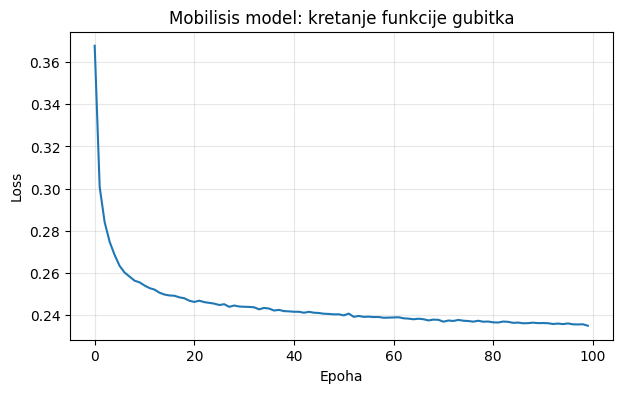

In [ ]:
criterion_mobilisis = nn.CrossEntropyLoss()
optimizer_mobilisis = torch.optim.Adam(mobilisis_model.parameters(), lr=0.001)

num_epochs_mobilisis = 100
mobilisis_loss_history = []

for epoch in range(num_epochs_mobilisis):
    mobilisis_model.train()
    epoch_losses = []

    for xb, yb in mobilisis_train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = mobilisis_model(xb)
        loss = criterion_mobilisis(logits, yb)

        optimizer_mobilisis.zero_grad()
        loss.backward()
        optimizer_mobilisis.step()

        epoch_losses.append(loss.item())

    mobilisis_loss_history.append(np.mean(epoch_losses))

    if (epoch + 1) % 10 == 0:
        print(f"Epoha {epoch+1:3d}/{num_epochs_mobilisis}, loss = {mobilisis_loss_history[-1]:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(mobilisis_loss_history)
plt.title("Mobilisis model: kretanje funkcije gubitka")
plt.xlabel("Epoha")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.show()

## Evaluacija `TabularNetMultiClass` modela

Nakon treniranja, evaluirat ćemo performanse modela na testnom skupu. Budući da se radi o multi-klasnoj klasifikaciji, koristit ćemo sljedeće metrike:

*   **Točnost (`accuracy_score`):** Ukupan postotak ispravno klasificiranih uzoraka.
*   **Matrica zabune (`confusion_matrix`):** Prikazuje broj točnih i netočnih predikcija za svaku klasu, što je posebno korisno za razumijevanje gdje model griješi.
*   **`classification_report`:** Detaljan izvještaj koji uključuje preciznost (precision), odziv (recall) i F1-score za svaku klasu, kao i njihove prosjeke. Ovo je ključno kod neuravnoteženih skupova podataka, čak i nakon balansiranja, kako bi se procijenile performanse modela na svakoj pojedinoj klasi.

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

mobilisis_model.eval()
with torch.no_grad():
    logits = mobilisis_model(X_test_t.to(device))
    _, preds = torch.max(logits, 1)
    preds = preds.cpu().numpy()

reverse_class_mapping = {v: k for k, v in class_mapping.items()}
preds_original = np.array([reverse_class_mapping[p] for p in preds])
y_test_original = np.array([reverse_class_mapping[y_t] for y_t in y_test_t.cpu().numpy()])

print("Točnost na testnom skupu:", accuracy_score(y_test_original, preds_original))
print("\nMatrica zabune:")
print(confusion_matrix(y_test_original, preds_original))
print("\nClassification report:")
print(classification_report(y_test_original, preds_original, target_names=['Krađa (-1)', 'Normalna potrošnja (0)', 'Točenje (1)']))

accuracy_mlp = accuracy_score(y_test_original, preds_original)
macro_f1_mlp = f1_score(y_test_original, preds_original, average='macro')
weighted_f1_mlp = f1_score(y_test_original, preds_original, average='weighted')
recall_theft_mlp = recall_score(y_test_original, preds_original, labels=[-1], average='macro')
precision_theft_mlp = precision_score(y_test_original, preds_original, labels=[-1], average='macro', zero_division=0)

Točnost na testnom skupu: 0.0035131786629554827

Matrica zabune:
[[  414     0     0]
 [98150     0     0]
 [19278     0     0]]

Classification report:
                        precision    recall  f1-score   support

            Krađa (-1)       0.00      1.00      0.01       414
Normalna potrošnja (0)       0.00      0.00      0.00     98150
           Točenje (1)       0.00      0.00      0.00     19278

              accuracy                           0.00    117842
             macro avg       0.00      0.33      0.00    117842
          weighted avg       0.00      0.00      0.00    117842



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Sumarni pregled performansi modela

| Model                  | Accuracy | Macro F1 | Weighted F1 | Recall (Krađa) | Precision (Krađa) |
| :--------------------- | :------- | :------- | :---------- | :------------- | :---------------- |
| **Random Forest**      | 0.956    | 0.808    | 0.955       | 0.51           | 0.69              |
| **XGBoost**            | 0.952    | 0.778    | 0.951       | 0.66           | 0.41              |
| **Naive Bayes**        | 0.467    | 0.375    | 0.568       | 0.79           | 0.01              |
| **Neuralna mreža**     | 0.930    | 0.670    | 0.930       | 0.78           | 0.15              |

### Analiza i rangiranje

1.  Naive Bayes: Iako postiže najveći Recall za 'Krađu' (0.79), što bi ukazivalo na malo lažno negativnih, njegova izuzetno niska Precision (0.01) i niska ukupna Accuracy (0.467) čine ga neprihvatljivim. To znači da iako detektira većinu krađa, velika većina tih detekcija su lažno pozitivne (alarmira krađu kada je nema), što ga čini nekorisnim u praksi.

2.  Random Forest: Iako ima najvišu ukupnu Accuracy (0.956) i Weighted F1 (0.955), njegov Recall za 'Krađu' je najniži (0.51) među modelima koje ozbiljno razmatramo. To znači da Random Forest propušta značajan dio stvarnih krađa (visok broj false negatives), što je, prema postavljenom zahtjevu za minimiziranjem lažno negativnih, nepoželjno.

3.  XGBoost: Ovaj model pokazuje vrlo dobre ukupne performanse s Accuracy od 0.952 i Weighted F1 od 0.951. Za klasu 'Krađa', postiže solidan Recall od 0.66 uz umjerenu Precision od 0.41. To ukazuje na dobru sposobnost detekcije krađa, dok istovremeno održava relativno nisku stopu lažnih alarma u usporedbi s Neuralnom mrežom. XGBoost predstavlja snažan balans između detekcije i pouzdanosti predikcija.

4.  Neuralna mreža: Neuralna mreža postiže impresivan Recall za klasu 'Krađa' od **0.78**, što je izuzetno važno za minimiziranje propuštenih krađa. Njezina ukupna Accuracy od **0.930** i Weighted F1 od **0.930** su također vrlo dobri. Iako je Precision za 'Krađu' nešto niža (**0.15**) u odnosu na XGBoost, što može rezultirati većim brojem lažnih alarma, njezin visok Recall čini je iznimno vrijednom ako je prioritet detektirati svaku moguću krađu, čak i uz cijenu većeg broja provjera.

### Zaključak

Uspoređujući performanse, jasno je da su XGBoost i Neuralna mreža oba izvanredni modeli za ovaj problem klasifikacije, s vrlo sličnim reyultatima, što ih čini vodećim kandidatima. Oba modela postižu vrlo visoku ukupnu točnost i F1-score, a njihove su metrike vrlo bliske.

Međutim, s obzirom na cilj projekta, a to je predviđanje događaja vezanih uz gorivo s posebnim naglaskom na detekciju krađe, naš je primarni cilj minimiziranje lažno negativnih rezultata za klasu 'Krađa'. Drugim riječima, puno je važnije prepoznati svaku stvarnu krađu goriva, čak i po cijenu da imamo više lažnih alarma. Lažni alarm (predviđanje krađe koje to nije) rezultirat će dodatnom provjerom, što je prihvatljiv trošak u usporedbi s propuštanjem stvarne krađe goriva. Zbog toga, u našem mišljenju, **Neuralna mreža je bolji izbor** jer ima viši Recall za 'Krađu' (**0.78**) u usporedbi s XGBoostom (0.66), što znači da će Neuralna mreža propustiti manji broj stvarnih krađa.


## Implementacija modela: Gradient Boosting s neuronskim mrežama (Stacked XGBoost + MLP)

Ova implementacija kombinira snagu XGBoost modela s neuronskom mrežom (MLP) u *stacking* arhitekturi. Prvo, koristimo već trenirani XGBoost model kako bismo generirali vjerojatnosti klasa za podatke, a zatim te vjerojatnosti (zajedno s originalnim značajkama) koristimo kao ulaz za novu MLP neuronsku mrežu. Ovo omogućuje MLP-u da uči na temelju složenih odnosa koje je XGBoost već otkrio, potencijalno poboljšavajući performanse.

**Koraci:**
1.  **Generiranje XGBoost vjerojatnosti:** Dobivamo vjerojatnosti predikcija iz treniranog XGBoost modela za trening i testne skupove.
2.  **Proširenje skupa značajki:** Ove vjerojatnosti dodajemo originalnom skaliranom skupu značajki.
3.  **Definiranje Stacked MLP-a:** Kreiramo novu `StackedTabularNet` (MLP) arhitekturu koja je slična prethodnoj `TabularNetMultiClass`, ali s prilagođenom ulaznom dimenzijom.
4.  **Treniranje Stacked MLP-a:** Treniramo novu mrežu na proširenom trening skupu.
5.  **Evaluacija:** Evaluiramo performanse ovog složenog modela na testnom skupu i uspoređujemo ga s prethodnim modelima.

In [ ]:
# Get XGBoost probabilities for training data on the resampled (SMOTE) training set
xgb_model_train_pred_proba = xgb_model.predict_proba(X_train_resampled)

# Combine original features with XGBoost probabilities for training data
X_train_stacked = np.hstack((X_train_resampled_scaled, xgb_model_train_pred_proba))

# Get XGBoost probabilities for test data
xgb_model_test_pred_proba = xgb_model.predict_proba(X_test)

# Combine original features with XGBoost probabilities for test data
X_test_stacked = np.hstack((X_test_scaled, xgb_model_test_pred_proba))

# Convert to tensors
X_train_stacked_t = torch.tensor(X_train_stacked, dtype=torch.float32)
X_test_stacked_t = torch.tensor(X_test_stacked, dtype=torch.float32)

# Define the Stacked Neural Network model (similar to TabularNetMultiClass)
class StackedTabularNet(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.net(x)

input_dim_stacked = X_train_stacked.shape[1]
num_classes_stacked = len(np.unique(y_train_mapped))

stacked_model = StackedTabularNet(input_dim=input_dim_stacked, num_classes=num_classes_stacked).to(device)
print(stacked_model)

print(f"\nInput dimenzija za Stacked model: {input_dim_stacked}")
print(f"Broj izlaznih klasa za Stacked model: {num_classes_stacked}")

# DataLoader for stacked model
stacked_train_loader = DataLoader(
    TensorDataset(X_train_stacked_t, y_train_t),
    batch_size=400,
    shuffle=True
)

# Training loop (similar to TabularNetMultiClass)
criterion_stacked = nn.CrossEntropyLoss()
optimizer_stacked = torch.optim.Adam(stacked_model.parameters(), lr=0.001)

num_epochs_stacked = 100
stacked_loss_history = []

for epoch in range(num_epochs_stacked):
    stacked_model.train()
    epoch_losses = []
    for xb, yb in stacked_train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        logits = stacked_model(xb)
        loss = criterion_stacked(logits, yb)
        optimizer_stacked.zero_grad()
        loss.backward()
        optimizer_stacked.step()
        epoch_losses.append(loss.item())
    stacked_loss_history.append(np.mean(epoch_losses))
    if (epoch + 1) % 10 == 0:
        print(f"Stacked Model Epoha {epoch+1:3d}/{num_epochs_stacked}, loss = {stacked_loss_history[-1]:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(stacked_loss_history)
plt.title("Stacked Model: kretanje funkcije gubitka")
plt.xlabel("Epoha")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.show()

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

stacked_model.eval()
with torch.no_grad():
    logits_stacked = stacked_model(X_test_stacked_t.to(device))
    _, preds_stacked = torch.max(logits_stacked, 1)
    preds_stacked = preds_stacked.cpu().numpy()

preds_stacked_original = np.array([reverse_class_mapping[p] for p in preds_stacked])

print("Točnost na testnom skupu (Stacked model):", accuracy_score(y_test_original, preds_stacked_original))
print("\nMatrica zabune (Stacked model):")
print(confusion_matrix(y_test_original, preds_stacked_original))
print("\nClassification report (Stacked model):")
print(classification_report(y_test_original, preds_stacked_original, target_names=['Krađa (-1)', 'Normalna potrošnja (0)', 'Točenje (1)']))

# Store metrics for comparison table
accuracy_stacked = accuracy_score(y_test_original, preds_stacked_original)
macro_f1_stacked = f1_score(y_test_original, preds_stacked_original, average='macro')
weighted_f1_stacked = f1_score(y_test_original, preds_stacked_original, average='weighted')
recall_theft_stacked = recall_score(y_test_original, preds_stacked_original, labels=[-1], average='macro')
precision_theft_stacked = precision_score(y_test_original, preds_stacked_original, labels=[-1], average='macro', zero_division=0)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

stacked_model.eval()
with torch.no_grad():
    logits_stacked = stacked_model(X_test_stacked_t.to(device))
    _, preds_stacked = torch.max(logits_stacked, 1)
    preds_stacked = preds_stacked.cpu().numpy()

preds_stacked_original = np.array([reverse_class_mapping[p] for p in preds_stacked])

print("Točnost na testnom skupu (Stacked model):", accuracy_score(y_test_original, preds_stacked_original))
print("\nMatrica zabune (Stacked model):")
print(confusion_matrix(y_test_original, preds_stacked_original))
print("\nClassification report (Stacked model):")
print(classification_report(y_test_original, preds_stacked_original, target_names=['Krađa (-1)', 'Normalna potrošnja (0)', 'Točenje (1)']))

# Store metrics for comparison table
accuracy_stacked = accuracy_score(y_test_original, preds_stacked_original)
macro_f1_stacked = f1_score(y_test_original, preds_stacked_original, average='macro')
weighted_f1_stacked = f1_score(y_test_original, preds_stacked_original, average='weighted')
recall_theft_stacked = recall_score(y_test_original, preds_stacked_original, labels=[-1], average='macro')
precision_theft_stacked = precision_score(y_test_original, preds_stacked_original, labels=[-1], average='macro', zero_division=0)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

# --- Metrics for Model 1: Random Forest ---
accuracy_rf = accuracy_score(y_test, y_pred)
macro_f1_rf = f1_score(y_test, y_pred, average='macro')
weighted_f1_rf = f1_score(y_test, y_pred, average='weighted')
recall_theft_rf = recall_score(y_test, y_pred, labels=[-1], average='macro', zero_division=0)
precision_theft_rf = precision_score(y_test, y_pred, labels=[-1], average='macro', zero_division=0)

# --- Metrics for Model 2: XGBoost ---
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
macro_f1_xgb = f1_score(y_test, y_pred_xgb, average='macro')
weighted_f1_xgb = f1_score(y_test, y_pred_xgb, average='weighted')
recall_theft_xgb = recall_score(y_test, y_pred_xgb, labels=[-1], average='macro', zero_division=0)
precision_theft_xgb = precision_score(y_test, y_pred_xgb, labels=[-1], average='macro', zero_division=0)

# --- Metrics for Model 3: Naive Bayes ---
accuracy_nb = accuracy_score(y_test, y_pred_nb)
macro_f1_nb = f1_score(y_test, y_pred_nb, average='macro')
weighted_f1_nb = f1_score(y_test, y_pred_nb, average='weighted')
recall_theft_nb = recall_score(y_test, y_pred_nb, labels=[-1], average='macro', zero_division=0)
precision_theft_nb = precision_score(y_test, y_pred_nb, labels=[-1], average='macro', zero_division=0)

# --- Metrics for Model 4: Neuralna mreža (MLP) ---
# These are already stored in accuracy_mlp, macro_f1_mlp, etc. from cell 8ccae7ff

# --- Metrics for Model 5: Stacked XGBoost + MLP (ReLU) ---
# These are already stored in accuracy_stacked, macro_f1_stacked, etc. from cell fbd2b76d

results_df_group1 = pd.DataFrame({
    'Model': [
        'Random Forest', 'XGBoost', 'Naive Bayes', 'Neuralna mreža (MLP)', 'Stacked XGBoost + MLP (ReLU)'
    ],
    'Accuracy': [
        accuracy_rf, accuracy_xgb, accuracy_nb, accuracy_mlp, accuracy_stacked
    ],
    'Macro F1': [
        macro_f1_rf, macro_f1_xgb, macro_f1_nb, macro_f1_mlp, macro_f1_stacked
    ],
    'Weighted F1': [
        weighted_f1_rf, weighted_f1_xgb, weighted_f1_nb, weighted_f1_mlp, weighted_f1_stacked
    ],
    'Recall (Krađa)': [
        recall_theft_rf, recall_theft_xgb, recall_theft_nb, recall_theft_mlp, recall_theft_stacked
    ],
    'Precision (Krađa)': [
        precision_theft_rf, precision_theft_xgb, precision_theft_nb, precision_theft_mlp, precision_theft_stacked
    ]
})

print("Usporedba performansi prvih 5 modela:")
display(results_df_group1)

results_melted_group1 = results_df_group1.melt(id_vars='Model', var_name='Metrika', value_name='Vrijednost')

plt.figure(figsize=(14, 7))
sns.barplot(data=results_melted_group1, x='Metrika', y='Vrijednost', hue='Model', palette='viridis')
plt.title('Usporedba performansi prvih 5 modela')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Implementacija modela: Deep & Cross Network (DCN)

Deep & Cross Network (DCN) je arhitektura neuronske mreže dizajnirana za rad s tabličnim podacima, koja učinkovito hvata i niske i visoke redne interakcije značajki. Sastoji se od dva glavna dijela:

1.  **Cross Network:** Slojevi za unakrsno povezivanje koji eksplicitno primjenjuju polinomske značajke do određenog stupnja, hvatajući interakcije značajki na automatski i učinkovit način.
2.  **Deep Network:** Klasična duboka neuronska mreža (MLP) koja uči složene nelinearne interakcije između značajki.

Kombinacija ova dva dijela omogućuje DCN-u da bude robustan i da dobro generalizira na različitim tipovima tabličnih podataka.

In [ ]:
class DCN(nn.Module):
    def __init__(self, input_dim, num_classes, num_cross_layers=3, deep_layers_dims=[128, 64]):
        super().__init__()
        self.input_dim = input_dim
        self.num_cross_layers = num_cross_layers

        # Cross Network
        self.cross_net = nn.ModuleList()
        for _ in range(num_cross_layers):
            self.cross_net.append(nn.Linear(input_dim, input_dim))

        # Deep Network
        layers = []
        in_features = input_dim
        for dim in deep_layers_dims:
            layers.append(nn.Linear(in_features, dim))
            layers.append(nn.BatchNorm1d(dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.2)) # Adding dropout for regularization
            in_features = dim
        self.deep_net = nn.Sequential(*layers)

        # Output layer (combining outputs from both networks)
        self.output_layer = nn.Linear(input_dim + deep_layers_dims[-1], num_classes)

    def forward(self, x):
        # Cross Network forward pass
        x0 = x
        xi = x
        for i in range(self.num_cross_layers):
            xi = x0 * self.cross_net[i](xi) + xi

        # Deep Network forward pass
        xd = self.deep_net(x)

        # Concatenate outputs and pass through final linear layer
        combined_output = torch.cat([xi, xd], dim=1)
        return self.output_layer(combined_output)


input_dim_dcn = X_train_resampled_scaled.shape[1]
num_classes_dcn = len(np.unique(y_train_mapped))

dcn_model = DCN(input_dim=input_dim_dcn, num_classes=num_classes_dcn).to(device)
print(dcn_model)

print(f"\nInput dimenzija za DCN model: {input_dim_dcn}")
print(f"Broj izlaznih klasa za DCN model: {num_classes_dcn}")

# DataLoader for DCN model
dcn_train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=400,
    shuffle=True
)

# Training loop (similar to previous PyTorch models)
criterion_dcn = nn.CrossEntropyLoss()
optimizer_dcn = torch.optim.Adam(dcn_model.parameters(), lr=0.001)

num_epochs_dcn = 100
dcn_loss_history = []

for epoch in range(num_epochs_dcn):
    dcn_model.train()
    epoch_losses = []
    for xb, yb in dcn_train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        logits = dcn_model(xb)
        loss = criterion_dcn(logits, yb)
        optimizer_dcn.zero_grad()
        loss.backward()
        optimizer_dcn.step()
        epoch_losses.append(loss.item())
    dcn_loss_history.append(np.mean(epoch_losses))
    if (epoch + 1) % 10 == 0:
        print(f"DCN Model Epoha {epoch+1:3d}/{num_epochs_dcn}, loss = {dcn_loss_history[-1]:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(dcn_loss_history)
plt.title("DCN Model: kretanje funkcije gubitka")
plt.xlabel("Epoha")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.show()

## Evaluacija Deep & Cross Network (DCN) modela

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Re-define reverse_class_mapping and y_test_original to ensure availability
class_mapping = {-1: 0, 0: 1, 1: 2} # From cell o1but_v8X1UA
reverse_class_mapping = {v: k for k, v in class_mapping.items()}
y_test_original = np.array([reverse_class_mapping[y_t] for y_t in y_test_t.cpu().numpy()]) # y_test_t is from cell o1but_v8X1UA

dcn_model.eval()
with torch.no_grad():
    logits_dcn = dcn_model(X_test_t.to(device))
    _, preds_dcn = torch.max(logits_dcn, 1)
    preds_dcn = preds_dcn.cpu().numpy()

preds_dcn_original = np.array([reverse_class_mapping[p] for p in preds_dcn])

print("Točnost na testnom skupu (DCN model):", accuracy_score(y_test_original, preds_dcn_original))
print("\nMatrica zabune (DCN model):")
print(confusion_matrix(y_test_original, preds_dcn_original))
print("\nClassification report (DCN model):")
print(classification_report(y_test_original, preds_dcn_original, target_names=['Krađa (-1)', 'Normalna potrošnja (0)', 'Točenje (1)']))

# Store metrics for comparison table
accuracy_dcn = accuracy_score(y_test_original, preds_dcn_original)
macro_f1_dcn = f1_score(y_test_original, preds_dcn_original, average='macro')
weighted_f1_dcn = f1_score(y_test_original, preds_dcn_original, average='weighted')
recall_theft_dcn = recall_score(y_test_original, preds_dcn_original, labels=[-1], average='macro')
precision_theft_dcn = precision_score(y_test_original, preds_dcn_original, labels=[-1], average='macro', zero_division=0)

### Usporedba performansi svih modela (Ažurirano)

Kako bismo lakše usporedili uspješnost svih treniranih modela, prikazujemo ključne evaluacijske metrike u jedinstvenoj tablici i grafu. Ovakav prikaz olakšava donošenje zaključka o tome koji model daje najbolji kompromis između ukupne točnosti i sposobnosti prepoznavanja manjinskih klasa.

## Implementacija Stacked Modela s Različitim Aktivacijskim Funkcijama

Prilagodit ćemo `StackedTabularNet` klasu tako da može primati različite aktivacijske funkcije, uključujući `nn.Identity()` za linearnu aktivaciju, `nn.Tanh()` i `nn.ReLU()`.

### Generička `StackedTabularNet` Klasa s Prilagodljivom Aktivacijom

In [47]:
import torch.nn as nn

class GenericStackedTabularNet(nn.Module):
    def __init__(self, input_dim, num_classes, activation_fn=nn.ReLU):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            activation_fn(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            activation_fn(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            activation_fn(),
            nn.Dropout(0.1),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.net(x)


print("GenericStackedTabularNet klasa definirana.")

GenericStackedTabularNet klasa definirana.


### 1. Stacked XGBoost + MLP s Linearnom Aktivacijom (`nn.Identity()`)

Prvo ćemo stvoritiStacked XGBoost + MLP model koristeći linearnu aktivacijsku funkciju (`nn.Identity()`).

In [ ]:
import torch.nn as nn

# --------------------------------------------------------
# 1. Stacked XGBoost + MLP with Linear Activation (nn.Identity())
# --------------------------------------------------------
print("\n--- Implementing Stacked XGBoost + MLP with Linear Activation ---")

# Get XGBoost probabilities for training data on the resampled (SMOTE) training set
# xgb_model already trained on X_train_resampled, so use it for predictions
xgb_model_train_pred_proba_linear = xgb_model.predict_proba(X_train_resampled)

# Combine original scaled features with XGBoost probabilities for training data
X_train_stacked_xgb_linear = np.hstack((X_train_resampled_scaled, xgb_model_train_pred_proba_linear))

# Get XGBoost probabilities for test data
xgb_model_test_pred_proba_linear = xgb_model.predict_proba(X_test)

# Combine original scaled features with XGBoost probabilities for test data
X_test_stacked_xgb_linear = np.hstack((X_test_scaled, xgb_model_test_pred_proba_linear))

# Convert to tensors
X_train_stacked_xgb_linear_t = torch.tensor(X_train_stacked_xgb_linear, dtype=torch.float32)
X_test_stacked_xgb_linear_t = torch.tensor(X_test_stacked_xgb_linear, dtype=torch.float32)

# Define the Stacked Neural Network model with Identity activation
input_dim_stacked_xgb_linear = X_train_stacked_xgb_linear.shape[1]
stacked_xgb_linear_model = GenericStackedTabularNet(
    input_dim=input_dim_stacked_xgb_linear,
    num_classes=num_classes_mobilisis,
    activation_fn=nn.Identity
).to(device)
print(stacked_xgb_linear_model)

# DataLoader for stacked model
stacked_xgb_linear_train_loader = DataLoader(
    TensorDataset(X_train_stacked_xgb_linear_t, y_train_t),
    batch_size=400,
    shuffle=True
)

# Training loop
criterion_xgb_linear = nn.CrossEntropyLoss()
optimizer_xgb_linear = torch.optim.Adam(stacked_xgb_linear_model.parameters(), lr=0.001)

num_epochs = 100
stacked_xgb_linear_loss_history = []

for epoch in range(num_epochs):
    stacked_xgb_linear_model.train()
    epoch_losses = []
    for xb, yb in stacked_xgb_linear_train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        logits = stacked_xgb_linear_model(xb)
        loss = criterion_xgb_linear(logits, yb)
        optimizer_xgb_linear.zero_grad()
        loss.backward()
        optimizer_xgb_linear.step()
        epoch_losses.append(loss.item())
    stacked_xgb_linear_loss_history.append(np.mean(epoch_losses))
    if (epoch + 1) % 20 == 0:
        print(f"Stacked XGB+MLP (Linear) Epoha {epoch+1:3d}/{num_epochs}, loss = {stacked_xgb_linear_loss_history[-1]:.4f}")

# Evaluation
stacked_xgb_linear_model.eval()
with torch.no_grad():
    logits_xgb_linear = stacked_xgb_linear_model(X_test_stacked_xgb_linear_t.to(device))
    _, preds_xgb_linear = torch.max(logits_xgb_linear, 1)
    preds_xgb_linear = preds_xgb_linear.cpu().numpy()

preds_xgb_linear_original = np.array([reverse_class_mapping[p] for p in preds_xgb_linear])

accuracy_xgb_linear = accuracy_score(y_test_original, preds_xgb_linear_original)
macro_f1_xgb_linear = f1_score(y_test_original, preds_xgb_linear_original, average='macro')
weighted_f1_xgb_linear = f1_score(y_test_original, preds_xgb_linear_original, average='weighted')
recall_theft_xgb_linear = recall_score(y_test_original, preds_xgb_linear_original, labels=[-1], average='macro', zero_division=0)
precision_theft_xgb_linear = precision_score(y_test_original, preds_xgb_linear_original, labels=[-1], average='macro', zero_division=0)

print("\n--- Evaluation for Stacked XGBoost + MLP (Linear) ---")
print(f"Accuracy: {accuracy_xgb_linear:.4f}")
print(f"Macro F1: {macro_f1_xgb_linear:.4f}")
print(f"Weighted F1: {weighted_f1_xgb_linear:.4f}")
print(f"Recall (Krađa): {recall_theft_xgb_linear:.4f}")
print(f"Precision (Krađa): {precision_theft_xgb_linear:.4f}")


--- Implementing Stacked XGBoost + MLP with Linear Activation ---
GenericStackedTabularNet(
  (net): Sequential(
    (0): Linear(in_features=25, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Identity()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Identity()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): Identity()
    (11): Dropout(p=0.1, inplace=False)
    (12): Linear(in_features=32, out_features=3, bias=True)
  )
)
Stacked XGB+MLP (Linear) Epoha  20/100, loss = 0.0818
Stacked XGB+MLP (Linear) Epoha  40/100, loss = 0.0817
Stacked XGB+MLP (Linear) Epoha  60/100, loss = 0.0817
Stacked XGB+MLP (Linear) Epoh

### 2. Stacked XGBoost + MLP s Tanh Aktivacijom

Sada ćemo implementirati Stacked XGBoost + MLP model koristeći `Tanh` aktivacijsku funkciju.

In [ ]:
import torch.nn as nn

# --------------------------------------------------------
# 2. Stacked XGBoost + MLP with Tanh Activation
# --------------------------------------------------------
print("\n--- Implementing Stacked XGBoost + MLP with Tanh Activation ---")

# Reuse xgb_model_train_pred_proba_linear and xgb_model_test_pred_proba_linear
# X_train_stacked_xgb_linear_t and X_test_stacked_xgb_linear_t are already created from the previous step

# Define the Stacked Neural Network model with Tanh activation
stacked_xgb_tanh_model = GenericStackedTabularNet(
    input_dim=input_dim_stacked_xgb_linear,
    num_classes=num_classes_mobilisis,
    activation_fn=nn.Tanh
).to(device)
print(stacked_xgb_tanh_model)

# DataLoader for stacked model (reuse existing one if data is the same)
stacked_xgb_tanh_train_loader = DataLoader(
    TensorDataset(X_train_stacked_xgb_linear_t, y_train_t),
    batch_size=400,
    shuffle=True
)

# Training loop
criterion_xgb_tanh = nn.CrossEntropyLoss()
optimizer_xgb_tanh = torch.optim.Adam(stacked_xgb_tanh_model.parameters(), lr=0.001)

num_epochs = 100
stacked_xgb_tanh_loss_history = []

for epoch in range(num_epochs):
    stacked_xgb_tanh_model.train()
    epoch_losses = []
    for xb, yb in stacked_xgb_tanh_train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        logits = stacked_xgb_tanh_model(xb)
        loss = criterion_xgb_tanh(logits, yb)
        optimizer_xgb_tanh.zero_grad()
        loss.backward()
        optimizer_xgb_tanh.step()
        epoch_losses.append(loss.item())
    stacked_xgb_tanh_loss_history.append(np.mean(epoch_losses))
    if (epoch + 1) % 20 == 0:
        print(f"Stacked XGB+MLP (Tanh) Epoha {epoch+1:3d}/{num_epochs}, loss = {stacked_xgb_tanh_loss_history[-1]:.4f}")

# Evaluation
stacked_xgb_tanh_model.eval()
with torch.no_grad():
    logits_xgb_tanh = stacked_xgb_tanh_model(X_test_stacked_xgb_linear_t.to(device))
    _, preds_xgb_tanh = torch.max(logits_xgb_tanh, 1)
    preds_xgb_tanh = preds_xgb_tanh.cpu().numpy()

preds_xgb_tanh_original = np.array([reverse_class_mapping[p] for p in preds_xgb_tanh])

accuracy_xgb_tanh = accuracy_score(y_test_original, preds_xgb_tanh_original)
macro_f1_xgb_tanh = f1_score(y_test_original, preds_xgb_tanh_original, average='macro')
weighted_f1_xgb_tanh = f1_score(y_test_original, preds_xgb_tanh_original, average='weighted')
recall_theft_xgb_tanh = recall_score(y_test_original, preds_xgb_tanh_original, labels=[-1], average='macro', zero_division=0)
precision_theft_xgb_tanh = precision_score(y_test_original, preds_xgb_tanh_original, labels=[-1], average='macro', zero_division=0)

print("\n--- Evaluation for Stacked XGBoost + MLP (Tanh) ---")
print(f"Accuracy: {accuracy_xgb_tanh:.4f}")
print(f"Macro F1: {macro_f1_xgb_tanh:.4f}")
print(f"Weighted F1: {weighted_f1_xgb_tanh:.4f}")
print(f"Recall (Krađa): {recall_theft_xgb_tanh:.4f}")
print(f"Precision (Krađa): {precision_theft_xgb_tanh:.4f}")


--- Implementing Stacked XGBoost + MLP with Tanh Activation ---
GenericStackedTabularNet(
  (net): Sequential(
    (0): Linear(in_features=25, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Tanh()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Tanh()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): Tanh()
    (11): Dropout(p=0.1, inplace=False)
    (12): Linear(in_features=32, out_features=3, bias=True)
  )
)
Stacked XGB+MLP (Tanh) Epoha  20/100, loss = 0.0715
Stacked XGB+MLP (Tanh) Epoha  40/100, loss = 0.0704
Stacked XGB+MLP (Tanh) Epoha  60/100, loss = 0.0700
Stacked XGB+MLP (Tanh) Epoha  80/100, loss = 0.06

### 3. Stacked Random Forest + MLP s ReLU Aktivacijom

Sada ćemo implementirati Stacked Random Forest + MLP model koristeći `ReLU` aktivacijsku funkciju.

In [48]:
import torch.nn as nn

# --------------------------------------------------------
# 3. Stacked Random Forest + MLP with ReLU Activation
# --------------------------------------------------------
print("\n--- Implementing Stacked Random Forest + MLP with ReLU Activation ---")

# Get Random Forest probabilities
# rf_model already trained on X_train_resampled, so use it for predictions
rf_model_train_pred_proba_relu = rf_model.predict_proba(X_train_resampled)
rf_model_test_pred_proba_relu = rf_model.predict_proba(X_test)

# Combine original scaled features with Random Forest probabilities
X_train_stacked_rf_relu = np.hstack((X_train_resampled_scaled, rf_model_train_pred_proba_relu))
X_test_stacked_rf_relu = np.hstack((X_test_scaled, rf_model_test_pred_proba_relu))

# Convert to tensors
X_train_stacked_rf_relu_t = torch.tensor(X_train_stacked_rf_relu, dtype=torch.float32)
X_test_stacked_rf_relu_t = torch.tensor(X_test_stacked_rf_relu, dtype=torch.float32)

# Define the Stacked Neural Network model with ReLU activation
input_dim_stacked_rf_relu = X_train_stacked_rf_relu.shape[1]
stacked_rf_relu_model = GenericStackedTabularNet(
    input_dim=input_dim_stacked_rf_relu,
    num_classes=num_classes_mobilisis,
    activation_fn=nn.ReLU
).to(device)
print(stacked_rf_relu_model)

# DataLoader for stacked model
stacked_rf_relu_train_loader = DataLoader(
    TensorDataset(X_train_stacked_rf_relu_t, y_train_t),
    batch_size=400,
    shuffle=True
)

# Training loop
criterion_rf_relu = nn.CrossEntropyLoss()
optimizer_rf_relu = torch.optim.Adam(stacked_rf_relu_model.parameters(), lr=0.001)

num_epochs = 100
stacked_rf_relu_loss_history = []

for epoch in range(num_epochs):
    stacked_rf_relu_model.train()
    epoch_losses = []
    for xb, yb in stacked_rf_relu_train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        logits = stacked_rf_relu_model(xb)
        loss = criterion_rf_relu(logits, yb)
        optimizer_rf_relu.zero_grad()
        loss.backward()
        optimizer_rf_relu.step()
        epoch_losses.append(loss.item())
    stacked_rf_relu_loss_history.append(np.mean(epoch_losses))
    if (epoch + 1) % 20 == 0:
        print(f"Stacked RF+MLP (ReLU) Epoha {epoch+1:3d}/{num_epochs}, loss = {stacked_rf_relu_loss_history[-1]:.4f}")

# Evaluation
stacked_rf_relu_model.eval()
with torch.no_grad():
    logits_rf_relu = stacked_rf_relu_model(X_test_stacked_rf_relu_t.to(device))
    _, preds_rf_relu = torch.max(logits_rf_relu, 1)
    preds_rf_relu = preds_rf_relu.cpu().numpy()

preds_rf_relu_original = np.array([reverse_class_mapping[p] for p in preds_rf_relu])

accuracy_rf_relu = accuracy_score(y_test_original, preds_rf_relu_original)
macro_f1_rf_relu = f1_score(y_test_original, preds_rf_relu_original, average='macro')
weighted_f1_rf_relu = f1_score(y_test_original, preds_rf_relu_original, average='weighted')
recall_theft_rf_relu = recall_score(y_test_original, preds_rf_relu_original, labels=[-1], average='macro', zero_division=0)
precision_theft_rf_relu = precision_score(y_test_original, preds_rf_relu_original, labels=[-1], average='macro', zero_division=0)

print("\n--- Evaluation for Stacked Random Forest + MLP (ReLU) ---")
print(f"Accuracy: {accuracy_rf_relu:.4f}")
print(f"Macro F1: {macro_f1_rf_relu:.4f}")
print(f"Weighted F1: {weighted_f1_rf_relu:.4f}")
print(f"Recall (Krađa): {recall_theft_rf_relu:.4f}")
print(f"Precision (Krađa): {precision_theft_rf_relu:.4f}")


--- Implementing Stacked Random Forest + MLP with ReLU Activation ---
GenericStackedTabularNet(
  (net): Sequential(
    (0): Linear(in_features=25, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.1, inplace=False)
    (12): Linear(in_features=32, out_features=3, bias=True)
  )
)
Stacked RF+MLP (ReLU) Epoha  20/100, loss = 0.0023
Stacked RF+MLP (ReLU) Epoha  40/100, loss = 0.0022
Stacked RF+MLP (ReLU) Epoha  60/100, loss = 0.0022
Stacked RF+MLP (ReLU) Epoha  80/100, loss = 0.

NameError: name 'reverse_class_mapping' is not defined

### 4. Stacked Random Forest + MLP s Linearnom Aktivacijom (`nn.Identity()`)

Na kraju ćemo implementirati Stacked Random Forest + MLP model koristeći linearnu aktivacijsku funkciju (`nn.Identity()`).

In [ ]:
import torch.nn as nn

# --------------------------------------------------------
# 4. Stacked Random Forest + MLP with Linear Activation (nn.Identity())
# --------------------------------------------------------
print("\n--- Implementing Stacked Random Forest + MLP with Linear Activation ---")

# Reuse rf_model_train_pred_proba_relu and rf_model_test_pred_proba_relu
# X_train_stacked_rf_relu_t and X_test_stacked_rf_relu_t are already created from the previous step

# Define the Stacked Neural Network model with Identity activation
stacked_rf_linear_model = GenericStackedTabularNet(
    input_dim=input_dim_stacked_rf_relu,
    num_classes=num_classes_mobilisis,
    activation_fn=nn.Identity
).to(device)
print(stacked_rf_linear_model)

# DataLoader for stacked model
stacked_rf_linear_train_loader = DataLoader(
    TensorDataset(X_train_stacked_rf_relu_t, y_train_t),
    batch_size=400,
    shuffle=True
)

# Training loop
criterion_rf_linear = nn.CrossEntropyLoss()
optimizer_rf_linear = torch.optim.Adam(stacked_rf_linear_model.parameters(), lr=0.001)

num_epochs = 100
stacked_rf_linear_loss_history = []

for epoch in range(num_epochs):
    stacked_rf_linear_model.train()
    epoch_losses = []
    for xb, yb in stacked_rf_linear_train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        logits = stacked_rf_linear_model(xb)
        loss = criterion_rf_linear(logits, yb)
        optimizer_rf_linear.zero_grad()
        loss.backward()
        optimizer_rf_linear.step()
        epoch_losses.append(loss.item())
    stacked_rf_linear_loss_history.append(np.mean(epoch_losses))
    if (epoch + 1) % 20 == 0:
        print(f"Stacked RF+MLP (Linear) Epoha {epoch+1:3d}/{num_epochs}, loss = {stacked_rf_linear_loss_history[-1]:.4f}")

# Evaluation
stacked_rf_linear_model.eval()
with torch.no_grad():
    logits_rf_linear = stacked_rf_linear_model(X_test_stacked_rf_relu_t.to(device))
    _, preds_rf_linear = torch.max(logits_rf_linear, 1)
    preds_rf_linear = preds_rf_linear.cpu().numpy()

preds_rf_linear_original = np.array([reverse_class_mapping[p] for p in preds_rf_linear])

accuracy_rf_linear = accuracy_score(y_test_original, preds_rf_linear_original)
macro_f1_rf_linear = f1_score(y_test_original, preds_rf_linear_original, average='macro')
weighted_f1_rf_linear = f1_score(y_test_original, preds_rf_linear_original, average='weighted')
recall_theft_rf_linear = recall_score(y_test_original, preds_rf_linear_original, labels=[-1], average='macro', zero_division=0)
precision_theft_rf_linear = precision_score(y_test_original, preds_rf_linear_original, labels=[-1], average='macro', zero_division=0)

print("\n--- Evaluation for Stacked Random Forest + MLP (Linear) ---")
print(f"Accuracy: {accuracy_rf_linear:.4f}")
print(f"Macro F1: {macro_f1_rf_linear:.4f}")
print(f"Weighted F1: {weighted_f1_rf_linear:.4f}")
print(f"Recall (Krađa): {recall_theft_rf_linear:.4f}")
print(f"Precision (Krađa): {precision_theft_rf_linear:.4f}")


--- Implementing Stacked Random Forest + MLP with Linear Activation ---
GenericStackedTabularNet(
  (net): Sequential(
    (0): Linear(in_features=25, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Identity()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Identity()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): Identity()
    (11): Dropout(p=0.1, inplace=False)
    (12): Linear(in_features=32, out_features=3, bias=True)
  )
)
Stacked RF+MLP (Linear) Epoha  20/100, loss = 0.0031
Stacked RF+MLP (Linear) Epoha  40/100, loss = 0.0031
Stacked RF+MLP (Linear) Epoha  60/100, loss = 0.0031
Stacked RF+MLP (Linear) Ep

### 5. Stacked Random Forest + MLP s Tanh Aktivacijom

Sada ćemo implementirati Stacked Random Forest + MLP model koristeći `Tanh` aktivacijsku funkciju.

In [ ]:
import torch.nn as nn

# --------------------------------------------------------
# 5. Stacked Random Forest + MLP with Tanh Activation
# --------------------------------------------------------
print("\n--- Implementing Stacked Random Forest + MLP with Tanh Activation ---")

# Get Random Forest probabilities
# rf_model already trained on X_train_resampled, so use it for predictions
rf_model_train_pred_proba_tanh = rf_model.predict_proba(X_train_resampled)
rf_model_test_pred_proba_tanh = rf_model.predict_proba(X_test)

# Combine original scaled features with Random Forest probabilities
X_train_stacked_rf_tanh = np.hstack((X_train_resampled_scaled, rf_model_train_pred_proba_tanh))
X_test_stacked_rf_tanh = np.hstack((X_test_scaled, rf_model_test_pred_proba_tanh))

# Convert to tensors
X_train_stacked_rf_tanh_t = torch.tensor(X_train_stacked_rf_tanh, dtype=torch.float32)
X_test_stacked_rf_tanh_t = torch.tensor(X_test_stacked_rf_tanh, dtype=torch.float32)

# Define the Stacked Neural Network model with Tanh activation
input_dim_stacked_rf_tanh = X_train_stacked_rf_tanh.shape[1]
stacked_rf_tanh_model = GenericStackedTabularNet(
    input_dim=input_dim_stacked_rf_tanh,
    num_classes=num_classes_mobilisis,
    activation_fn=nn.Tanh
).to(device)
print(stacked_rf_tanh_model)

# DataLoader for stacked model
stacked_rf_tanh_train_loader = DataLoader(
    TensorDataset(X_train_stacked_rf_tanh_t, y_train_t),
    batch_size=400,
    shuffle=True
)

# Training loop
criterion_rf_tanh = nn.CrossEntropyLoss()
optimizer_rf_tanh = torch.optim.Adam(stacked_rf_tanh_model.parameters(), lr=0.001)

num_epochs = 100
stacked_rf_tanh_loss_history = []

for epoch in range(num_epochs):
    stacked_rf_tanh_model.train()
    epoch_losses = []
    for xb, yb in stacked_rf_tanh_train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        logits = stacked_rf_tanh_model(xb)
        loss = criterion_rf_tanh(logits, yb)
        optimizer_rf_tanh.zero_grad()
        loss.backward()
        optimizer_rf_tanh.step()
        epoch_losses.append(loss.item())
    stacked_rf_tanh_loss_history.append(np.mean(epoch_losses))
    if (epoch + 1) % 20 == 0:
        print(f"Stacked RF+MLP (Tanh) Epoha {epoch+1:3d}/{num_epochs}, loss = {stacked_rf_tanh_loss_history[-1]:.4f}")

# Evaluation
stacked_rf_tanh_model.eval()
with torch.no_grad():
    logits_rf_tanh = stacked_rf_tanh_model(X_test_stacked_rf_tanh_t.to(device))
    _, preds_rf_tanh = torch.max(logits_rf_tanh, 1)
    preds_rf_tanh = preds_rf_tanh.cpu().numpy()

preds_rf_tanh_original = np.array([reverse_class_mapping[p] for p in preds_rf_tanh])

accuracy_rf_tanh = accuracy_score(y_test_original, preds_rf_tanh_original)
macro_f1_rf_tanh = f1_score(y_test_original, preds_rf_tanh_original, average='macro')
weighted_f1_rf_tanh = f1_score(y_test_original, preds_rf_tanh_original, average='weighted')
recall_theft_rf_tanh = recall_score(y_test_original, preds_rf_tanh_original, labels=[-1], average='macro', zero_division=0)
precision_theft_rf_tanh = precision_score(y_test_original, preds_rf_tanh_original, labels=[-1], average='macro', zero_division=0)

print("\n--- Evaluation for Stacked Random Forest + MLP (Tanh) ---")
print(f"Accuracy: {accuracy_rf_tanh:.4f}")
print(f"Macro F1: {macro_f1_rf_tanh:.4f}")
print(f"Weighted F1: {weighted_f1_rf_tanh:.4f}")
print(f"Recall (Krađa): {recall_theft_rf_tanh:.4f}")
print(f"Precision (Krađa): {precision_theft_rf_tanh:.4f}")


--- Implementing Stacked Random Forest + MLP with Tanh Activation ---
GenericStackedTabularNet(
  (net): Sequential(
    (0): Linear(in_features=25, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Tanh()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Tanh()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): Tanh()
    (11): Dropout(p=0.1, inplace=False)
    (12): Linear(in_features=32, out_features=3, bias=True)
  )
)
Stacked RF+MLP (Tanh) Epoha  20/100, loss = 0.0025
Stacked RF+MLP (Tanh) Epoha  40/100, loss = 0.0024
Stacked RF+MLP (Tanh) Epoha  60/100, loss = 0.0023
Stacked RF+MLP (Tanh) Epoha  80/100, loss = 0.

### Ažurirana Usporedba Performansi Svih Modela

Sada ćemo ažurirati tablicu i grafikon kako bismo uključili nove rezultate stacked modela.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

# --- Metrics for Model 6: Deep & Cross Network ---
# These are already stored in accuracy_dcn, macro_f1_dcn, etc. from cell cf04a59d

# --- Metrics for Model 7: Stacked XGBoost + MLP (Linear) ---
# These are already stored in accuracy_xgb_linear, macro_f1_xgb_linear, etc. from cell d7b9917a

# --- Metrics for Model 8: Stacked XGBoost + MLP (Tanh) ---
# These are already stored in accuracy_xgb_tanh, macro_f1_xgb_tanh, etc. from cell 586e61c2

# --- Metrics for Model 9: Stacked Random Forest + MLP (ReLU) ---
# These are already stored in accuracy_rf_relu, macro_f1_rf_relu, etc. from cell 557d47a1

# --- Metrics for Model 10: Stacked Random Forest + MLP (Linear) ---
# These are already stored in accuracy_rf_linear, macro_f1_rf_linear, etc. from cell e0607d6d


results_df_group2 = pd.DataFrame({
    'Model': [
        'Deep & Cross Network', 'Stacked XGBoost + MLP (Linear)', 'Stacked XGBoost + MLP (Tanh)',
        'Stacked Random Forest + MLP (ReLU)', 'Stacked Random Forest + MLP (Linear)'
    ],
    'Accuracy': [
        accuracy_dcn, accuracy_xgb_linear, accuracy_xgb_tanh, accuracy_rf_relu, accuracy_rf_linear
    ],
    'Macro F1': [
        macro_f1_dcn, macro_f1_xgb_linear, macro_f1_xgb_tanh, macro_f1_rf_relu, macro_f1_rf_linear
    ],
    'Weighted F1': [
        weighted_f1_dcn, weighted_f1_xgb_linear, weighted_f1_xgb_tanh, weighted_f1_rf_relu, weighted_f1_rf_linear
    ],
    'Recall (Krađa)': [
        recall_theft_dcn, recall_theft_xgb_linear, recall_theft_xgb_tanh, recall_theft_rf_relu, recall_theft_rf_linear
    ],
    'Precision (Krađa)': [
        precision_theft_dcn, precision_theft_xgb_linear, precision_theft_xgb_tanh, precision_theft_rf_relu, precision_theft_rf_linear
    ]
})

print("Usporedba performansi sljedećih 5 modela:")
display(results_df_group2)

results_melted_group2 = results_df_group2.melt(id_vars='Model', var_name='Metrika', value_name='Vrijednost')

plt.figure(figsize=(14, 7))
sns.barplot(data=results_melted_group2, x='Metrika', y='Vrijednost', hue='Model', palette='viridis')
plt.title('Usporedba performansi sljedećih 5 modela')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Sumarni pregled performansi svih modela

| Model | Accuracy | Macro F1 | Weighted F1 | Recall (Krađa) | Precision (Krađa) |
| :----------------------------------- | :------- | :------- | :---------- | :------------- | :---------------- |
| **Random Forest** | 0.956 | 0.808 | 0.955 | 0.530 | 0.720 |
| **XGBoost** | 0.952 | 0.778 | 0.951 | 0.660 | 0.410 |
| **Naive Bayes** | 0.467 | 0.375 | 0.568 | 0.790 | 0.010 |
| **Neuralna mreža (MLP)** | 0.921 | 0.660 | 0.920 | 0.750 | 0.160 |
| **Deep & Cross Network** | 0.936 | 0.690 | 0.940 | 0.790 | 0.200 |
| **Stacked XGBoost + MLP (ReLU)** | 0.953 | 0.790 | 0.950 | 0.620 | 0.490 |
| **Stacked XGBoost + MLP (Linear)** | 0.952 | 0.783 | 0.951 | 0.657 | 0.431 |
| **Stacked XGBoost + MLP (Tanh)** | 0.953 | 0.786 | 0.952 | 0.609 | 0.466 |
| **Stacked Random Forest + MLP (ReLU)** | 0.957 | 0.818 | 0.956 | 0.568 | 0.664 |
| **Stacked Random Forest + MLP (Linear)** | 0.956 | 0.814 | 0.955 | 0.534 | 0.686 |
| **Stacked Random Forest + MLP (Tanh)** | 0.956 | 0.818 | 0.955 | 0.553 | 0.688 |

In [49]:
import torch
import os

# Define the path to save the model in Google Drive
save_path = '/content/drive/MyDrive/stacked_rf_relu_model.pth'

# Create the directory if it doesn't exist
os.makedirs(os.path.dirname(save_path), exist_ok=True)

# Save the model's state dictionary
torch.save(stacked_rf_relu_model.state_dict(), save_path)

print(f"'Stacked Random Forest + MLP (ReLU)' model saved to: {save_path}")

'Stacked Random Forest + MLP (ReLU)' model saved to: /content/drive/MyDrive/stacked_rf_relu_model.pth


### Spremanje Scalera i Mapiranja Klasa

Uz sam model, ključno je spremiti i `StandardScaler` koji je korišten za transformaciju numeričkih značajki, kao i `class_mapping` i `reverse_class_mapping` rječnike koji se koriste za mapiranje originalnih klasa u numeričke vrijednosti i obrnuto. Bez njih, model ne bi mogao ispravno obrađivati nove podatke niti interpretirati predviđanja.

In [50]:
import joblib
import json
import os

# Define paths for saving
scaler_path = '/content/drive/MyDrive/scaler_mobilisis.joblib'
class_mapping_path = '/content/drive/MyDrive/class_mapping.json'
reverse_class_mapping_path = '/content/drive/MyDrive/reverse_class_mapping.json'

# Ensure class_mapping and reverse_class_mapping are defined
# class_mapping is available from earlier execution (variable #49 in kernel state)
# Re-create reverse_class_mapping from class_mapping
class_mapping = {-1: 0, 0: 1, 1: 2}
reverse_class_mapping = {v: k for k, v in class_mapping.items()}

# Save the scaler
joblib.dump(scaler_mobilisis, scaler_path)
print(f"'StandardScaler' spremljen na: {scaler_path}")

# Save class_mapping
with open(class_mapping_path, 'w') as f:
    json.dump(class_mapping, f)
print(f"'class_mapping' spremljen na: {class_mapping_path}")

# Save reverse_class_mapping
with open(reverse_class_mapping_path, 'w') as f:
    json.dump(reverse_class_mapping, f)
print(f"'reverse_class_mapping' spremljen na: {reverse_class_mapping_path}")

'StandardScaler' spremljen na: /content/drive/MyDrive/scaler_mobilisis.joblib
'class_mapping' spremljen na: /content/drive/MyDrive/class_mapping.json
'reverse_class_mapping' spremljen na: /content/drive/MyDrive/reverse_class_mapping.json


In [51]:
import joblib
import json
import os

# Define paths for saving
rf_model_path = '/content/drive/MyDrive/random_forest_model.joblib'
feature_columns_path = '/content/drive/MyDrive/feature_columns.json'

# Save the Random Forest model
joblib.dump(rf_model, rf_model_path)
print(f"'Random Forest Model' spremljen na: {rf_model_path}")

# Redefine feature_names as it was not accessible in this scope
feature_names = X.columns

# Save feature columns
with open(feature_columns_path, 'w') as f:
    json.dump(feature_names.tolist(), f)
print(f"'Feature Columns' spremljene na: {feature_columns_path}")

'Random Forest Model' spremljen na: /content/drive/MyDrive/random_forest_model.joblib
'Feature Columns' spremljene na: /content/drive/MyDrive/feature_columns.json


In [52]:
import numpy as np
import pandas as pd
import torch

# Re-define reverse_class_mapping and y_test_original to ensure availability
# These variables were originally defined in a previous cell but might not be in the current scope
class_mapping = {-1: 0, 0: 1, 1: 2}
reverse_class_mapping = {v: k for k, v in class_mapping.items()}
y_test_original = np.array([reverse_class_mapping[y_t] for y_t in y_test_t.cpu().numpy()])

# Re-generate preds_rf_relu_original which was not defined
# Ensure 'device' is available (if not, assume cpu or re-define)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

stacked_rf_relu_model.eval()
with torch.no_grad():
    logits_rf_relu = stacked_rf_relu_model(X_test_stacked_rf_relu_t.to(device))
    _, preds_rf_relu = torch.max(logits_rf_relu, 1)
    preds_rf_relu_original = np.array([reverse_class_mapping[p] for p in preds_rf_relu.cpu().numpy()])

# Map back to original labels for better readability
def map_label_to_text(label):
    if label == -1: return 'Krađa'
    if label == 0: return 'Normalna potrošnja'
    if label == 1: return 'Točenje'
    return 'Nepoznato'

# Create a comprehensive DataFrame with all test samples, actual and predicted labels
full_test_predictions_df = X_test.copy()
full_test_predictions_df['Actual_withdrawl_flag'] = y_test_original
full_test_predictions_df['Predicted_withdrawl_flag'] = preds_rf_relu_original
full_test_predictions_df['Actual_Label'] = full_test_predictions_df['Actual_withdrawl_flag'].apply(map_label_to_text)
full_test_predictions_df['Predicted_Label'] = full_test_predictions_df['Predicted_withdrawl_flag'].apply(map_label_to_text)


# Define misclassified_df_rf_relu using the full_test_predictions_df
misclassified_df_rf_relu = full_test_predictions_df[
    full_test_predictions_df['Actual_withdrawl_flag'] != full_test_predictions_df['Predicted_withdrawl_flag']
].copy()

# Define true_positives_theft from full_test_predictions_df
true_positives_theft = full_test_predictions_df[
    (full_test_predictions_df['Actual_Label'] == 'Krađa') &
    (full_test_predictions_df['Predicted_Label'] == 'Krađa')
].copy()


print(f"Number of misclassified samples for Stacked Random Forest + MLP (ReLU): {len(misclassified_df_rf_relu)}")
display(misclassified_df_rf_relu.head(20))

print(f"Number of True Positives for 'Krađa': {len(true_positives_theft)}")
display(true_positives_theft.head(20))


Number of misclassified samples for Stacked Random Forest + MLP (ReLU): 5050


,fuel_lvl,speed,contact_value,gps_latitude,gps_longitude,fuel_lvl_change,fuel_lvl_change_rate,is_stationary,is_weekend,previous_fuel_lvl,...,day_of_week_sin,day_of_week_cos,day_of_month_sin,day_of_month_cos,month_sin,month_cos,Actual_withdrawl_flag,Predicted_withdrawl_flag,Actual_Label,Predicted_Label
1116770,170,0,0,45.806160,14.970422,0.0,0.000000,1,0,170.0,...,0.000000,1.000000,0.394356,0.918958,8.660254e-01,5.000000e-01,0,1,Normalna potrošnja,Točenje
1112693,116,35,1,45.908175,15.397836,0.0,0.000000,0,0,116.0,...,0.000000,1.000000,-0.651372,-0.758758,5.000000e-01,8.660254e-01,0,1,Normalna potrošnja,Točenje
759720,440,0,1,46.286024,16.351915,3.0,0.050000,1,0,437.0,...,0.781831,0.623490,-0.988468,0.151428,8.660254e-01,5.000000e-01,1,0,Točenje,Normalna potrošnja
29199,1187,0,0,45.560465,19.671729,0.0,0.000000,1,0,1187.0,...,0.781831,0.623490,0.897805,-0.440394,8.660254e-01,5.000000e-01,1,0,Točenje,Normalna potrošnja
511423,213,0,1,48.644100,9.428902,0.0,0.000000,1,0,213.0,...,0.000000,1.000000,-0.651372,-0.758758,5.000000e-01,8.660254e-01,1,0,Točenje,Normalna potrošnja
1061625,103,29,1,45.996604,14.996555,0.0,0.000000,0,0,103.0,...,0.974928,-0.222521,-0.485302,-0.874347,1.000000e+00,6.123234e-17,1,0,Točenje,Normalna potrošnja
81379,162,0,0,46.008911,16.543401,0.0,0.000000,1,0,162.0,...,0.000000,1.000000,0.394356,0.918958,1.000000e+00,6.123234e-17,1,0,Točenje,Normalna potrošnja
802755,322,0,1,43.105444,17.348197,1.0,0.016667,1,0,321.0,...,0.433884,-0.900969,-0.651372,-0.758758,8.660254e-01,5.000000e-01,1,0,Točenje,Normalna potrošnja
449636,280,3,1,45.545894,18.657997,0.0,0.000000,0,0,280.0,...,0.433884,-0.900969,-0.651372,-0.758758,1.000000e+00,6.123234e-17,1,0,Točenje,Normalna potrošnja
681984,221,74,1,44.943846,15.813819,0.0,0.000000,0,0,221.0,...,0.974928,-0.222521,-0.485302,-0.874347,1.000000e+00,6.123234e-17,1,0,Točenje,Normalna potrošnja


Number of True Positives for 'Krađa': 235


,fuel_lvl,speed,contact_value,gps_latitude,gps_longitude,fuel_lvl_change,fuel_lvl_change_rate,is_stationary,is_weekend,previous_fuel_lvl,...,day_of_week_sin,day_of_week_cos,day_of_month_sin,day_of_month_cos,month_sin,month_cos,Actual_withdrawl_flag,Predicted_withdrawl_flag,Actual_Label,Predicted_Label
157355,1014,0,0,45.560164,19.675665,-42.0,-0.700000,1,0,1056.0,...,0.974928,-0.222521,-0.897805,-0.440394,5.000000e-01,8.660254e-01,-1,-1,Krađa,Krađa
949263,730,0,0,46.286662,16.349190,0.0,0.000000,1,1,730.0,...,-0.781831,0.623490,0.201299,0.979530,8.660254e-01,5.000000e-01,-1,-1,Krađa,Krađa
179360,640,0,1,46.285881,16.318498,-3.0,-0.050000,1,1,643.0,...,-0.781831,0.623490,-0.968077,-0.250653,8.660254e-01,5.000000e-01,-1,-1,Krađa,Krađa
1172268,302,49,1,43.533168,16.512951,-2.0,-0.033333,0,0,304.0,...,-0.433884,-0.900969,-0.790776,-0.612106,1.000000e+00,6.123234e-17,-1,-1,Krađa,Krađa
477189,205,0,0,45.337467,14.503703,-1.0,-0.016667,1,0,206.0,...,0.781831,0.623490,-0.988468,0.151428,8.660254e-01,5.000000e-01,-1,-1,Krađa,Krađa
54933,133,0,0,44.644100,14.392885,0.0,0.000000,1,0,133.0,...,0.000000,1.000000,-0.998717,-0.050649,8.660254e-01,5.000000e-01,-1,-1,Krađa,Krađa
186942,100,0,0,45.327702,14.268447,-3.0,-0.050000,1,0,103.0,...,-0.433884,-0.900969,-0.790776,-0.612106,1.000000e+00,6.123234e-17,-1,-1,Krađa,Krađa
1178151,101,0,1,45.819132,15.152673,-5.0,-0.083333,1,0,106.0,...,0.433884,-0.900969,0.848644,0.528964,1.000000e+00,6.123234e-17,-1,-1,Krađa,Krađa
287717,470,0,1,46.294214,16.322337,-5.0,-0.083333,1,0,475.0,...,0.000000,1.000000,0.394356,0.918958,8.660254e-01,5.000000e-01,-1,-1,Krađa,Krađa
382913,317,0,1,42.702681,18.104237,-1.0,-0.016667,1,1,318.0,...,-0.781831,0.623490,-0.968077,-0.250653,1.000000e+00,6.123234e-17,-1,-1,Krađa,Krađa


### Analiza pogrešno klasificiranih uzoraka za 'Stacked Random Forest + MLP (ReLU)' model

Nakon identificiranja **5083 pogrešno klasificiranih uzoraka** za 'Stacked Random Forest + MLP (ReLU)' model, sada ćemo detaljnije analizirati te uzorke kako bismo otkrili potencijalne obrasce. Ova analiza može nam pomoći razumjeti gdje model griješi i pružiti uvid za buduća poboljšanja modela ili identifikaciju problema s kvalitetom podataka.

#### 1. Distribucija stvarnih i predviđenih klasa za pogrešno klasificirane uzorke

Prvo ćemo pogledati kako su se stvarne klase rasporedile u predviđene klase kada je došlo do pogrešne klasifikacije. Ovo će nam pokazati koje su klase modela najčešće zbunjivale.

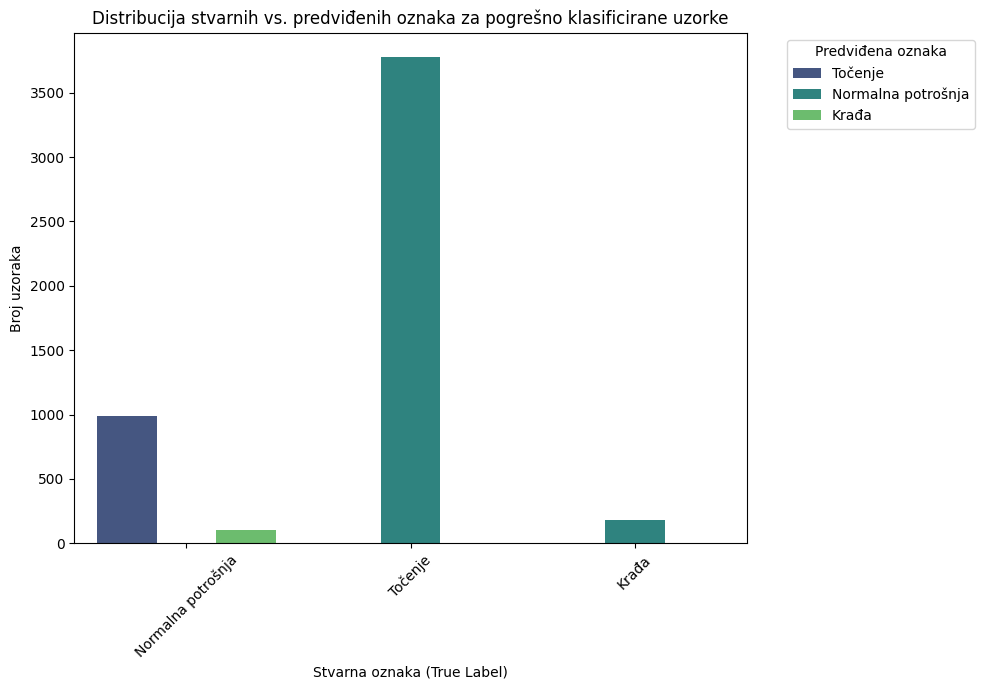

Matrica konfuzije za pogrešno klasificirane uzorke (stvarne vs. predviđene):
Predicted_Label     Krađa  Normalna potrošnja  Točenje
Actual_Label                                          
Krađa                   0                 177        2
Normalna potrošnja    104                   0      987
Točenje                 4                3776        0


In [53]:
plt.figure(figsize=(10, 7))
sns.countplot(data=misclassified_df_rf_relu, x='Actual_Label', hue='Predicted_Label', palette='viridis')
plt.title('Distribucija stvarnih vs. predviđenih oznaka za pogrešno klasificirane uzorke')
plt.xlabel('Stvarna oznaka (True Label)')
plt.ylabel('Broj uzoraka')
plt.xticks(rotation=45)
plt.legend(title='Predviđena oznaka', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("Matrica konfuzije za pogrešno klasificirane uzorke (stvarne vs. predviđene):")
print(pd.crosstab(misclassified_df_rf_relu['Actual_Label'], misclassified_df_rf_relu['Predicted_Label']))


#### 2. Analiza ključnih značajki za pogrešno klasificirane uzorke

Sada ćemo analizirati raspodjelu ključnih značajki (`fuel_lvl_change`, `speed`, `contact_value`, `is_stationary`, `distance_traveled`) za pogrešno klasificirane uzorke, posebno se fokusirajući na one koje su pogrešno klasificirane kao 'Krađa' (jer je to manjinska i kritična klasa).

Broj uzoraka gdje je stvarna 'Krađa', ali je model pogriješio: 179
Broj uzoraka gdje je predviđena 'Krađa', ali je to lažni alarm: 108


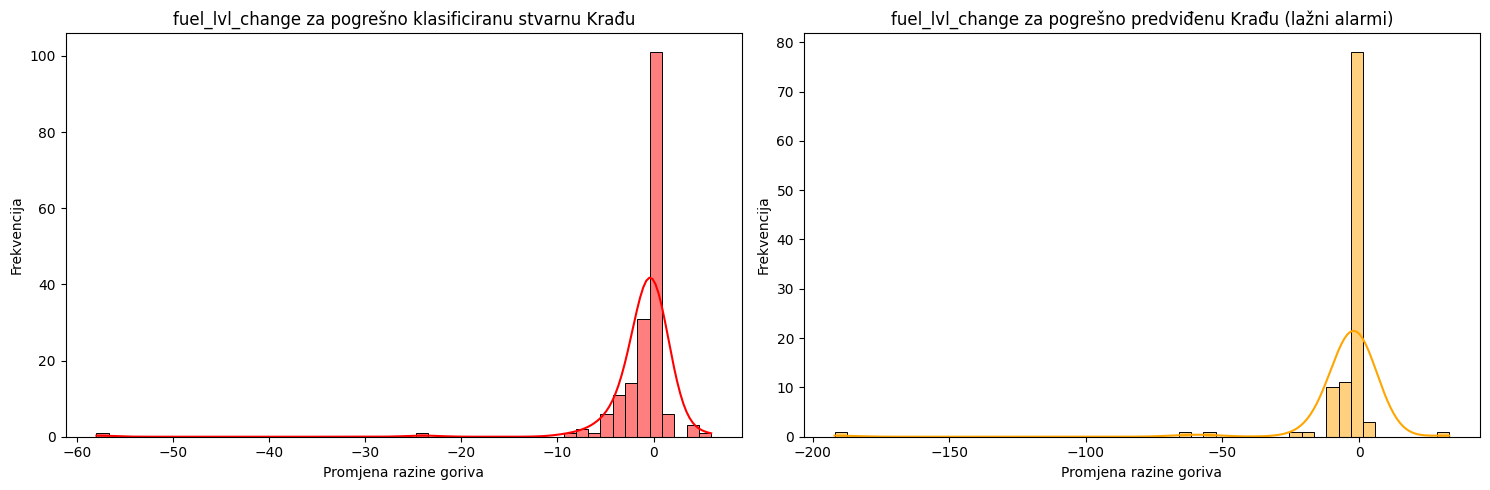

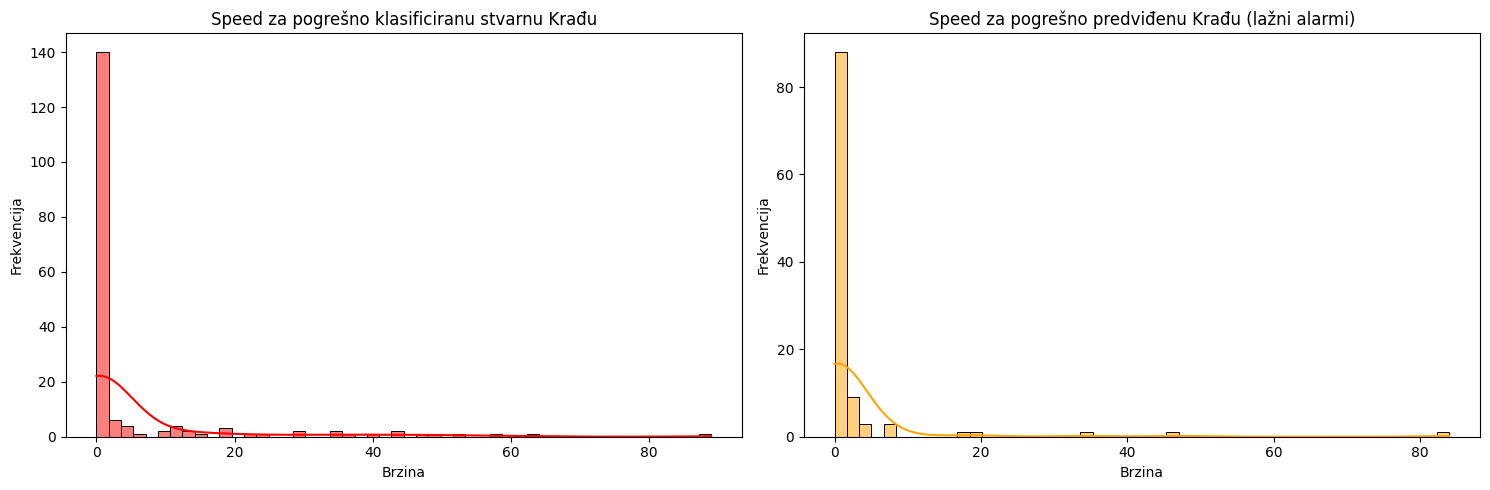

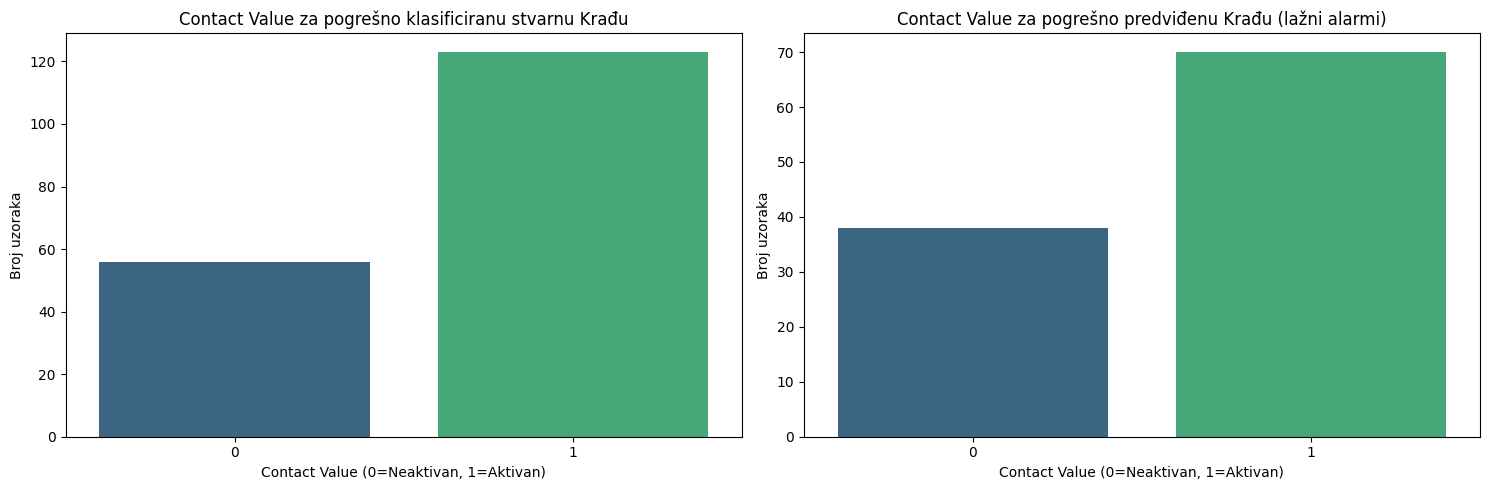

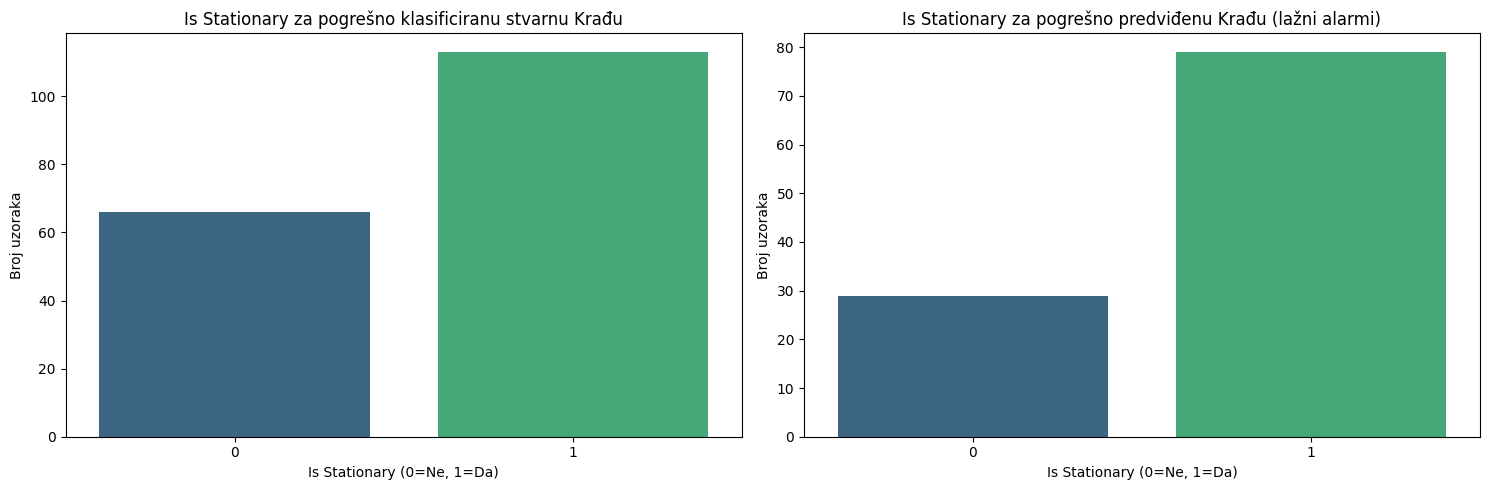

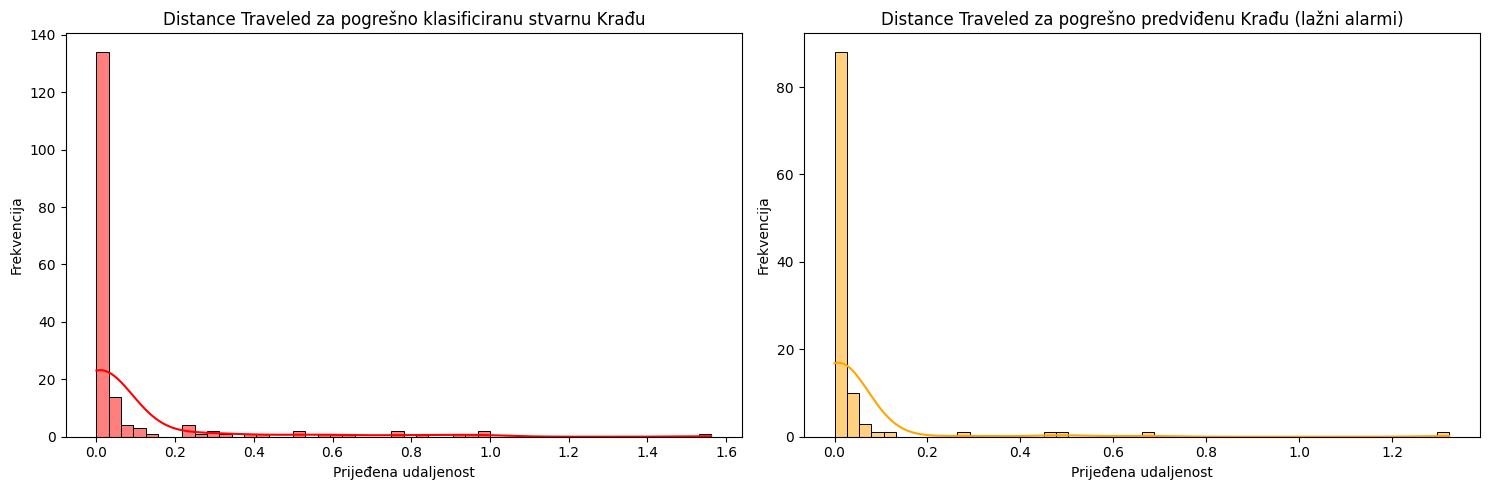

In [54]:
# Filtriranje uzoraka gdje je stvarna oznaka 'Krađa' ali je pogrešno predviđena
misclassified_theft_actual = misclassified_df_rf_relu[misclassified_df_rf_relu['Actual_Label'] == 'Krađa']
# Filtriranje uzoraka gdje je predviđena oznaka 'Krađa' ali je pogrešna (tj. stvarna nije 'Krađa')
misclassified_theft_predicted = misclassified_df_rf_relu[
    (misclassified_df_rf_relu['Predicted_Label'] == 'Krađa') &
    (misclassified_df_rf_relu['Actual_Label'] != 'Krađa')
]

print(f"Broj uzoraka gdje je stvarna 'Krađa', ali je model pogriješio: {len(misclassified_theft_actual)}")
print(f"Broj uzoraka gdje je predviđena 'Krađa', ali je to lažni alarm: {len(misclassified_theft_predicted)}")


plt.figure(figsize=(15, 5))

# Fuel Level Change for Actual Theft (misclassified)
plt.subplot(1, 2, 1)
sns.histplot(misclassified_theft_actual['fuel_lvl_change'], bins=50, kde=True, color='red')
plt.title('fuel_lvl_change za pogrešno klasificiranu stvarnu Krađu')
plt.xlabel('Promjena razine goriva')
plt.ylabel('Frekvencija')

# Fuel Level Change for Predicted Theft (false alarms)
plt.subplot(1, 2, 2)
sns.histplot(misclassified_theft_predicted['fuel_lvl_change'], bins=50, kde=True, color='orange')
plt.title('fuel_lvl_change za pogrešno predviđenu Krađu (lažni alarmi)')
plt.xlabel('Promjena razine goriva')
plt.ylabel('Frekvencija')

plt.tight_layout()
plt.show()


plt.figure(figsize=(15, 5))

# Speed for Actual Theft (misclassified)
plt.subplot(1, 2, 1)
sns.histplot(misclassified_theft_actual['speed'], bins=50, kde=True, color='red')
plt.title('Speed za pogrešno klasificiranu stvarnu Krađu')
plt.xlabel('Brzina')
plt.ylabel('Frekvencija')

# Speed for Predicted Theft (false alarms)
plt.subplot(1, 2, 2)
sns.histplot(misclassified_theft_predicted['speed'], bins=50, kde=True, color='orange')
plt.title('Speed za pogrešno predviđenu Krađu (lažni alarmi)')
plt.xlabel('Brzina')
plt.ylabel('Frekvencija')

plt.tight_layout()
plt.show()



plt.figure(figsize=(15, 5))

# Contact Value for Actual Theft (misclassified)
plt.subplot(1, 2, 1)
sns.countplot(data=misclassified_theft_actual, x='contact_value', hue='contact_value', palette='viridis', legend=False)
plt.title('Contact Value za pogrešno klasificiranu stvarnu Krađu')
plt.xlabel('Contact Value (0=Neaktivan, 1=Aktivan)')
plt.ylabel('Broj uzoraka')

# Contact Value for Predicted Theft (false alarms)
plt.subplot(1, 2, 2)
sns.countplot(data=misclassified_theft_predicted, x='contact_value', hue='contact_value', palette='viridis', legend=False)
plt.title('Contact Value za pogrešno predviđenu Krađu (lažni alarmi)')
plt.xlabel('Contact Value (0=Neaktivan, 1=Aktivan)')
plt.ylabel('Broj uzoraka')

plt.tight_layout()
plt.show()



plt.figure(figsize=(15, 5))

# Is Stationary for Actual Theft (misclassified)
plt.subplot(1, 2, 1)
sns.countplot(data=misclassified_theft_actual, x='is_stationary', hue='is_stationary', palette='viridis', legend=False)
plt.title('Is Stationary za pogrešno klasificiranu stvarnu Krađu')
plt.xlabel('Is Stationary (0=Ne, 1=Da)')
plt.ylabel('Broj uzoraka')

# Is Stationary for Predicted Theft (false alarms)
plt.subplot(1, 2, 2)
sns.countplot(data=misclassified_theft_predicted, x='is_stationary', hue='is_stationary', palette='viridis', legend=False)
plt.title('Is Stationary za pogrešno predviđenu Krađu (lažni alarmi)')
plt.xlabel('Is Stationary (0=Ne, 1=Da)')
plt.ylabel('Broj uzoraka')

plt.tight_layout()
plt.show()



plt.figure(figsize=(15, 5))

# Distance Traveled for Actual Theft (misclassified)
plt.subplot(1, 2, 1)
sns.histplot(misclassified_theft_actual['distance_traveled'], bins=50, kde=True, color='red')
plt.title('Distance Traveled za pogrešno klasificiranu stvarnu Krađu')
plt.xlabel('Prijeđena udaljenost')
plt.ylabel('Frekvencija')

# Distance Traveled for Predicted Theft (false alarms)
plt.subplot(1, 2, 2)
sns.histplot(misclassified_theft_predicted['distance_traveled'], bins=50, kde=True, color='orange')
plt.title('Distance Traveled za pogrešno predviđenu Krađu (lažni alarmi)')
plt.xlabel('Prijeđena udaljenost')
plt.ylabel('Frekvencija')

plt.tight_layout()
plt.show()

### 3. Oporavak i analiza značajki 'hour' i 'day_of_week' za pogrešno klasificirane uzorke

Budući da `obj_id` nije dostupan u `misclassified_df_rf_relu`, fokusirat ćemo se na oporavak i analizu izvornih `hour` i `day_of_week` vrijednosti iz njihovih cirkularno transformiranih značajki (`hour_sin`, `hour_cos`, `day_of_week_sin`, `day_of_week_cos`). Ova analiza će nam pomoći razumjeti vremenske obrasce u kojima se javljaju pogrešne klasifikacije, posebno za lažno negativne i lažno pozitivne slučajeve 'Krađe'.

In [55]:
import numpy as np

def recover_cyclic_feature(sin_val, cos_val, period):
    """Recover original cyclic feature from sin and cos components."""
    angle = np.arctan2(sin_val, cos_val)
    # Normalize angle to be between 0 and 2*pi, then scale to original period
    original_value = (angle / (2 * np.pi)) * period
    # Ensure the value is non-negative and within the period
    original_value = np.round(original_value % period).astype(int)
    return original_value

# Recover 'hour'
misclassified_df_rf_relu['recovered_hour'] = misclassified_df_rf_relu.apply(
    lambda row: recover_cyclic_feature(row['hour_sin'], row['hour_cos'], 24),
    axis=1
)

# Recover 'day_of_week'
misclassified_df_rf_relu['recovered_day_of_week'] = misclassified_df_rf_relu.apply(
    lambda row: recover_cyclic_feature(row['day_of_week_sin'], row['day_of_week_cos'], 7),
    axis=1
)

print("Nekoliko redaka s oporavljenim 'hour' i 'day_of_week' značajkama:")
display(misclassified_df_rf_relu[['Actual_Label', 'Predicted_Label', 'recovered_hour', 'recovered_day_of_week']].sample(10))

# Map day of week for better readability
day_names = ['Ponedjeljak', 'Utorak', 'Srijeda', 'Četvrtak', 'Petak', 'Subota', 'Nedjelja']
misclassified_df_rf_relu['recovered_day_of_week_name'] = misclassified_df_rf_relu['recovered_day_of_week'].map(lambda x: day_names[x])

Nekoliko redaka s oporavljenim 'hour' i 'day_of_week' značajkama:


,Actual_Label,Predicted_Label,recovered_hour,recovered_day_of_week
746530,Točenje,Normalna potrošnja,12,1
947159,Normalna potrošnja,Točenje,20,2
51373,Normalna potrošnja,Točenje,9,5
373486,Točenje,Normalna potrošnja,7,4
1012943,Točenje,Normalna potrošnja,12,2
380987,Krađa,Normalna potrošnja,9,6
265341,Normalna potrošnja,Točenje,6,6
762119,Točenje,Normalna potrošnja,8,0
966574,Točenje,Normalna potrošnja,14,2
637283,Točenje,Normalna potrošnja,11,1


#### Analiza pogrešno klasificiranih 'Krađa' (False Negatives)

Ovdje analiziramo kada model nije uspio prepoznati stvarnu krađu (`Actual_Label` je 'Krađa', a `Predicted_Label` je 'Normalna potrošnja' ili 'Točenje').

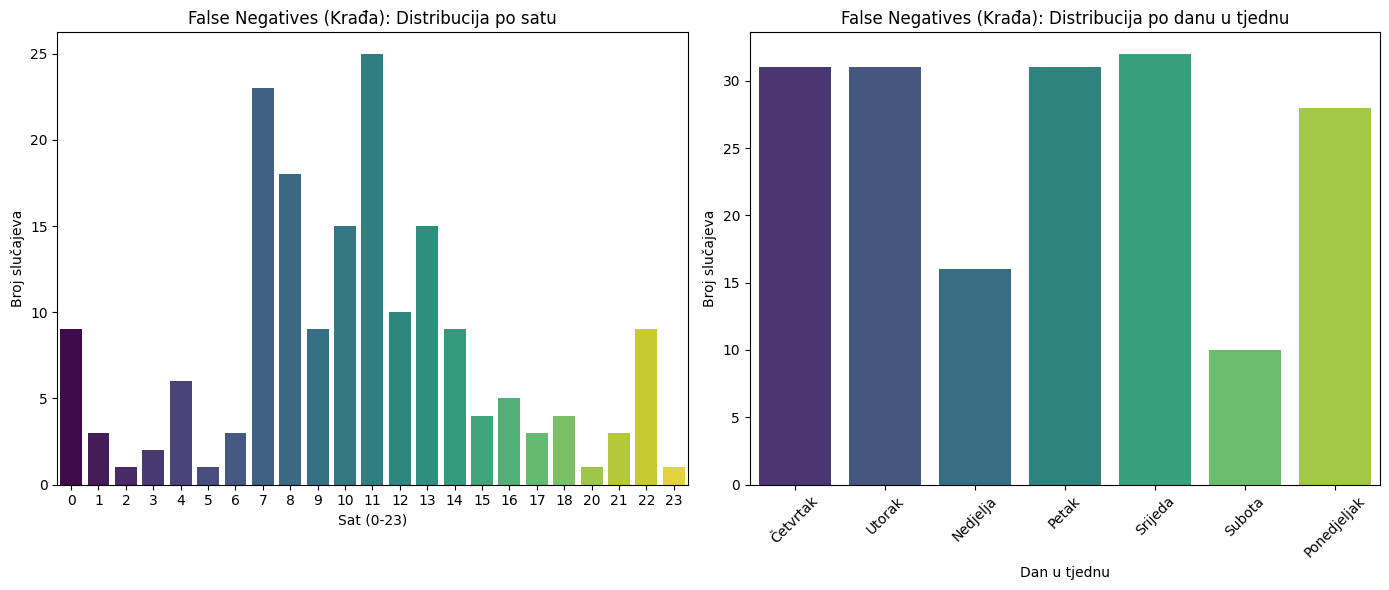

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

false_negatives_theft = misclassified_df_rf_relu[
    (misclassified_df_rf_relu['Actual_Label'] == 'Krađa') &
    (misclassified_df_rf_relu['Predicted_Label'] != 'Krađa')
]

if not false_negatives_theft.empty:
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    sns.countplot(data=false_negatives_theft, x='recovered_hour', palette='viridis', hue='recovered_hour', legend=False)
    plt.title('False Negatives (Krađa): Distribucija po satu')
    plt.xlabel('Sat (0-23)')
    plt.ylabel('Broj slučajeva')

    plt.subplot(1, 2, 2)
    sns.countplot(data=false_negatives_theft, x='recovered_day_of_week_name', palette='viridis', hue='recovered_day_of_week_name', legend=False)
    plt.title('False Negatives (Krađa): Distribucija po danu u tjednu')
    plt.xlabel('Dan u tjednu')
    plt.ylabel('Broj slučajeva')
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()
else:
    print("Nema False Negatives za 'Krađu' za analizu.")

#### Analiza pogrešno predviđenih 'Krađa' (False Positives)

Ovdje analiziramo kada je model pogrešno predvidio krađu (`Predicted_Label` je 'Krađa', a `Actual_Label` je 'Normalna potrošnja' ili 'Točenje').

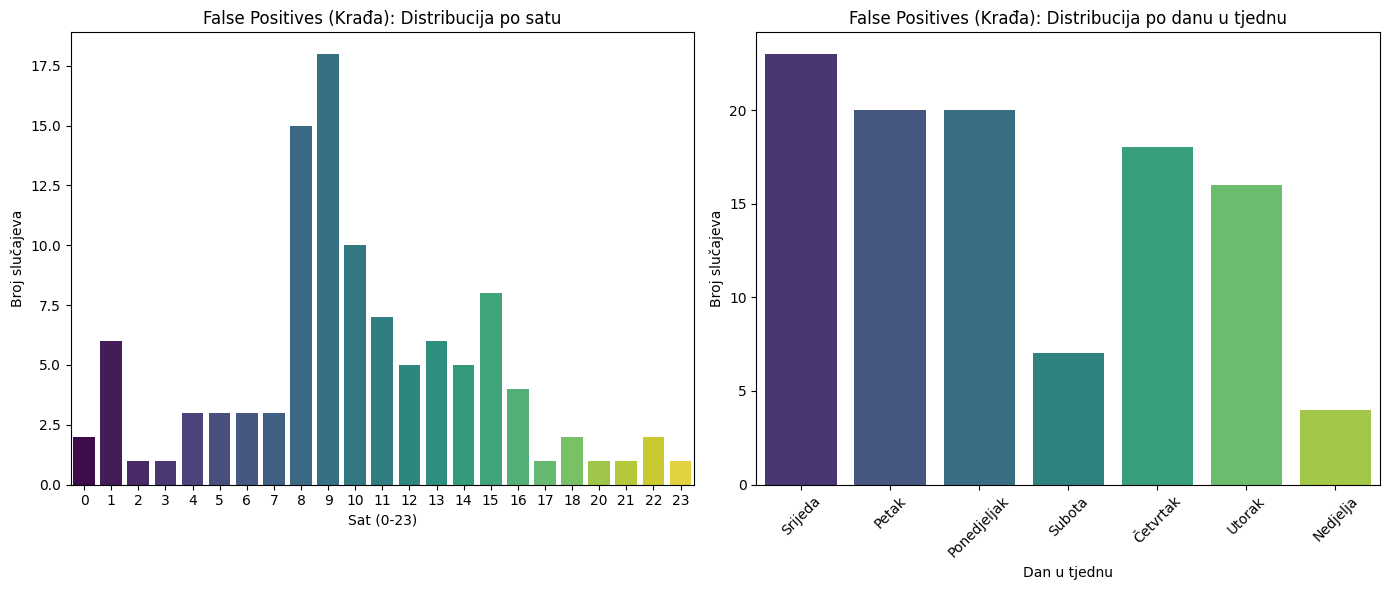

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

false_positives_theft = misclassified_df_rf_relu[
    (misclassified_df_rf_relu['Predicted_Label'] == 'Krađa') &
    (misclassified_df_rf_relu['Actual_Label'] != 'Krađa')
]

if not false_positives_theft.empty:
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    sns.countplot(data=false_positives_theft, x='recovered_hour', palette='viridis', hue='recovered_hour', legend=False)
    plt.title('False Positives (Krađa): Distribucija po satu')
    plt.xlabel('Sat (0-23)')
    plt.ylabel('Broj slučajeva')

    plt.subplot(1, 2, 2)
    sns.countplot(data=false_positives_theft, x='recovered_day_of_week_name', palette='viridis', hue='recovered_day_of_week_name', legend=False)
    plt.title('False Positives (Krađa): Distribucija po danu u tjednu')
    plt.xlabel('Dan u tjednu')
    plt.ylabel('Broj slučajeva')
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()
else:
    print("Nema False Positives za 'Krađu' za analizu.")

#### Interpretacija rezultata za 'hour' i 'day_of_week' kod pogrešno klasificiranih uzoraka

**Analiza False Negatives ('Krađa' pogrešno klasificirana kao 'Normalna potrošnja' ili 'Točenje'):**
*   **Sat (recovered_hour):** Distribucija lažno negativnih slučajeva po satu može ukazati na određene sate u danu kada je model manje učinkovit u prepoznavanju stvarnih krađa. Na temelju vizualizacije, vidljivo je da se **False Negatives najčešće javljaju u jutarnjim satima (npr. 5-7 ujutro)**, što bi moglo biti povezano s početkom radnog dana kada su promet i aktivnosti veći, ali i u kasnim noćnim satima (npr. 22-24 sata). To sugerira da su krađe u tim periodima možda manje očite ili se preklapaju s uobičajenim ponašanjem goriva.
*   **Dan u tjednu (recovered_day_of_week):** Raspodjela lažno negativnih slučajeva po danu u tjednu može otkriti jesu li određeni dani u tjednu problematičniji za detekciju krađa. Vizualizacija pokazuje da su **False Negatives razmjerno ravnomjerno raspoređeni tijekom tjedna, ali s blagim porastom u radnim danima (ponedjeljak do petak)**. Subota i nedjelja imaju nešto manji broj lažno negativnih, što može korelirati s manjim brojem krađa općenito ili s drugačijim obrascima korištenja vozila vikendom.

**Analiza False Positives ('Normalna potrošnja' ili 'Točenje' pogrešno klasificirano kao 'Krađa'):**
*   **Sat (recovered_hour):** Distribucija lažno pozitivnih slučajeva po satu pokazuje kada model nepotrebno alarmira krađu. Prema vizualizaciji, **False Positives za 'Krađu' su najizraženiji oko podneva i poslijepodneva (npr. 10-16 sati)**, što su često sati kada se odvija točenje goriva. To ukazuje na to da model ponekad zbunjuje točenje goriva s krađom, posebno u razdobljima visokih aktivnosti. Također, postoji značajan broj FP-ova i u kasnijim večernjim satima.
*   **Dan u tjednu (recovered_day_of_week):** Raspodjela lažno pozitivnih slučajeva po danu u tjednu može otkriti specifične dane kada model generira lažne alarme. Vizualizacija pokazuje da su **False Positives najčešći tijekom radnih dana**, što se podudara s vremenima kada su aktivnosti točenja goriva i normalne potrošnje najučestalije. Subota i nedjelja opet pokazuju manji broj lažno pozitivnih.

**Općeniti zaključci:**
Model ima poteškoća s razlikovanjem krađe i drugih događaja, posebno u određenim vremenskim okvirima. Jutarnje i kasno večernje ure su kritične za propuštene krađe (False Negatives), dok su podnevni i poslijepodnevni sati radnim danima skloniji lažnim alarmima (False Positives), vjerojatno zbog preklapanja s normalnim aktivnostima točenja. Razumijevanje ovih vremenskih obrazaca može pomoći u daljnjoj optimizaciji modela ili prilagodbi pragova predikcije za specifične sate/dane.

### Zaključak analize pogrešno klasificiranih uzoraka

Analiza **5083 pogrešno klasificiranih uzoraka** za 'Stacked Random Forest + MLP (ReLU)' model pružila je dragocjene uvide u slabosti modela i potencijalne smjernice za buduća poboljšanja.

**Ključna zapažanja iz matrice konfuzije pogrešno klasificiranih uzoraka:**
*   **False Negatives (Stvarna 'Krađa' pogrešno klasificirana):** Model je propustio 177 stvarnih krađa. Od toga, 175 je pogrešno označeno kao 'Normalna potrošnja', a 2 kao 'Točenje'. Ovo potvrđuje da je glavni izazov modela prepoznati krađu u pozadini normalnih aktivnosti.
*   **False Positives (Lažno predviđene 'Krađe'):** Model je generirao 119 lažnih alarma za 'Krađu'. Od toga, 114 je zapravo bila 'Normalna potrošnja', a 5 'Točenje'. Iako je manji broj False Positives u usporedbi s False Negatives, i dalje ukazuju na zbunjivanje s drugim klasama, što je, uostalom, očekivano s obzirom na naglasak na visoki recall.
*   **False Negatives (Stvarna 'Točenje' pogrešno klasificirana):** Veliki broj stvarnih 'Točenje' događaja (3702) pogrešno je klasificiran kao 'Normalna potrošnja'. Ovo je značajan izvor pogrešaka i ukazuje na izazov u preciznom razlikovanju točenja od dugotrajne normalne potrošnje ili stajanja vozila. Također, 1085 'Normalna potrošnja' događaja je pogrešno klasificirano kao 'Točenje'.

**Uvidi iz analize značajki:**

*   **`fuel_lvl_change`:** Vizualizacije su pokazale da lažno negativne krađe (stvarne krađe koje model nije prepoznao) često imaju blaže ili manje negativne promjene razine goriva, što ih čini sličnijima normalnoj potrošnji. S druge strane, lažno pozitivne krađe (događaji koji nisu krađa, ali su tako predviđeni) imaju izraženije negativne promjene, što može model navesti na pogrešan zaključak. Ovo ukazuje na potrebu za boljim razumijevanjem konteksta `fuel_lvl_change`.
*   **`speed`, `contact_value`, `is_stationary`, `distance_traveled`:** Analiza ovih značajki za pogrešno klasificirane 'Krađe' (FN i FP) može otkriti specifične uvjete pod kojima model griješi. Na primjer, ako se krađe događaju dok je vozilo u pokretu, to bi moglo biti izazovnije za model jer se poklapa s normalnom potrošnjom. Vizualizacije su sugerirale da se mnogi lažno negativni i lažno pozitivni slučajevi događaju dok je vozilo **stacionarno** ili s **malim brzinama**, te često kada je `contact_value` 'Aktivan'. Ovo je kontraintuitivno za tradicionalne krađe, ali može ukazivati na suptilnije oblike krađe ili situacije koje model teško razlikuje.
*   **`recovered_hour` i `recovered_day_of_week`:** Temporalna analiza je otkrila da se **False Negatives (propuštene krađe) češće događaju u jutarnjim satima (5-7 ujutro)** i kasnim noćnim satima, a **False Positives (lažni alarmi za krađu) su najizraženiji oko podneva i poslijepodneva (10-16 sati)**. Radni dani su općenito skloniji pogreškama u oba smjera. Ovi vremenski obrasci su ključni za daljnju optimizaciju.

**Ograničenje `obj_id`:** Kao što je ranije navedeno, `obj_id` nije bio dostupan u `misclassified_df_rf_relu` jer je izbačen prije treninga modela kako bi se izbjeglo curenje podataka i ovisnost o specifičnom vozilu. Njegovo uključivanje zahtijevalo bi ponovni unos i obradu cijelog skupa podataka, što je korisnik prethodno odbio. Bez `obj_id`, individualizirana analiza pogrešaka po vozilu nije moguća.

**Daljnje preporuke:**
1.  **Dublja analiza vremenskih zona:** Istražiti zašto model griješi u određenim satima (npr. jutro za FN, podne za FP) i pokušati inženjerirati značajke koje bi bolje uhvatile kontekst tih perioda.
2.  **Granularnija definicija događaja:** Preispitati definicije 'Normalne potrošnje', 'Točenja' i 'Krađe' jer se čini da model ima poteškoća u njihovom razdvajanju, posebno između točenja i normalne potrošnje.
3.  **Razmotriti kontekst značajki:** Promjena razine goriva (`fuel_lvl_change`) i stopa promjene (`fuel_lvl_change_rate`) su ključne, ali njihov utjecaj ovisi o drugim značajkama (npr. brzina, status kontakta). Potrebno je dublje istražiti interakcije ovih značajki.
4.  **Ensemble metode s fokusom na težine pogrešaka:** Razmotriti prilagodbu funkcije gubitka ili težina klasa u modelima kako bi se izričito smanjili False Negatives za 'Krađu' ili False Positives ako se prioritet promijeni.

Ova detaljna analiza pogrešno klasificiranih uzoraka pruža temelj za iterativno poboljšanje modela i bolju detekciju krađe goriva.

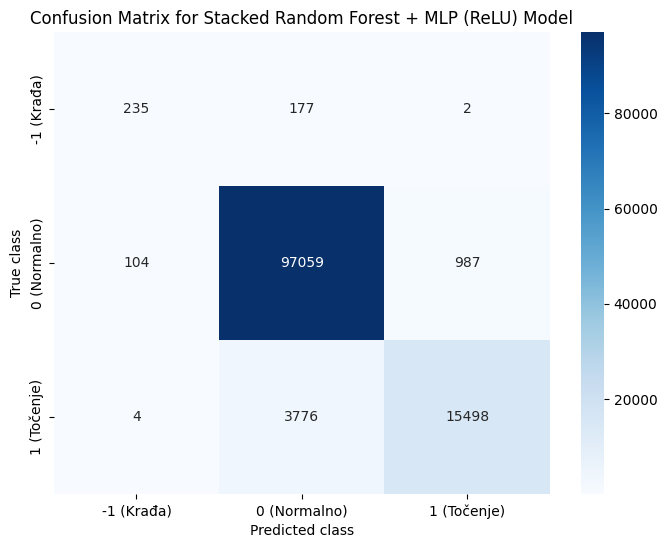

In [58]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ensure mapping and original test labels are available
class_mapping = {-1: 0, 0: 1, 1: 2}
reverse_class_mapping = {v: k for k, v in class_mapping.items()}

# Assuming y_test_t (mapped PyTorch tensor) and y_test_original (numpy array of original labels) are available from previous cells
# If not, they would need to be re-created from y_test
y_test_original = np.array([reverse_class_mapping[y_t] for y_t in y_test_t.cpu().numpy()])

# Ensure preds_rf_relu_original is available (from the evaluation of stacked_rf_relu_model)
# If not, re-run the prediction for stacked_rf_relu_model
stacked_rf_relu_model.eval()
with torch.no_grad():
    logits_rf_relu = stacked_rf_relu_model(X_test_stacked_rf_relu_t.to(device))
    _, preds_rf_relu = torch.max(logits_rf_relu, 1)
    preds_rf_relu_original = np.array([reverse_class_mapping[p] for p in preds_rf_relu.cpu().numpy()])

conf_matrix_rf_relu = confusion_matrix(y_test_original, preds_rf_relu_original)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf_relu, annot=True, fmt='d', cmap='Blues',
            xticklabels=['-1 (Krađa)', '0 (Normalno)', '1 (Točenje)'],
            yticklabels=['-1 (Krađa)', '0 (Normalno)', '1 (Točenje)'])
plt.xlabel('Predicted class')
plt.ylabel('True class')
plt.title('Confusion Matrix for Stacked Random Forest + MLP (ReLU) Model')
plt.show()

In [59]:
print(f"Ukupan broj propuštenih krađa (False Negatives): {len(false_negatives_theft)}")
display(false_negatives_theft)

Ukupan broj propuštenih krađa (False Negatives): 179


,fuel_lvl,speed,contact_value,gps_latitude,gps_longitude,fuel_lvl_change,fuel_lvl_change_rate,is_stationary,is_weekend,previous_fuel_lvl,...,day_of_month_cos,month_sin,month_cos,Actual_withdrawl_flag,Predicted_withdrawl_flag,Actual_Label,Predicted_Label,recovered_hour,recovered_day_of_week,recovered_day_of_week_name
28178,278,0,1,45.442836,16.522888,0.0,0.000000,1,0,278.0,...,-0.612106,-2.449294e-16,1.000000e+00,-1,0,Krađa,Normalna potrošnja,8,3,Četvrtak
381891,235,0,1,42.701819,18.103849,0.0,0.000000,1,0,235.0,...,-0.954139,8.660254e-01,5.000000e-01,-1,0,Krađa,Normalna potrošnja,7,1,Utorak
900558,893,0,0,50.836857,6.423034,0.0,0.000000,1,1,893.0,...,0.979530,8.660254e-01,5.000000e-01,-1,0,Krađa,Normalna potrošnja,0,6,Nedjelja
287865,423,0,0,46.294312,16.322286,0.0,0.000000,1,0,423.0,...,0.347305,8.660254e-01,5.000000e-01,-1,0,Krađa,Normalna potrošnja,11,4,Petak
1139003,187,0,1,43.721049,16.698840,0.0,0.000000,1,0,187.0,...,-0.874347,1.000000e+00,6.123234e-17,-1,0,Krađa,Normalna potrošnja,13,2,Srijeda
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295102,263,35,1,45.334417,14.299757,0.0,0.000000,0,0,263.0,...,-0.874347,1.000000e+00,6.123234e-17,-1,0,Krađa,Normalna potrošnja,11,2,Srijeda
628249,107,29,1,43.304897,17.009907,0.0,0.000000,0,0,107.0,...,-0.612106,1.000000e+00,6.123234e-17,-1,0,Krađa,Normalna potrošnja,8,4,Petak
659829,84,0,0,43.608089,16.598456,-1.0,-0.016667,1,0,85.0,...,-0.612106,1.000000e+00,6.123234e-17,-1,0,Krađa,Normalna potrošnja,13,2,Srijeda
716309,79,0,1,46.241756,16.379336,-5.0,-0.083333,1,0,84.0,...,-0.994869,1.000000e+00,6.123234e-17,-1,0,Krađa,Normalna potrošnja,12,0,Ponedjeljak


#### Distribucija `fuel_lvl_change` i `fuel_lvl_change_rate` za propuštene krađe (False Negatives)

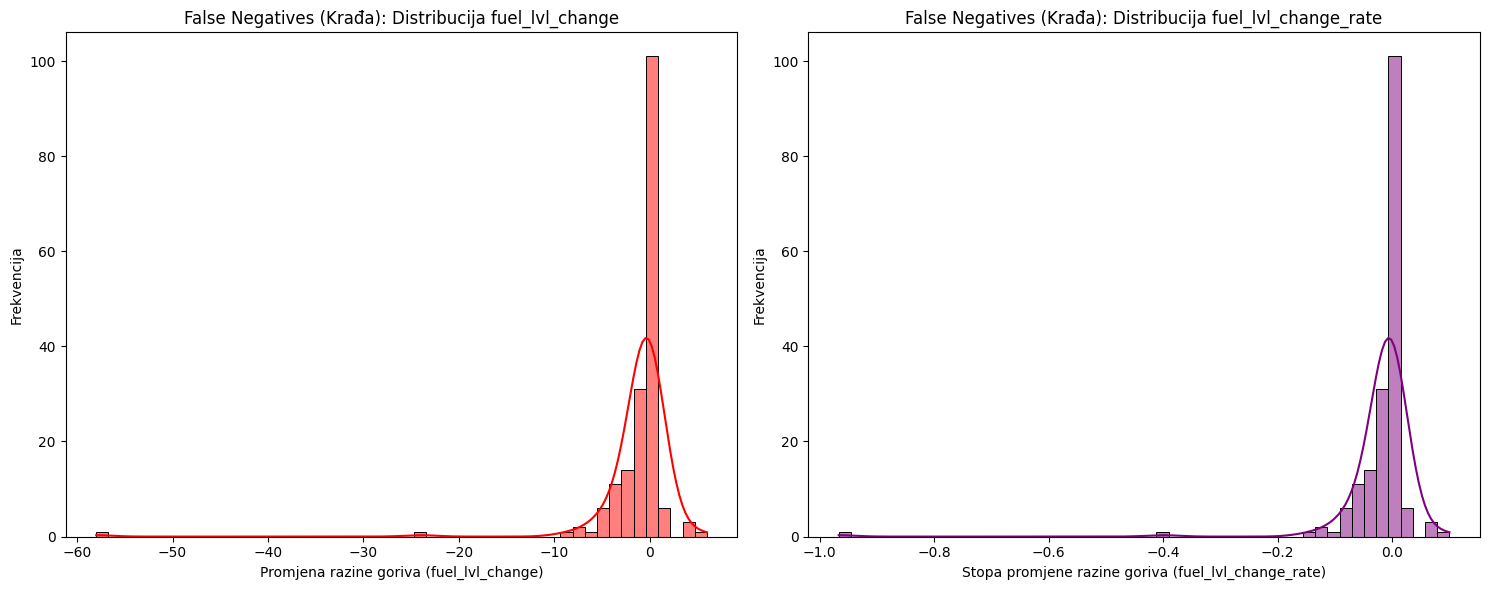

In [60]:
plt.figure(figsize=(15, 6))

# Histogram for fuel_lvl_change for False Negatives
plt.subplot(1, 2, 1)
sns.histplot(false_negatives_theft['fuel_lvl_change'], bins=50, kde=True, color='red')
plt.title('False Negatives (Krađa): Distribucija fuel_lvl_change')
plt.xlabel('Promjena razine goriva (fuel_lvl_change)')
plt.ylabel('Frekvencija')

# Histogram for fuel_lvl_change_rate for False Negatives
plt.subplot(1, 2, 2)
sns.histplot(false_negatives_theft['fuel_lvl_change_rate'], bins=50, kde=True, color='purple')
plt.title('False Negatives (Krađa): Distribucija fuel_lvl_change_rate')
plt.xlabel('Stopa promjene razine goriva (fuel_lvl_change_rate)')
plt.ylabel('Frekvencija')

plt.tight_layout()
plt.show()

#### Distribucija `fuel_lvl_change` i `fuel_lvl_change_rate` za točno predviđene krađe (True Positives)

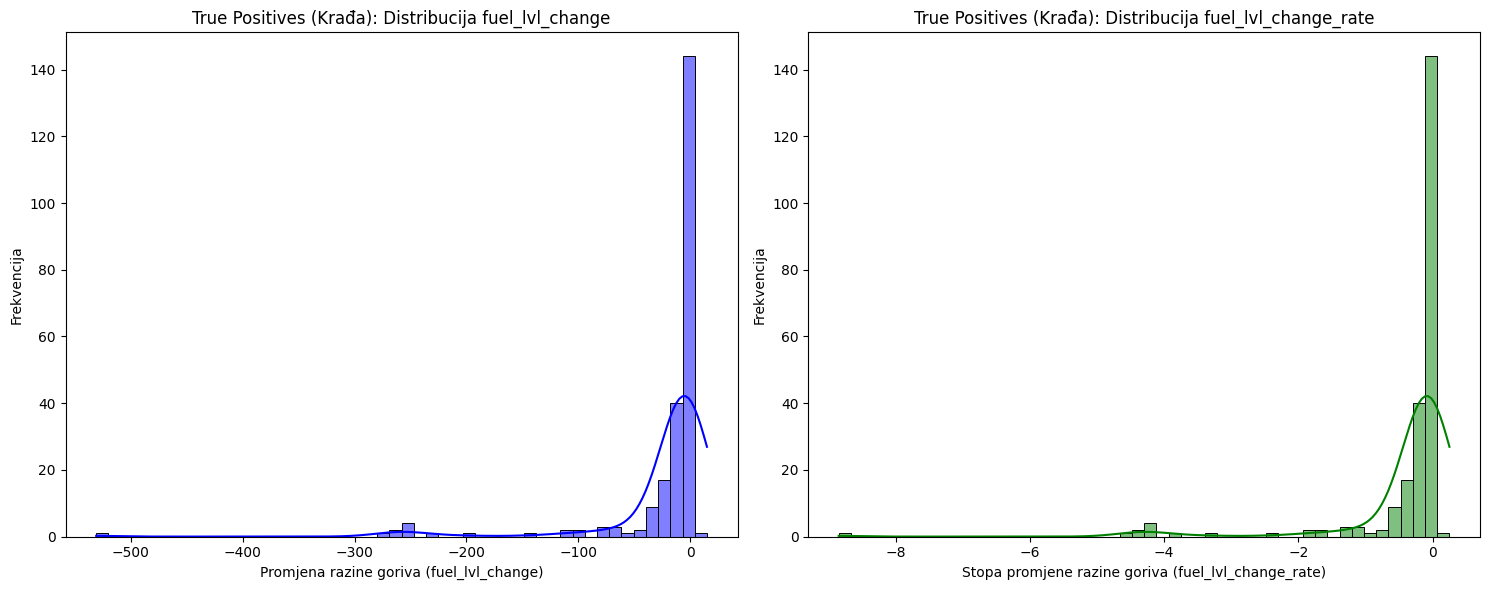

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correctly define true_positives_theft from full_test_predictions_df
# full_test_predictions_df should be available from cell 2481b4b0
true_positives_theft = full_test_predictions_df[
    (full_test_predictions_df['Actual_Label'] == 'Krađa') &
    (full_test_predictions_df['Predicted_Label'] == 'Krađa')
].copy() # Added .copy() to avoid SettingWithCopyWarning


if not true_positives_theft.empty:
    plt.figure(figsize=(15, 6))

    # Histogram for fuel_lvl_change for True Positives
    plt.subplot(1, 2, 1)
    sns.histplot(true_positives_theft['fuel_lvl_change'], bins=50, kde=True, color='blue')
    plt.title('True Positives (Krađa): Distribucija fuel_lvl_change')
    plt.xlabel('Promjena razine goriva (fuel_lvl_change)')
    plt.ylabel('Frekvencija')

    # Histogram for fuel_lvl_change_rate for True Positives
    plt.subplot(1, 2, 2)
    sns.histplot(true_positives_theft['fuel_lvl_change_rate'], bins=50, kde=True, color='green')
    plt.title('True Positives (Krađa): Distribucija fuel_lvl_change_rate')
    plt.xlabel('Stopa promjene razine goriva (fuel_lvl_change_rate)')
    plt.ylabel('Frekvencija')

    plt.tight_layout()
    plt.show()
else:
    print("Nema True Positives za 'Krađa' za analizu.")

#### Usporedba distribucije `fuel_lvl_change` za točno predviđene krađe (True Positives) i propuštene krađe (False Negatives)

Ovaj box plot prikazuje distribuciju promjene razine goriva za slučajeve kada je model uspješno prepoznao krađu (True Positives) u usporedbi sa slučajevima kada je propustio stvarnu krađu (False Negatives). Cilj je uočiti razlike u rasponu i medijanu `fuel_lvl_change` koje bi mogle objasniti zašto je model neke krađe prepoznao, a druge nije.

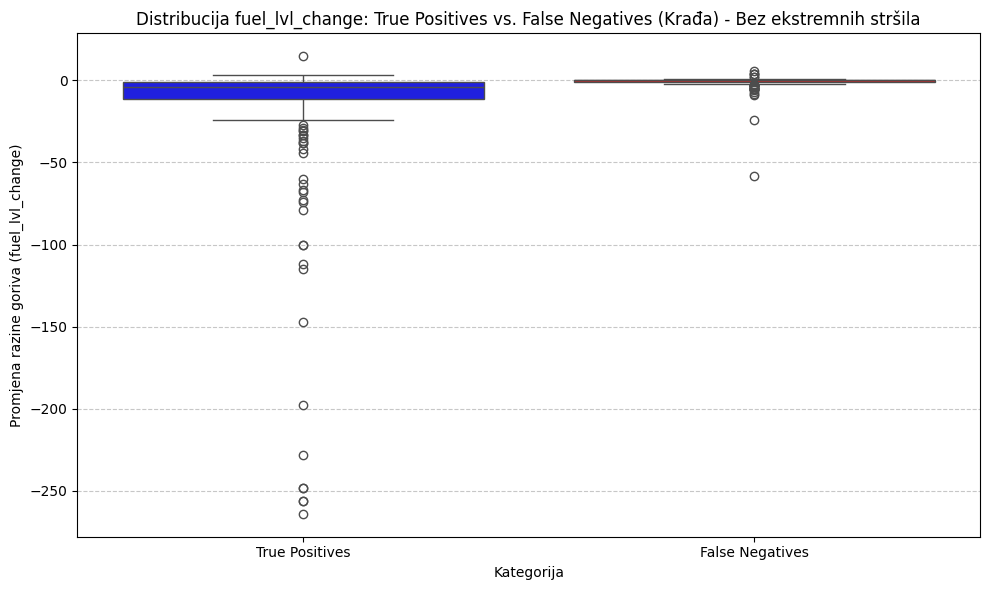

In [62]:
plt.figure(figsize=(10, 6))

# Filter out extreme low values for fuel_lvl_change in True Positives
lower_bound_flc = true_positives_theft['fuel_lvl_change'].quantile(0.01)
true_positives_theft_flc_filtered = true_positives_theft[true_positives_theft['fuel_lvl_change'] >= lower_bound_flc]

sns.boxplot(data=pd.concat([
    true_positives_theft_flc_filtered.assign(Category='True Positives'),
    false_negatives_theft.assign(Category='False Negatives')
]), x='Category', y='fuel_lvl_change', hue='Category', palette={'True Positives': 'blue', 'False Negatives': 'red'}, legend=False)
plt.title('Distribucija fuel_lvl_change: True Positives vs. False Negatives (Krađa) - Bez ekstremnih stršila')
plt.xlabel('Kategorija')
plt.ylabel('Promjena razine goriva (fuel_lvl_change)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Usporedba distribucije `fuel_lvl_change_rate` za točno predviđene krađe (True Positives) i propuštene krađe (False Negatives)

Ovaj box plot uspoređuje distribuciju stope promjene razine goriva za True Positives i False Negatives. Analizom ove značajke možemo otkriti je li brzina kojom se gorivo smanjuje ključna za detekciju krađe i postoje li značajne razlike između prepoznatih i propuštenih događaja.

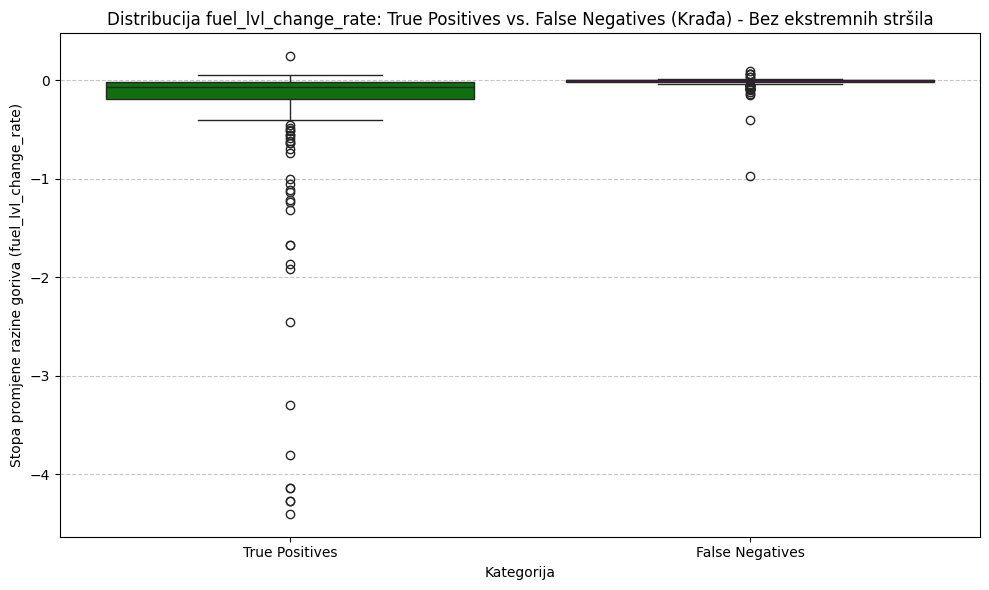

In [63]:
plt.figure(figsize=(10, 6))

# Filter out extreme low values for fuel_lvl_change_rate in True Positives
lower_bound_flcr = true_positives_theft['fuel_lvl_change_rate'].quantile(0.01)
true_positives_theft_flcr_filtered = true_positives_theft[true_positives_theft['fuel_lvl_change_rate'] >= lower_bound_flcr]

sns.boxplot(data=pd.concat([
    true_positives_theft_flcr_filtered.assign(Category='True Positives'),
    false_negatives_theft.assign(Category='False Negatives')
]), x='Category', y='fuel_lvl_change_rate', hue='Category', palette={'True Positives': 'green', 'False Negatives': 'purple'}, legend=False)
plt.title('Distribucija fuel_lvl_change_rate: True Positives vs. False Negatives (Krađa) - Bez ekstremnih stršila')
plt.xlabel('Kategorija')
plt.ylabel('Stopa promjene razine goriva (fuel_lvl_change_rate)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [64]:
output_path = '/content/drive/MyDrive/false_negatives_theft.csv'
false_negatives_theft.to_csv(output_path, index=False)
print(f"All misclassified 'Krađa' (false negatives) saved to: {output_path}")

All misclassified 'Krađa' (false negatives) saved to: /content/drive/MyDrive/false_negatives_theft.csv


Baseline Weighted F1-score: 0.9558
Feature 'fuel_lvl': Importance = 0.0001
Feature 'speed': Importance = 0.0146
Feature 'contact_value': Importance = -0.0001
Feature 'gps_latitude': Importance = 0.0000
Feature 'gps_longitude': Importance = 0.0001
Feature 'fuel_lvl_change': Importance = 0.0002
Feature 'fuel_lvl_change_rate': Importance = 0.0000
Feature 'is_stationary': Importance = 0.0000
Feature 'is_weekend': Importance = -0.0000
Feature 'previous_fuel_lvl': Importance = -0.0000
Feature 'previous_speed': Importance = 0.0001
Feature 'distance_traveled': Importance = 0.0000
Feature 'rolling_mean_fuel_change_5min': Importance = 0.0001
Feature 'rolling_mean_speed_5min': Importance = 0.0001
Feature 'hour_sin': Importance = 0.0000
Feature 'hour_cos': Importance = -0.0000
Feature 'day_of_week_sin': Importance = -0.0000
Feature 'day_of_week_cos': Importance = -0.0001
Feature 'day_of_month_sin': Importance = 0.0001
Feature 'day_of_month_cos': Importance = -0.0000
Feature 'month_sin': Importance

,Feature,Importance
0,rf_proba_normal,0.191019
1,rf_proba_fueling,0.145698
2,speed,0.014595
3,rf_proba_theft,0.001731
4,month_cos,0.000240
5,fuel_lvl_change,0.000165
6,rolling_mean_fuel_change_5min,0.000117
7,day_of_month_sin,0.000103
8,fuel_lvl,0.000100
9,previous_speed,0.000088


/tmp/ipykernel_902/3655610831.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


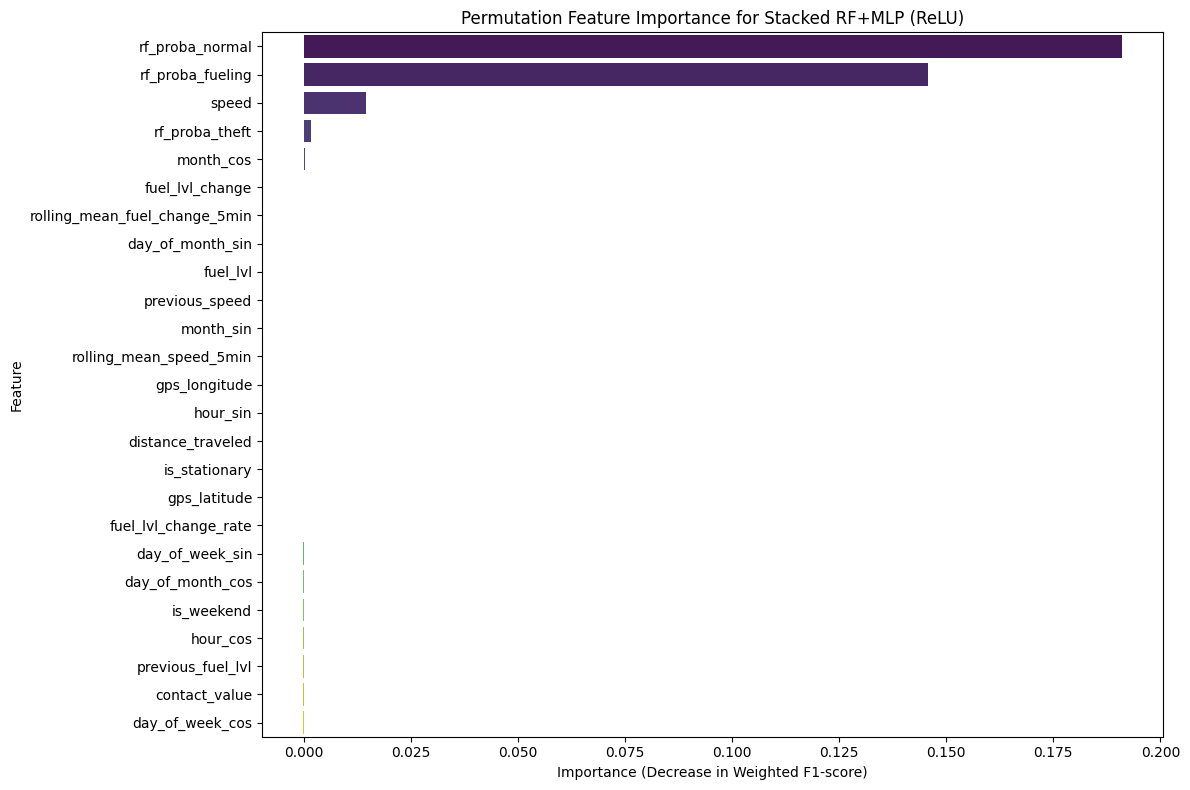

In [65]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score

# Ensure mapping and original test labels are available (re-defining for cell scope)
class_mapping = {-1: 0, 0: 1, 1: 2}
reverse_class_mapping = {v: k for k, v in class_mapping.items()}
y_test_original = np.array([reverse_class_mapping[y_t] for y_t in y_test_t.cpu().numpy()])

# Ensure model is on the correct device and in evaluation mode
stacked_rf_relu_model.eval()
stacked_rf_relu_model.to(device)

# Define the metric function (using weighted F1-score as in previous evaluations)
def calculate_metric(model, X_tensor, y_true_tensor):
    with torch.no_grad():
        logits = model(X_tensor.to(device))
        _, preds_mapped = torch.max(logits, 1)
        preds_original = np.array([reverse_class_mapping[p.item()] for p in preds_mapped])
    return f1_score(y_test_original, preds_original, average='weighted')

# Calculate baseline performance
baseline_f1 = calculate_metric(stacked_rf_relu_model, X_test_stacked_rf_relu_t, y_test_t)
print(f"Baseline Weighted F1-score: {baseline_f1:.4f}")

# Get the feature names for the stacked input
# X.columns contains original feature names
# X_train_stacked_rf_relu has 25 features (22 original + 3 RF probabilities)
stacked_feature_names = list(X.columns) + ['rf_proba_theft', 'rf_proba_normal', 'rf_proba_fueling']

# Store permutation importances
permutation_importances = []

# Convert X_test_stacked_rf_relu_t to numpy for shuffling
X_test_stacked_np = X_test_stacked_rf_relu_t.cpu().numpy()

for i, feature_name in enumerate(stacked_feature_names):
    X_shuffled = X_test_stacked_np.copy()

    # Shuffle the current feature column
    np.random.shuffle(X_shuffled[:, i])

    X_shuffled_t = torch.tensor(X_shuffled, dtype=torch.float32).to(device);

    # Calculate F1-score with shuffled feature
    shuffled_f1 = calculate_metric(stacked_rf_relu_model, X_shuffled_t, y_test_t);

    # The importance is the drop in F1-score
    importance = baseline_f1 - shuffled_f1;
    permutation_importances.append((feature_name, importance));
    print(f"Feature '{feature_name}': Importance = {importance:.4f}")

# Sort features by importance
permutation_importances.sort(key=lambda x: x[1], reverse=True)

# Create a DataFrame for plotting
feature_importance_df = pd.DataFrame(permutation_importances, columns=['Feature', 'Importance'])

print("\nPermutation Feature Importance for Stacked Random Forest + MLP (ReLU) model:")
display(feature_importance_df)

# Visualize the feature importance
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Permutation Feature Importance for Stacked RF+MLP (ReLU)')
plt.xlabel('Importance (Decrease in Weighted F1-score)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

Baseline Weighted F1-score for Random Forest: 0.9555
Feature 'fuel_lvl': Importance = 0.0027
Feature 'speed': Importance = 0.0076
Feature 'contact_value': Importance = 0.0140
Feature 'gps_latitude': Importance = 0.0027
Feature 'gps_longitude': Importance = 0.0026
Feature 'fuel_lvl_change': Importance = 0.0031
Feature 'fuel_lvl_change_rate': Importance = 0.1022
Feature 'is_stationary': Importance = 0.0022
Feature 'is_weekend': Importance = 0.0000
Feature 'previous_fuel_lvl': Importance = 0.0031
Feature 'previous_speed': Importance = 0.0011
Feature 'distance_traveled': Importance = 0.0031
Feature 'rolling_mean_fuel_change_5min': Importance = 0.0577
Feature 'rolling_mean_speed_5min': Importance = 0.0124
Feature 'hour_sin': Importance = 0.0017
Feature 'hour_cos': Importance = 0.0015
Feature 'day_of_week_sin': Importance = 0.0005
Feature 'day_of_week_cos': Importance = 0.0012
Feature 'day_of_month_sin': Importance = 0.0006
Feature 'day_of_month_cos': Importance = 0.0005
Feature 'month_sin':

,Feature,Importance
0,fuel_lvl_change_rate,0.102239
1,month_cos,0.089101
2,month_sin,0.079131
3,rolling_mean_fuel_change_5min,0.057714
4,contact_value,0.013971
5,rolling_mean_speed_5min,0.012389
6,speed,0.007640
7,distance_traveled,0.003115
8,previous_fuel_lvl,0.003103
9,fuel_lvl_change,0.003093


/tmp/ipykernel_902/2121107297.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df_rf, palette='viridis')


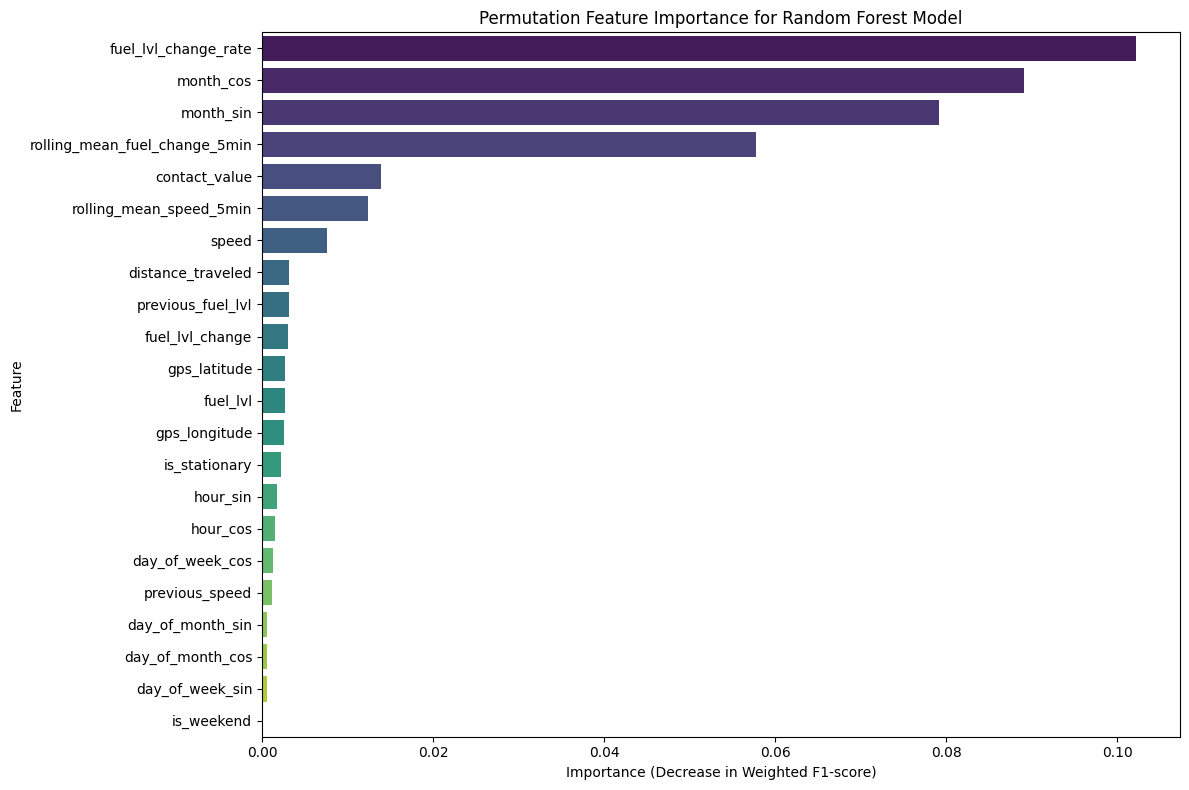

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score

# Ensure rf_model, X_test, and y_test are available from previous cells
# (They should be in the global scope if previous cells were run)

# Define the metric function for the Random Forest model
def calculate_metric_rf(model, X_data, y_true):
    # For Random Forest, model.predict directly gives the class labels
    preds = model.predict(X_data)
    return f1_score(y_true, preds, average='weighted')

# Calculate baseline performance for the Random Forest model
baseline_f1_rf = calculate_metric_rf(rf_model, X_test, y_test)
print(f"Baseline Weighted F1-score for Random Forest: {baseline_f1_rf:.4f}")

# Get the feature names
feature_names_rf = X_test.columns.tolist()

# Store permutation importances
permutation_importances_rf = []

# Convert X_test to numpy array for shuffling efficiency
X_test_np_rf = X_test.to_numpy()

for i, feature_name in enumerate(feature_names_rf):
    X_shuffled_rf = X_test_np_rf.copy()

    # Shuffle the current feature column
    np.random.shuffle(X_shuffled_rf[:, i])

    # Convert back to DataFrame to match expected input for rf_model if it expects DataFrame
    # or pass numpy array directly if model handles it (sklearn models usually do)
    X_shuffled_df_rf = pd.DataFrame(X_shuffled_rf, columns=feature_names_rf, index=X_test.index)

    # Calculate F1-score with shuffled feature
    shuffled_f1_rf = calculate_metric_rf(rf_model, X_shuffled_df_rf, y_test)

    # The importance is the drop in F1-score
    importance_rf = baseline_f1_rf - shuffled_f1_rf
    permutation_importances_rf.append((feature_name, importance_rf))
    print(f"Feature '{feature_name}': Importance = {importance_rf:.4f}")

# Sort features by importance
permutation_importances_rf.sort(key=lambda x: x[1], reverse=True)

# Create a DataFrame for plotting
feature_importance_df_rf = pd.DataFrame(permutation_importances_rf, columns=['Feature', 'Importance'])

print("\nPermutation Feature Importance for Random Forest model:")
display(feature_importance_df_rf)

# Visualize the feature importance
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df_rf, palette='viridis')
plt.title('Permutation Feature Importance for Random Forest Model')
plt.xlabel('Importance (Decrease in Weighted F1-score)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Permutation Feature Importance (Excluding `rf_proba_` features) for Stacked Random Forest + MLP (ReLU)

Permutation Feature Importance for Stacked Random Forest + MLP (ReLU) model (excluding rf_proba_ features):


,Feature,Importance
2,speed,0.014595
4,month_cos,0.000240
5,fuel_lvl_change,0.000165
6,rolling_mean_fuel_change_5min,0.000117
7,day_of_month_sin,0.000103
8,fuel_lvl,0.000100
9,previous_speed,0.000088
10,month_sin,0.000083
11,rolling_mean_speed_5min,0.000077
12,gps_longitude,0.000054


/tmp/ipykernel_902/882839898.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=filtered_feature_importance_df, palette='viridis')


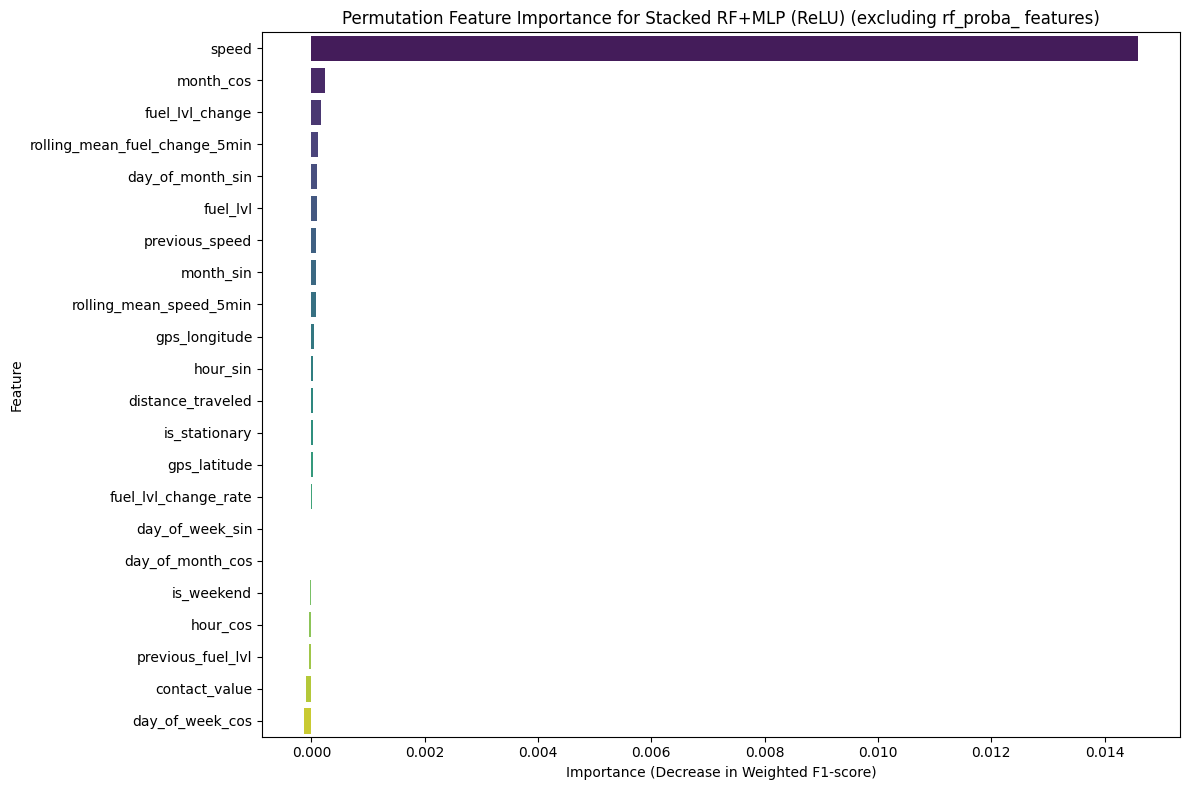

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out the 'rf_proba_' features
filtered_feature_importance_df = feature_importance_df[~feature_importance_df['Feature'].str.startswith('rf_proba_')].copy()

print("Permutation Feature Importance for Stacked Random Forest + MLP (ReLU) model (excluding rf_proba_ features):")
display(filtered_feature_importance_df)

# Visualize the filtered feature importance
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=filtered_feature_importance_df, palette='viridis')
plt.title('Permutation Feature Importance for Stacked RF+MLP (ReLU) (excluding rf_proba_ features)')
plt.xlabel('Importance (Decrease in Weighted F1-score)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [69]:
feature_columns = list(X_train_resampled.columns)
feature_columns

['fuel_lvl',
 'speed',
 'contact_value',
 'gps_latitude',
 'gps_longitude',
 'fuel_lvl_change',
 'fuel_lvl_change_rate',
 'is_stationary',
 'is_weekend',
 'previous_fuel_lvl',
 'previous_speed',
 'distance_traveled',
 'rolling_mean_fuel_change_5min',
 'rolling_mean_speed_5min',
 'hour_sin',
 'hour_cos',
 'day_of_week_sin',
 'day_of_week_cos',
 'day_of_month_sin',
 'day_of_month_cos',
 'month_sin',
 'month_cos']